## Group6
### Ing-Ruei Huang, JiaYi Wang

In [2]:
import os

cache_path = r"D:\Jupyter\pytensor_cache"

# Automatically create the folder if it does not exist.
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
    
os.environ['PYTENSOR_FLAGS'] = f"base_compiledir={cache_path}"

print(f"Compilation environment fixed! Cache directory set to: {cache_path}")

Compilation environment fixed! Cache directory set to: D:\Jupyter\pytensor_cache


***Step 0 My Goal:***


We are going to build a hierarchical Bayesian model: For driver d in race r, we model their finishing position as a linear combination of a number of latent (hidden) effects. To do this, we first assume a pdf for the data:

$y_{d,r} \sim \mathrm{Normal}(\mu_{d,r}, \sigma_{\text{race}}^{2})$


## Hierarchical Bayesian Model Structure

### Core latent effects 
α = baseline finishing position  
#α = Baseline finishing position (overall average performance level)


β_car[d] = car/team effect  
#β_car[d] = Car/team performance effect (for team d, capturing the intrinsic speed/strength of the car)

γ_d = driver-specific skill  
#γ_d = Driver skill effect (capturing differences in individual driver ability)

ε_r = race-specific random effect  
#ε_r = Race-specific random effect (unpredictable race-to-race variability such as incidents, layout changes, etc.)

σ_race = within-race variability (HalfNormal, must be positive)  
#σ_race = Standard deviation of within-race variability (modeled with HalfNormal because standard deviations must be positive)

---

### Feature effects（λ parameters）

λ1 = Q_{d,r} = Qualifying performance  
#λ1 = Qualifying performance (e.g., qualifying position or gap to pole)

λ2 = DriverPoints_{d,r}  
#λ2 = Driver’s season points (representing overall season strength)

λ3 = TeamAvgPace_{team,r}  
#λ3 = Team’s average race pace (can be computed via FastF1 race pace metrics)

λ4 = WeatherFactor_{r}  
#λ4 = Weather factor (an aggregated indicator combining temperature, wind speed, humidity, etc.)

λ5 = CarReliability_{team}  
#λ5 = Car reliability (recent DNF rate or probability of technical failures)

λ6 = DriverSeasonForm_{d,r} 
#λ6 = Driver’s season form (e.g., average finish or points trend over the last X races)


### Overall Model 

For driver *d* in race *r*:  

Observed finishing position:  

$$y_{d,r} \sim \text{Normal}(\mu_{d,r}, \, \sigma_{\text{race}}^2)$$

Expected performance:  

μ_{d,r} = α + β_car[d]  + γ_d  + ε_r  
            
            + λ1 * Q_{d,r}  
            
            + λ2 * DriverPoints_{d,r}  
            
            + λ3 * TeamAvgPace_{team,r}  
            
            + λ4 * WeatherFactor_r  
            
            + λ5 * CarReliability_{team}  
            
            + λ6 * DriverSeasonForm_{d,r}  



We need to include all teams and drivers from 2025 in the priors, but due to the sheer volume of data, we can't manually write each one. We need a vectorized prior that automatically generates priors for all drivers and teams.

So let's move on to step1 data preparation and come back to get prior

***Step 1 Data Preparation***

Use $FastF1$ to automatically capture the core structure of each game (Race + Quali + FP + PitStop + Pace).

The weather $ λ4 * WeatherFactor_r  $ We will simply divide them into rainy days and non-rainy days.

# F1 2025 Race Data Extraction Script - Code Walkthrough

## Section 1: Imports and Dependencies
```python
import fastf1
import pandas as pd
import numpy as np
from datetime import datetime
import os
```

**What it does:**
- Imports the FastF1 library for accessing F1 telemetry and race data
- Imports pandas for data manipulation and DataFrame operations
- Imports numpy for numerical computations and handling NaN values
- Imports datetime for time-related operations
- Imports os for file system operations (creating cache directory)

---

## Section 2: Cache Setup
```python
if not os.path.exists('f1_cache'):
    os.makedirs('f1_cache')
fastf1.Cache.enable_cache('f1_cache')
```

**What it does:**
- Checks if a cache directory exists, creates it if not
- Enables FastF1's caching mechanism to store downloaded data locally
- **Why**: Without caching, the script would re-download all telemetry data on every run, making it extremely slow
- Cached data persists between runs, dramatically improving performance

---

## Section 3: Helper Function - `get_team_pace()`
```python
def get_team_pace(race_session, team_name):
    try:
        laps = race_session.laps.pick_team(team_name).pick_quicklaps()
        if len(laps) == 0:
            return np.nan
        return laps['LapTime'].dt.total_seconds().mean()
    except:
        return np.nan
```

**What it does:**
- Takes a race session and team name as input
- Filters laps to only include the specified team
- Uses `pick_quicklaps()` to exclude slow laps (pit in/out, traffic, etc.)
- Calculates the mean lap time in seconds
- Returns NaN if no valid laps are found or an error occurs
- **Purpose**: Computes feature λ3 (Team Average Pace)

---

## Section 4: Helper Function - `get_pit_stop_median()`
```python
def get_pit_stop_median(race_session, team_name):
    try:
        drivers = race_session.laps.pick_team(team_name)['Driver'].unique()
        pit_times = []

        for d in drivers:
            stops = race_session.laps.pick_driver(d).pick_box_stops()
            if not stops.empty:
                durations = (stops['PitOutTime'] - stops['PitInTime']).dt.total_seconds()
                pit_times.extend(durations.dropna().tolist())

        if not pit_times:
            return 24.0
        return np.median(pit_times)

    except:
        return 24.0
```

**What it does:**
- Gets all drivers from the specified team
- For each driver, finds their pit stop laps using `pick_box_stops()`
- Calculates pit stop duration by subtracting PitInTime from PitOutTime
- Collects all pit stop durations across team drivers
- Returns the median pit stop time, or 24.0 seconds as a fallback
- **Purpose**: Computes feature λ6 (Pit Stop Median Time)

---

## Section 5: Helper Function - `get_fp_best_lap()`
```python
def get_fp_best_lap(year, race_name, driver):
    try:
        fp2 = fastf1.get_session(year, race_name, 'FP2')
        fp2.load(laps=True, telemetry=False, weather=False, messages=False)
        laps = fp2.laps.pick_driver(driver).pick_quicklaps()
        if laps.empty:
            return np.nan
        return laps['LapTime'].min().total_seconds()
    except:
        return np.nan
```

**What it does:**
- Loads the Free Practice 2 (FP2) session for a given year and race
- Loads only lap data (excludes telemetry, weather, messages for speed)
- Filters laps for the specified driver and picks quick laps only
- Returns the minimum (fastest) lap time in seconds
- Returns NaN if no valid laps or error occurs
- **Purpose**: Computes feature λ5 (FP Best Lap) - though currently disabled in main code

---

## Section 6: Configuration and Schedule Loading
```python
YEAR = 2025

schedule = fastf1.get_event_schedule(YEAR, include_testing=False)
completed_races = schedule[schedule['RoundNumber'] <= 23]

raw_data = []
```

**What it does:**
- Sets the target season to 2025
- Fetches the full F1 event schedule for 2025 (excluding testing sessions)
- Filters to only the first 23 rounds (keeping Abu Dhabi for future prediction)
- Initializes an empty list to store extracted data for all drivers/races

---

## Section 7: Main Data Extraction Loop - Race Iteration
```python
for i, row in completed_races.iterrows():
    round_num = row['RoundNumber']
    race_name = row['EventName']
    print(f"\nProcessing Round {round_num}: {race_name}...")

    try:
        race = fastf1.get_session(YEAR, race_name, 'R')
        quali = fastf1.get_session(YEAR, race_name, 'Q')

        race.load()
        quali.load()
```

**What it does:**
- Iterates through each completed race in the schedule
- Extracts the round number and event name
- Loads the Race ('R') and Qualifying ('Q') sessions
- Calls `.load()` to download and parse all session data
- Wraps in try-except to handle errors gracefully

---

## Section 8: Weather Feature Extraction
```python
air_temp = race.weather_data['AirTemp'].mean()
```

**What it does:**
- Extracts air temperature data from the race session
- Calculates the mean temperature across the entire race
- **Purpose**: Computes feature λ4 (Weather Temperature)
- This is a simplified weather metric; could be expanded to include track temp, humidity, etc.

---

## Section 9: Team-Level Feature Precomputation
```python
teams = race.results['TeamName'].unique()
team_pace_map = {t: get_team_pace(race, t) for t in teams}
team_pit_map = {t: get_pit_stop_median(race, t) for t in teams}
```

**What it does:**
- Gets a list of all unique teams participating in the race
- Precomputes team average pace for all teams (calls helper function)
- Precomputes team pit stop median for all teams
- Stores results in dictionaries for efficient lookup
- **Why**: More efficient than recalculating for each driver from the same team

---

## Section 10: Driver-Level Data Extraction
```python
for driver_code in race.results['Abbreviation']:
    res = race.results.loc[race.results['Abbreviation'] == driver_code].iloc[0]
    team = res['TeamName']

    # λ1: Qualifying position
    try:
        q_res = quali.results.loc[quali.results['Abbreviation'] == driver_code]
        q_pos = q_res['Position'].iloc[0] if not q_res.empty else 20
    except:
        q_pos = 20

    # λ5: FP2 best lap — disabled here for speed
    fp_time = 0.0
```

**What it does:**
- Iterates through each driver in the race results
- Extracts the driver's race result record and team name
- **λ1 (Qualifying Position)**: 
  - Looks up the driver's qualifying position
  - Falls back to position 20 if not found (e.g., DNS, DSQ)
- **λ5 (FP Best Lap)**: Set to 0.0 (disabled for faster execution)

---

## Section 11: Building the Data Entry
```python
entry = {
    'Round': round_num,
    'RaceName': race_name,
    'Driver': driver_code,
    'Team': team,

    # --- Target variable ---
    'Finish_Pos': res['Position'],
    'Points_Gained': res['Points'],
    'Status': res['Status'],

    # --- Feature columns ---
    'Quali_Pos': q_pos,                         # λ1
    'Team_Avg_Pace': team_pace_map.get(team),   # λ3
    'Weather_Temp': air_temp,                   # λ4
    'FP_Best_Lap': fp_time,                     # λ5
    'Pit_Median_Time': team_pit_map.get(team, 24.0)  # λ6
}
raw_data.append(entry)
```

**What it does:**
- Creates a dictionary for this driver's race participation
- Stores metadata: round number, race name, driver code, team
- Stores target variables: finish position, points earned, race status
- Stores race-specific features (λ1, λ3, λ4, λ5, λ6)
- Looks up precomputed team-level features from the maps
- Appends the entry to the raw_data list

---

## Section 12: DataFrame Conversion
```python
df = pd.DataFrame(raw_data)
```

**What it does:**
- Converts the list of dictionaries into a pandas DataFrame
- Each row represents one driver's participation in one race
- Columns are all the metadata, target, and feature fields
- This makes subsequent data manipulation much easier

---

## Section 13: Historical Feature - Cumulative Points (λ2)
```python
df['Points_Cum'] = df.groupby('Driver')['Points_Gained'].cumsum()
df['Prev_Points'] = df.groupby('Driver')['Points_Cum'].shift(1).fillna(0)
```

**What it does:**
- **Line 1**: Groups by driver and calculates cumulative points through each race
- **Line 2**: Shifts the cumulative points by 1 race (lag) to get "points before this race"
- Fills NaN (first race) with 0
- **Purpose**: Feature λ2 (Previous Points) - championship standing entering the race
- **Important**: Uses `.shift(1)` to avoid data leakage (doesn't include current race points)

---

## Section 14: Historical Feature - Season Form (λ8)
```python
df['Clean_Pos'] = df['Finish_Pos'].fillna(20)
df['Season_Form'] = df.groupby('Driver')['Clean_Pos'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
).fillna(15)
```

**What it does:**
- Creates a "clean" position column, filling DNFs with position 20
- Groups by driver and computes rolling 3-race average of finishing positions
- Uses `.shift(1)` to only include previous races (no data leakage)
- `min_periods=1` ensures the first race still gets a value
- Fills remaining NaN with 15 (mid-grid default)
- **Purpose**: Feature λ8 (Season Form) - recent performance trend

---

## Section 15: Historical Feature - Team Reliability (λ7)
```python
df['Is_Finished'] = df['Status'].apply(
    lambda x: 1 if x == 'Finished' or '+1 Lap' in str(x) else 0
)

df['Team_Finish_Count'] = df.groupby('Team')['Is_Finished'].transform(
    lambda x: x.shift(1).cumsum()
)
df['Team_Race_Count'] = df.groupby('Team')['Is_Finished'].transform(
    lambda x: x.shift(1).expanding().count()
)

df['Reliability'] = (df['Team_Finish_Count'] / df['Team_Race_Count']).fillna(1.0)
```

**What it does:**
- **Line 1-3**: Creates binary indicator: 1 if race was finished, 0 if DNF
  - "Finished" or "+1 Lap" (one lap down but finished) count as completed
- **Line 5-7**: Counts how many races the team has finished (before current race)
- **Line 8-10**: Counts total number of races the team has entered (before current race)
- **Line 12**: Calculates reliability as finish_count / total_count
- Fills NaN (first race) with 1.0 (perfect reliability assumption)
- **Purpose**: Feature λ7 (Team Reliability) - historical finish rate

---

## Section 16: Final Data Cleaning
```python
df = df.fillna(0)
```

**What it does:**
- Fills any remaining NaN values with 0
- Ensures the dataset has no missing values that could cause errors in ML models
- This is a catch-all after all the specific feature engineering

---

## Section 17: Column Selection and Export
```python
final_cols = [
    'Round', 'RaceName', 'Driver', 'Team',
    'Finish_Pos',        # target y
    'Quali_Pos',         # λ1
    'Prev_Points',       # λ2
    'Team_Avg_Pace',     # λ3
    'Weather_Temp',      # λ4
    'FP_Best_Lap',       # λ5
    'Pit_Median_Time',   # λ6
    'Reliability',       # λ7
    'Season_Form'        # λ8
]

df_final = df[final_cols]
df_final.to_csv('f1_2025_train.csv', index=False)
```

**What it does:**
- Defines the final column order for the output dataset
- Includes 4 metadata columns, 1 target, and 8 features
- Selects only these columns from the full dataframe (drops intermediate calculations)
- Exports to CSV file named 'f1_2025_train.csv'
- `index=False` prevents writing row numbers to the file

---

## Section 18: Summary Output
```python
print("\n" + "="*50)
print("Data extraction completed!")
print("Saved as: f1_2025_train.csv")
print(f"Total rows: {len(df_final)}")
print("="*50)
print(df_final.head())
```

**What it does:**
- Prints a formatted success message with decorative borders
- Shows the output filename
- Displays total number of rows (drivers × races)
- Shows the first 5 rows of the final dataset as a preview
- **Purpose**: User feedback to confirm successful execution

---

## Summary of Data Flow

1. **Setup**: Enable caching, define helper functions
2. **Iterate Races**: Load race and qualifying sessions for each round
3. **Extract Features**: Compute race-specific features (quali, pace, weather, pit stops)
4. **Build DataFrame**: Collect all driver-race records
5. **Add History**: Compute cumulative/rolling features (points, form, reliability)
6. **Clean & Export**: Fill missing values, select columns, save to CSV

## Output Dataset Structure

- **Rows**: One per driver per race (~20 drivers × 23 races = ~460 rows)
- **Target**: `Finish_Pos` (what we're predicting)
- **Features**: 8 engineered features capturing qualifying, team performance, driver history, and race conditions
- **Format**: Ready for machine learning model training

In [3]:
import fastf1
import pandas as pd
import numpy as np
from datetime import datetime
import os

# =====================================================
# 1. Enable caching (very important, otherwise extremely slow)
# =====================================================
if not os.path.exists('f1_cache'):
    os.makedirs('f1_cache')
fastf1.Cache.enable_cache('f1_cache')

# =====================================================
# Helper functions
# =====================================================

def get_team_pace(race_session, team_name):
    """Compute the team's average race lap time (for λ3)."""
    try:
        laps = race_session.laps.pick_team(team_name).pick_quicklaps()
        if len(laps) == 0:
            return np.nan
        return laps['LapTime'].dt.total_seconds().mean()
    except:
        return np.nan


def get_pit_stop_median(race_session, team_name):
    """Compute the team's median pit stop duration (for λ6)."""
    try:
        drivers = race_session.laps.pick_team(team_name)['Driver'].unique()
        pit_times = []

        for d in drivers:
            stops = race_session.laps.pick_driver(d).pick_box_stops()
            if not stops.empty:
                durations = (stops['PitOutTime'] - stops['PitInTime']).dt.total_seconds()
                pit_times.extend(durations.dropna().tolist())

        if not pit_times:
            return 24.0  # fallback default
        return np.median(pit_times)

    except:
        return 24.0


def get_fp_best_lap(year, race_name, driver):
    """Get the driver's best FP2 lap time (for λ5)."""
    try:
        fp2 = fastf1.get_session(year, race_name, 'FP2')
        fp2.load(laps=True, telemetry=False, weather=False, messages=False)
        laps = fp2.laps.pick_driver(driver).pick_quicklaps()
        if laps.empty:
            return np.nan
        return laps['LapTime'].min().total_seconds()
    except:
        return np.nan


# =====================================================
# Main data extraction logic
# =====================================================

YEAR = 2025

# Get race schedule and filter completed rounds
schedule = fastf1.get_event_schedule(YEAR, include_testing=False)

# Use first 23 completed races (keeping Abu Dhabi for prediction)
completed_races = schedule[schedule['RoundNumber'] <= 23]

raw_data = []

print(f"Starting data extraction for the {YEAR} season...")

for i, row in completed_races.iterrows():
    round_num = row['RoundNumber']
    race_name = row['EventName']
    print(f"\nProcessing Round {round_num}: {race_name}...")

    try:
        race = fastf1.get_session(YEAR, race_name, 'R')
        quali = fastf1.get_session(YEAR, race_name, 'Q')

        race.load()
        quali.load()

        # λ4: Weather — using average air temperature as a simplified metric
        air_temp = race.weather_data['AirTemp'].mean()

        # Precompute team-level features
        teams = race.results['TeamName'].unique()
        team_pace_map = {t: get_team_pace(race, t) for t in teams}
        team_pit_map = {t: get_pit_stop_median(race, t) for t in teams}

        # Iterate over drivers
        for driver_code in race.results['Abbreviation']:
            res = race.results.loc[race.results['Abbreviation'] == driver_code].iloc[0]
            team = res['TeamName']

            # λ1: Qualifying position
            try:
                q_res = quali.results.loc[quali.results['Abbreviation'] == driver_code]
                q_pos = q_res['Position'].iloc[0] if not q_res.empty else 20
            except:
                q_pos = 20

            # λ5: FP2 best lap — disabled here for speed
            fp_time = 0.0

            entry = {
                'Round': round_num,
                'RaceName': race_name,
                'Driver': driver_code,
                'Team': team,

                # --- Target variable ---
                'Finish_Pos': res['Position'],
                'Points_Gained': res['Points'],
                'Status': res['Status'],

                # --- Feature columns ---
                'Quali_Pos': q_pos,                         # λ1
                'Team_Avg_Pace': team_pace_map.get(team),   # λ3
                'Weather_Temp': air_temp,                   # λ4
                'FP_Best_Lap': fp_time,                     # λ5
                'Pit_Median_Time': team_pit_map.get(team, 24.0)  # λ6
            }
            raw_data.append(entry)

    except Exception as e:
        print(f"Error in {race_name}: {e}")
        continue


# Convert to DataFrame
df = pd.DataFrame(raw_data)

# =====================================================
# Post-processing: History-based features
# =====================================================
print("\nComputing historical features (points, form, reliability)...")

# λ2: Pre-race accumulated points
df['Points_Cum'] = df.groupby('Driver')['Points_Gained'].cumsum()
df['Prev_Points'] = df.groupby('Driver')['Points_Cum'].shift(1).fillna(0)

# λ8: Recent form (mean result over past 3 races)
df['Clean_Pos'] = df['Finish_Pos'].fillna(20)
df['Season_Form'] = df.groupby('Driver')['Clean_Pos'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
).fillna(15)

# λ7: Team reliability (finish ratio before each race)
df['Is_Finished'] = df['Status'].apply(
    lambda x: 1 if x == 'Finished' or '+1 Lap' in str(x) else 0
)

df['Team_Finish_Count'] = df.groupby('Team')['Is_Finished'].transform(
    lambda x: x.shift(1).cumsum()
)
df['Team_Race_Count'] = df.groupby('Team')['Is_Finished'].transform(
    lambda x: x.shift(1).expanding().count()
)

df['Reliability'] = (df['Team_Finish_Count'] / df['Team_Race_Count']).fillna(1.0)

# Fill remaining NaNs
df = df.fillna(0)

# =====================================================
# Save final dataset
# =====================================================
final_cols = [
    'Round', 'RaceName', 'Driver', 'Team',
    'Finish_Pos',        # target y
    'Quali_Pos',         # λ1
    'Prev_Points',       # λ2
    'Team_Avg_Pace',     # λ3
    'Weather_Temp',      # λ4
    'FP_Best_Lap',       # λ5
    'Pit_Median_Time',   # λ6
    'Reliability',       # λ7
    'Season_Form'        # λ8
]

df_final = df[final_cols]
df_final.to_csv('f1_2025_train.csv', index=False)

print("\n" + "="*50)
print("Data extraction completed!")
print("Saved as: f1_2025_train.csv")
print(f"Total rows: {len(df_final)}")
print("="*50)
print(df_final.head())


core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Starting data extraction for the 2025 season...

Processing Round 1: Australian Grand Prix...


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
r


Processing Round 2: Chinese Grand Prix...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']
core           INFO 	Loading data for Chinese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
r

...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '12', '16', '55', '6', '27', '44', '31', '87', '14', '22', '10', '30', '43', '23', '5', '18', '4', '81']
core           INFO 	Loading data for Las Vegas Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_dat


Processing Round 23: Qatar Grand Prix...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Qatar Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
re


Computing historical features (points, form, reliability)...


PermissionError: [Errno 13] Permission denied: 'f1_2025_train.csv'

# F1 Data Validation Script - Code Walkthrough

## Overview
This script validates the output CSV file generated by the F1 data extraction script. It performs quality checks to ensure the data is properly formatted and the features are correctly computed.

---

## Section 1: Import and Load Data
```python
df = pd.read_csv("f1_2025_train.csv")
```

**What it does:**
- Imports the pandas library for data manipulation
- Reads the CSV file `f1_2025_train.csv` into a DataFrame
- Loads all columns and rows into memory for inspection

**Purpose:** Loads the training dataset for validation

---

## Section 2: Preview First 10 Rows
```python
print("=== First 10 Rows ===")
display(df.head(10))  # If not using Jupyter, replace with: print(df.head(10))
```

**What it does:**
- Uses `df.head(10)` to select the first 10 rows
- Displays them in a formatted table (Jupyter) or prints them (console)
- Shows all columns: metadata, target, and features

**Purpose:** Quick visual inspection to verify:
- Column names match expectations
- Data types look correct (numbers are numeric, strings are text)
- Values are in reasonable ranges
- No obvious formatting issues

**What to look for:**
- `Finish_Pos` should be 1-20
- `Quali_Pos` should be 1-20
- `Prev_Points` should be 0 for first race, then increasing
- `Team_Avg_Pace`, `Weather_Temp`, `Pit_Median_Time` should be positive numbers
- `Reliability` should be between 0-1
- `Season_Form` should be roughly 1-20

---

## Section 3: Historical Feature Validation - Single Driver
```python
print("\n=== Random Check on One Driver (e.g., VER) ===")
print(df[df['Driver'] == 'VER'][['Round', 'RaceName', 'Finish_Pos', 
                                 'Prev_Points', 'Season_Form']].head(10))
```

**What it does:**
- **Line 2**: Filters the DataFrame to only rows where Driver is 'VER' (Max Verstappen)
- **Line 2**: Selects specific columns: Round, RaceName, Finish_Pos, Prev_Points, Season_Form
- **Line 3**: Shows first 10 races for this driver

**Purpose:** Validates that historical features are computed correctly by examining them chronologically for one driver

**What to check:**
1. **Prev_Points progression:**
   - Should be 0 for Round 1
   - Should increase as driver accumulates points
   - Should NOT include current race points (verifies proper lag)

2. **Season_Form changes:**
   - Should be 15 (default) for Round 1
   - Should reflect rolling 3-race average of previous finishes
   - Should change race-to-race based on recent performance
   - Lower values = better recent form (better finishing positions)

3. **Finish_Pos vs features:**
   - If driver had good finishes (low Finish_Pos), next races should show improved Season_Form
   - If driver scored points, Prev_Points should reflect those in subsequent races

**Example of correct behavior:**
```
Round  RaceName     Finish_Pos  Prev_Points  Season_Form
1      Bahrain      1           0.0          15.0
2      Saudi Arabia 2           25.0         1.0
3      Australia    1           43.0         1.5
4      Japan        3           68.0         1.33
5      China        1           83.0         2.0
```

---

## Section 4: Missing Value Check
```python
print("\n=== Missing Value Check (should all be 0) ===")
print(df.isnull().sum())
```

**What it does:**
- **`df.isnull()`**: Creates a boolean DataFrame where True = missing value
- **`.sum()`**: Counts True values per column (total missing values)
- Prints the count of missing values for each column

**Purpose:** Verifies data completeness

**Expected output:**
```
Round               0
RaceName            0
Driver              0
Team                0
Finish_Pos          0
Quali_Pos           0
Prev_Points         0
Team_Avg_Pace       0
Weather_Temp        0
FP_Best_Lap         0
Pit_Median_Time     0
Reliability         0
Season_Form         0
dtype: int64
```

**Why this matters:**
- The extraction script uses `.fillna(0)` and `.fillna(1.0)` at various stages
- Missing values can cause errors in machine learning models
- If any column shows > 0 missing values, there's a bug in the extraction script

**If missing values are found:**
- Check which column(s) have missing data
- Review the extraction script's handling of that feature
- Common causes:
  - Team didn't participate in all races (rare)
  - Session data failed to load for certain races
  - Edge case in feature calculation (e.g., first race for new team)

---

## Summary of Validation Checks

| Check | Purpose | Pass Criteria |
|-------|---------|---------------|
| **First 10 Rows** | General data quality | Values in reasonable ranges, correct data types |
| **Single Driver History** | Historical feature correctness | Prev_Points increases properly, Season_Form changes with performance |
| **Missing Values** | Data completeness | All columns show 0 missing values |

---

## Expected Workflow

1. **Run extraction script** → Generates `f1_2025_train.csv`
2. **Run this validation script** → Checks data quality
3. **Review outputs:**
   - If all checks pass → Data is ready for model training
   - If checks fail → Debug extraction script and re-run

---

## Additional Validation Ideas

You could extend this script with:
```python
# Check for duplicate rows (same driver in same race twice)
print("\n=== Duplicate Check ===")
print(f"Duplicate rows: {df.duplicated(['Round', 'Driver']).sum()}")

# Check value ranges
print("\n=== Value Range Check ===")
print(f"Finish_Pos range: {df['Finish_Pos'].min()} - {df['Finish_Pos'].max()}")
print(f"Quali_Pos range: {df['Quali_Pos'].min()} - {df['Quali_Pos'].max()}")
print(f"Reliability range: {df['Reliability'].min():.2f} - {df['Reliability'].max():.2f}")

# Check for constant features (features that never change)
print("\n=== Feature Variance Check ===")
print(df[['Quali_Pos', 'Prev_Points', 'Team_Avg_Pace', 'Weather_Temp', 
         'Pit_Median_Time', 'Reliability', 'Season_Form']].var())
```

These additional checks help identify:
- Data entry errors or bugs
- Features with no predictive power (variance = 0)
- Unrealistic values that need investigation

In [4]:

# 1. Load the CSV file
df = pd.read_csv("f1_2025_train.csv")

# 2. Preview the first 10 rows (check column names and general values)
print("=== First 10 Rows ===")
display(df.head(10))  # If not using Jupyter, replace with: print(df.head(10))

# 3. Check whether key historical features look correct 
# (especially checking if Prev_Points and Season_Form actually change)
print("\n=== Random Check on One Driver (e.g., VER) ===")
print(df[df['Driver'] == 'VER'][['Round', 'RaceName', 'Finish_Pos', 
                                 'Prev_Points', 'Season_Form']].head(10))

# 4. Check for missing values (should all be 0 after fillna)
print("\n=== Missing Value Check (should all be 0) ===")
print(df.isnull().sum())


=== First 10 Rows ===


,Round,RaceName,Driver,Team,Finish_Pos,Quali_Pos,Prev_Points,Team_Avg_Pace,Weather_Temp,FP_Best_Lap,Pit_Median_Time,Reliability,Season_Form,driver_idx,team_idx,race_idx
0,1,Australian Grand Prix,NOR,McLaren,1.0,1.0,0.0,85.757889,15.707865,0.0,24.0,1.0,15.0,13,5,0
1,1,Australian Grand Prix,VER,Red Bull Racing,2.0,3.0,0.0,86.536429,15.707865,0.0,24.0,1.0,15.0,20,8,0
2,1,Australian Grand Prix,RUS,Mercedes,3.0,4.0,0.0,89.395806,15.707865,0.0,24.0,1.0,15.0,16,6,0
3,1,Australian Grand Prix,ANT,Mercedes,4.0,16.0,0.0,89.395806,15.707865,0.0,24.0,1.0,15.0,2,6,0
4,1,Australian Grand Prix,ALB,Williams,5.0,6.0,0.0,89.358273,15.707865,0.0,24.0,1.0,15.0,0,9,0
5,1,Australian Grand Prix,STR,Aston Martin,6.0,13.0,0.0,90.031895,15.707865,0.0,24.0,1.0,15.0,18,1,0
6,1,Australian Grand Prix,HUL,Kick Sauber,7.0,17.0,0.0,87.100429,15.707865,0.0,24.0,1.0,15.0,10,4,0
7,1,Australian Grand Prix,LEC,Ferrari,8.0,7.0,0.0,88.681933,15.707865,0.0,24.0,1.0,15.0,12,2,0
8,1,Australian Grand Prix,PIA,McLaren,9.0,2.0,0.0,85.757889,15.707865,0.0,24.0,1.0,15.0,15,5,0
9,1,Australian Grand Prix,HAM,Ferrari,10.0,8.0,0.0,88.681933,15.707865,0.0,24.0,1.0,15.0,9,2,0



=== Random Check on One Driver (e.g., VER) ===
     Round                   RaceName  Finish_Pos  Prev_Points  Season_Form
1        1      Australian Grand Prix         2.0          0.0    15.000000
23       2         Chinese Grand Prix         4.0         18.0     2.000000
40       3        Japanese Grand Prix         1.0         30.0     3.000000
65       4         Bahrain Grand Prix         6.0         55.0     2.333333
81       5   Saudi Arabian Grand Prix         2.0         63.0     3.666667
103      6           Miami Grand Prix         4.0         81.0     3.000000
120      7  Emilia Romagna Grand Prix         1.0         93.0     4.000000
143      8          Monaco Grand Prix         4.0        118.0     2.333333
169      9         Spanish Grand Prix        10.0        130.0     3.000000
180     10        Canadian Grand Prix         2.0        131.0     5.000000

=== Missing Value Check (should all be 0) ===
Round              0
RaceName           0
Driver             0
Team  

Now, create numerical indices for your cateogrical variables: Driver index, team index, and race index.

You could do this with pandas. For example:

df['driver_idx'] = pd.Categorical(df['driver']).codes

df['team_idx'] = pd.Categorical(df['team']).codes

df['race_idx'] = pd.Categorical(df['race']).codes

# F1 Data Preprocessing Script - Categorical Index Creation

## Overview
This script converts categorical variables (Driver, Team, RaceName) into numerical indices that can be used in machine learning models, particularly for embedding layers or one-hot encoding. It also creates lookup dictionaries to map between indices and original category names.

---

## Section 1: Load Dataset
```python
import pandas as pd
df = pd.read_csv("f1_2025_train.csv")
```

**What it does:**
- Imports pandas for data manipulation
- Loads the validated training dataset from CSV into a DataFrame
- Assumes the file `f1_2025_train.csv` exists in the current directory

**Purpose:** Load the preprocessed F1 data for further transformation

---

## Section 2: Create Driver Index
```python
df['driver_idx'] = pd.Categorical(df['Driver']).codes
driver_lookup = dict(enumerate(pd.Categorical(df['Driver']).categories))
```

**What it does:**

**Line 1 - Create numerical index:**
- `pd.Categorical(df['Driver'])` converts the Driver column to a categorical type
- `.codes` extracts numerical codes (0, 1, 2, ...) for each unique driver
- Creates a new column `driver_idx` with these integer codes
- Each unique driver gets a consistent index throughout the dataset

**Line 2 - Create lookup dictionary:**
- `pd.Categorical(df['Driver']).categories` returns unique driver codes in sorted order
- `enumerate()` pairs each driver with their index (0: 'ALB', 1: 'ALO', etc.)
- `dict()` converts to a dictionary: `{0: 'ALB', 1: 'ALO', 2: 'BEA', ...}`

**Purpose:** 
- Convert driver names (strings) to integers for model input
- Preserve mapping to decode predictions back to driver names

**Example transformation:**
```
Driver    → driver_idx
'VER'     → 15
'HAM'     → 5
'LEC'     → 8
```

---

## Section 3: Create Team Index
```python
team_col = 'team' if 'team' in df.columns else 'Team'
df['team_idx'] = pd.Categorical(df[team_col]).codes
team_lookup = dict(enumerate(pd.Categorical(df[team_col]).categories))
```

**What it does:**

**Line 1 - Column name detection:**
- Checks if column is named 'team' (lowercase) or 'Team' (capitalized)
- Stores the correct column name in `team_col` variable
- **Why**: Handles different CSV formatting conventions flexibly

**Line 2 - Create numerical index:**
- Converts the team column to categorical and extracts codes
- Creates new column `team_idx` with integer codes (0, 1, 2, ...)
- Each unique team gets a consistent index

**Line 3 - Create lookup dictionary:**
- Maps index numbers back to team names
- Format: `{0: 'Aston Martin', 1: 'Ferrari', 2: 'McLaren', ...}`

**Purpose:**
- Convert team names to integers for model input
- Enable team-based embeddings or one-hot encoding
- Preserve ability to interpret model outputs

**Example transformation:**
```
Team              → team_idx
'Red Bull Racing' → 7
'Ferrari'         → 1
'Mercedes'        → 5
```

---

## Section 4: Create Race Index
```python
race_col = 'grand_prix' if 'grand_prix' in df.columns else 'RaceName'
df['race_idx'] = pd.Categorical(df[race_col]).codes
race_lookup = dict(enumerate(pd.Categorical(df[race_col]).categories))
```

**What it does:**

**Line 1 - Column name detection:**
- Checks if column is named 'grand_prix' or 'RaceName'
- Stores the correct column name in `race_col` variable
- Handles different naming conventions

**Line 2 - Create numerical index:**
- Converts race names to categorical codes
- Creates new column `race_idx` with integer codes
- Each unique race gets a consistent index

**Line 3 - Create lookup dictionary:**
- Maps index numbers back to race names
- Format: `{0: 'Australian Grand Prix', 1: 'Bahrain Grand Prix', ...}`

**Purpose:**
- Convert race names to integers for model input
- Enable race/track-specific effects in models
- Capture track characteristics through embeddings

**Example transformation:**
```
RaceName                  → race_idx
'Bahrain Grand Prix'      → 1
'Monaco Grand Prix'       → 12
'Abu Dhabi Grand Prix'    → 0
```

**Note:** Indices are assigned alphabetically by default with `pd.Categorical()`

---

## Section 5: Count Unique Categories
```python
n_drivers = df['driver_idx'].nunique()
n_teams = df['team_idx'].nunique()
n_races = df['race_idx'].nunique()

print(f"Number of drivers: {n_drivers}")
print(f"Number of teams:   {n_teams}")
print(f"Number of races:   {n_races}")
```

**What it does:**
- `.nunique()` counts the number of unique values in each index column
- Calculates total number of distinct drivers, teams, and races
- Prints these counts to the console

**Purpose:**
- **Model architecture design**: These counts determine embedding dimensions
  - Driver embedding layer: input dimension = `n_drivers`
  - Team embedding layer: input dimension = `n_teams`
  - Race embedding layer: input dimension = `n_races`
- **Validation**: Verify expected number of categories
  - ~20 drivers (F1 grid size)
  - ~10 teams (F1 constructor count)
  - ~23 races (season length)

**Example output:**
```
Number of drivers: 20
Number of teams:   10
Number of races:   23
```

---

## Section 6: Preview Results
```python
print("\n" + "="*60)
print("Index creation complete! Preview of the data (first 5 rows):")
print("="*60)

cols_to_show = ['Driver', 'driver_idx', team_col, 'team_idx', race_col, 'race_idx']
print(df[cols_to_show].head())
```

**What it does:**
- Prints a formatted header with separator lines
- Selects 6 columns: original categorical + new index columns (side-by-side)
- Uses `.head()` to show first 5 rows
- Displays the transformation results for visual verification

**Purpose:** 
- Visual confirmation that encoding worked correctly
- Verify that same categories get same indices consistently
- Spot-check the mapping between names and indices

**Example output:**
```
============================================================
Index creation complete! Preview of the data (first 5 rows):
============================================================
  Driver  driver_idx              Team  team_idx           RaceName  race_idx
0    VER          15  Red Bull Racing         7  Bahrain Grand Prix         1
1    PER          12  Red Bull Racing         7  Bahrain Grand Prix         1
2    LEC           8           Ferrari         1  Bahrain Grand Prix         1
3    SAI          14           Ferrari         1  Bahrain Grand Prix         1
4    HAM           5          Mercedes         5  Bahrain Grand Prix         1
```

---

## Why Categorical Indices Are Needed

### For Machine Learning Models:

1. **Neural Networks:**
   - Cannot process strings directly
   - Need numerical input for embedding layers
   - Example: `Embedding(n_drivers, embedding_dim=8)` requires integer inputs

2. **Tree-Based Models:**
   - Can handle categorical data, but integers are more efficient
   - Reduces memory usage
   - Speeds up training

3. **Statistical Models:**
   - Required for one-hot encoding
   - Enables fixed-effects modeling
   - Facilitates categorical feature interactions

### Benefits of This Approach:

- **Consistency**: Same driver always gets same index
- **Reversibility**: Lookup dictionaries enable decoding predictions
- **Flexibility**: Works with any column naming convention
- **Efficiency**: Integer operations are faster than string comparisons

---

## Data Flow Summary
```
Original Data (Strings)         Indexed Data (Integers)
━━━━━━━━━━━━━━━━━━━━━━         ━━━━━━━━━━━━━━━━━━━━━━
Driver: "VER"          →        driver_idx: 15
Team: "Red Bull"       →        team_idx: 7
RaceName: "Monaco"     →        race_idx: 12
```

---

## Next Steps in ML Pipeline

After this preprocessing, you can:

1. **Create embeddings** for categorical variables
2. **One-hot encode** for linear models
3. **Build neural networks** with embedding layers
4. **Train tree-based models** (XGBoost, RandomForest)
5. **Perform feature engineering** using these indices

**Example embedding layer (PyTorch):**
```python
driver_embedding = nn.Embedding(n_drivers, embedding_dim=8)
team_embedding = nn.Embedding(n_teams, embedding_dim=4)
race_embedding = nn.Embedding(n_races, embedding_dim=6)
```

**Example one-hot encoding (scikit-learn):**
```python
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse=False)
driver_onehot = encoder.fit_transform(df[['driver_idx']])
```

---

## Important Notes

- **Alphabetical ordering**: `pd.Categorical()` assigns indices alphabetically by default
- **Consistency**: The same preprocessing must be applied to test/prediction data
- **Lookup preservation**: Save `driver_lookup`, `team_lookup`, `race_lookup` for inference
- **Index range**: Indices start at 0 and go up to `n_categories - 1`

In [5]:

# 1. Load the final dataset we manually completed and saved.
# Make sure the filename matches the CSV generated earlier.
df = pd.read_csv("f1_2025_train.csv")

# ==========================================
# Create numerical indices for categorical variables
# ==========================================

# 1. Driver index
# Convert the 'Driver' column to a category type, then obtain its encoded codes
df['driver_idx'] = pd.Categorical(df['Driver']).codes
# Save the mapping, useful to check which driver corresponds to index 0, 1, etc.
driver_lookup = dict(enumerate(pd.Categorical(df['Driver']).categories))

# 2. Team index
# Automatically detect whether the column name is 'team' or 'Team'
team_col = 'team' if 'team' in df.columns else 'Team'
df['team_idx'] = pd.Categorical(df[team_col]).codes
team_lookup = dict(enumerate(pd.Categorical(df[team_col]).categories))

# 3. Race index
# Automatically detect whether the column name is 'grand_prix' or 'RaceName'
race_col = 'grand_prix' if 'grand_prix' in df.columns else 'RaceName'
df['race_idx'] = pd.Categorical(df[race_col]).codes
race_lookup = dict(enumerate(pd.Categorical(df[race_col]).categories))

# ==========================================
# Count how many unique drivers, teams, races
# (useful for specifying parameter shapes later)
# ==========================================
n_drivers = df['driver_idx'].nunique()
n_teams = df['team_idx'].nunique()
n_races = df['race_idx'].nunique()

print(f"Number of drivers: {n_drivers}")
print(f"Number of teams:   {n_teams}")
print(f"Number of races:   {n_races}")

print("\n" + "="*60)
print("Index creation complete! Preview of the data (first 5 rows):")
print("="*60)

# Show original categorical columns together with the new index columns
cols_to_show = ['Driver', 'driver_idx', team_col, 'team_idx', race_col, 'race_idx']
print(df[cols_to_show].head())


Number of drivers: 21
Number of teams:   10
Number of races:   23

Index creation complete! Preview of the data (first 5 rows):
  Driver  driver_idx             Team  team_idx               RaceName  \
0    NOR          13          McLaren         5  Australian Grand Prix   
1    VER          20  Red Bull Racing         8  Australian Grand Prix   
2    RUS          16         Mercedes         6  Australian Grand Prix   
3    ANT           2         Mercedes         6  Australian Grand Prix   
4    ALB           0         Williams         9  Australian Grand Prix   

   race_idx  
0         0  
1         0  
2         0  
3         0  
4         0  


In [7]:
df.to_csv("f1_2025_train.csv", index=False)


***Step 2: Bayesian Hierarchical Model***

# F1 Bayesian Hierarchical Model - PyMC Implementation

## Overview
This script implements a Bayesian hierarchical model using PyMC to predict F1 race finishing positions. The model combines driver abilities, team effects, race-specific factors, and six engineered features through a probabilistic framework.

---

## Section 1: Import Dependencies
```python
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
```

**What it does:**
- `pymc`: Probabilistic programming library for Bayesian modeling
- `numpy`: Numerical computing for arrays and mathematical operations
- `pandas`: Data manipulation and CSV reading
- `arviz`: Bayesian model visualization and diagnostics

**Purpose:** Load necessary libraries for Bayesian inference

---

## Section 2: Load Data
```python
df = pd.read_csv("f1_2025_train.csv")
```

**What it does:**
- Reads the preprocessed F1 training dataset
- Loads all features, target variable, and metadata

**Purpose:** Import the cleaned data for model training

---

## Section 3: Index Processing
```python
df['driver_idx'] = pd.Categorical(df['Driver']).codes
df['team_idx'] = pd.Categorical(df['Team']).codes
df['race_idx'] = pd.Categorical(df['RaceName']).codes

n_drivers = df['driver_idx'].nunique()
n_teams = df['team_idx'].nunique()
n_races = df['race_idx'].nunique()
```

**What it does:**

**Lines 1-3: Create categorical indices**
- Converts Driver, Team, and RaceName to integer codes
- Ensures indices are consecutive integers (0, 1, 2, ...)
- **Why re-create**: Guarantees consistency even if preprocessing was done separately

**Lines 5-7: Count unique categories**
- `n_drivers`: Total number of unique drivers (~20)
- `n_teams`: Total number of unique teams (~10)
- `n_races`: Total number of unique races (~23)

**Purpose:** 
- Define array shapes for hierarchical effects
- Enable indexing into parameter arrays (e.g., `beta_car[team_idx]`)

---

## Section 4: Feature Standardization
```python
def standardize(series):
    return (series - series.mean()) / series.std()
```

**What it does:**
- Subtracts the mean from each value: centers data at 0
- Divides by standard deviation: scales to unit variance
- Formula: `z = (x - μ) / σ`

**Why standardization is critical:**
1. **Comparable scales**: All features have mean=0, std=1
2. **Prior compatibility**: Priors like `N(0, 1)` are meaningful
3. **Numerical stability**: Prevents overflow/underflow in sampling
4. **Interpretable coefficients**: 1 unit = 1 standard deviation change
5. **Faster convergence**: MCMC sampling is more efficient

**Example transformation:**
```
Original Quali_Pos: [1, 5, 10, 15, 20]  (range: 1-20)
Standardized:       [-1.4, -0.6, 0, 0.6, 1.4]  (mean: 0, std: 1)
```

---

## Section 5: Prepare Model Data Dictionary
```python
model_data = {
    'y': df['Finish_Pos'].values,
    
    # Indices
    'driver_idx': df['driver_idx'].values,
    'team_idx': df['team_idx'].values,
    'race_idx': df['race_idx'].values,
    
    # === Features corresponding to λ1 - λ6 ===
    'Q': standardize(df['Quali_Pos']).values,              # λ1: Q_{d,r}
    'Points': standardize(df['Prev_Points']).values,       # λ2: DriverPoints
    'Pace': standardize(df['Team_Avg_Pace']).values,       # λ3: TeamAvgPace
    'Weather': standardize(df['Weather_Temp']).values,     # λ4: WeatherFactor
    'Reliability': standardize(df['Reliability']).values,  # λ5: CarReliability
    'Form': standardize(df['Season_Form']).values          # λ6: DriverSeasonForm
}
```

**What it does:**
- Creates a dictionary containing all model inputs
- Converts pandas Series to numpy arrays (`.values`)
- Standardizes all continuous features
- Maps CSV columns to mathematical notation

**Feature mapping:**
| Variable | CSV Column | Mathematical Symbol | Description |
|----------|-----------|-------------------|-------------|
| `Q` | `Quali_Pos` | λ₁ | Qualifying position |
| `Points` | `Prev_Points` | λ₂ | Championship points before race |
| `Pace` | `Team_Avg_Pace` | λ₃ | Team average lap time |
| `Weather` | `Weather_Temp` | λ₄ | Air temperature |
| `Reliability` | `Reliability` | λ₅ | Team finish rate |
| `Form` | `Season_Form` | λ₆ | Recent 3-race average position |

**Purpose:** 
- Organize data for PyMC model specification
- Ensure all features are on comparable scales
- Use descriptive variable names matching the model formula

---

## Section 6: Model Construction - Context Manager
```python
with pm.Model() as f1_model:
```

**What it does:**
- Creates a PyMC model context
- All variables defined within this block are added to `f1_model`
- Uses context manager pattern (Python `with` statement)

**Purpose:** Container for all model components (priors, likelihood, data)

---

## Section 7: Latent Variables (Hierarchical Effects)

### 7A. Global Intercept
```python
alpha = pm.Normal("alpha", mu=10, sigma=3)
```

**What it does:**
- Defines the global baseline finishing position
- Prior: Normal distribution centered at 10 (mid-grid)
- Standard deviation: 3 (allows positions from ~4 to ~16 with 95% probability)

**Interpretation:** 
- The average finishing position across all drivers/teams/races
- Starting point before adding specific effects

---

### 7B. Team Effects
```python
beta_car = pm.Normal("beta_car", mu=0, sigma=2, shape=n_teams)
```

**What it does:**
- Creates an array of team-specific effects (one per team)
- `shape=n_teams`: Creates ~10 independent parameters
- Prior: Normal(0, 2) for each team
- Zero-centered: no prior bias toward any team

**Interpretation:**
- Positive value: Team performs worse than average
- Negative value: Team performs better than average
- Example: `beta_car[Ferrari] = -2.5` means Ferrari finishes ~2.5 positions better than baseline

**Why hierarchical:**
- Shares information across teams (partial pooling)
- Prevents overfitting to teams with few observations
- Regularizes estimates toward zero

---

### 7C. Driver Effects
```python
gamma_driver = pm.Normal("gamma_driver", mu=0, sigma=2, shape=n_drivers)
```

**What it does:**
- Creates an array of driver-specific abilities (one per driver)
- `shape=n_drivers`: Creates ~20 independent parameters
- Prior: Normal(0, 2) for each driver
- Zero-centered: no prior bias toward any driver

**Interpretation:**
- Positive value: Driver performs worse than teammates
- Negative value: Driver performs better than teammates
- Example: `gamma_driver[Verstappen] = -1.8` means Verstappen finishes ~1.8 positions better than average driver in same car

**Captures:**
- Driver talent/skill differences
- Consistency across the season
- Individual performance beyond car capabilities

---

### 7D. Race Effects
```python
epsilon_race = pm.Normal("epsilon_race", mu=0, sigma=1, shape=n_races)
```

**What it does:**
- Creates an array of race-specific random effects (one per race)
- `shape=n_races`: Creates ~23 independent parameters
- Prior: Normal(0, 1) with smaller variance than driver/team effects
- Zero-centered: no prior bias toward any race

**Interpretation:**
- Captures race-specific factors not explained by features
- Example: Safety car periods, red flags, unusual weather, incidents
- Smaller variance (σ=1) reflects these are residual effects

**Examples of what it captures:**
- Monaco: Difficult to overtake → less position changes
- Spa: More overtaking opportunities → more variability
- Wet races: Unpredictable outcomes

---

## Section 8: Regression Coefficients (Feature Weights)

### 8A. λ₁ - Qualifying Effect
```python
lambda_1 = pm.Normal("lambda_1_Q", mu=0.5, sigma=1)
```

**What it does:**
- Defines the effect of qualifying position on race result
- Prior mean: 0.5 (positive correlation expected)
- Higher qualifying position → Higher (worse) finishing position

**Expected relationship:** **Positive**
- Start P1 → likely finish near P1
- Start P20 → likely finish near P20
- Prior centered at 0.5: expect moderate positive correlation

---

### 8B. λ₂ - Championship Points Effect
```python
lambda_2 = pm.Normal("lambda_2_Points", mu=-0.5, sigma=1)
```

**What it does:**
- Defines the effect of accumulated points on race result
- Prior mean: -0.5 (negative correlation expected)
- More points → Lower (better) finishing positions

**Expected relationship:** **Negative**
- High points = strong driver/car → finishes toward front
- Low points = weaker performance → finishes toward back
- Prior centered at -0.5: expect moderate negative correlation

---

### 8C. λ₃ - Team Pace Effect
```python
lambda_3 = pm.Normal("lambda_3_Pace", mu=0.2, sigma=1)
```

**What it does:**
- Defines the effect of team average lap time on race result
- Prior mean: 0.2 (weak positive correlation expected)
- Slower lap times → Worse finishing positions

**Expected relationship:** **Positive (weak)**
- Fast team pace (low lap time) → good finishes
- Slow team pace (high lap time) → poor finishes
- Prior centered at 0.2: small effect expected (pace is noisy metric)

---

### 8D. λ₄ - Weather Effect
```python
lambda_4 = pm.Normal("lambda_4_Weather", mu=0, sigma=1)
```

**What it does:**
- Defines the effect of air temperature on race result
- Prior mean: 0 (no directional expectation)
- Let the data determine the relationship

**Expected relationship:** **Uncertain**
- Could be positive, negative, or near zero
- Different teams/drivers perform differently in heat/cold
- Track temperature more important than air temperature
- Prior centered at 0: completely agnostic

---

### 8E. λ₅ - Reliability Effect
```python
lambda_5 = pm.Normal("lambda_5_Reliability", mu=-0.5, sigma=1)
```

**What it does:**
- Defines the effect of team reliability on race result
- Prior mean: -0.5 (negative correlation expected)
- Higher reliability → Lower (better) finishing positions

**Expected relationship:** **Negative**
- Reliable teams finish more races → accumulate points → good results
- Unreliable teams have DNFs → fewer finishes → poor results
- Prior centered at -0.5: expect moderate negative correlation

---

### 8F. λ₆ - Season Form Effect
```python
lambda_6 = pm.Normal("lambda_6_Form", mu=0.5, sigma=1)
```

**What it does:**
- Defines the effect of recent form (3-race average) on race result
- Prior mean: 0.5 (positive correlation expected)
- Poor recent form (high avg position) → Poor current finish

**Expected relationship:** **Positive**
- Recent good finishes (low form value) → expect good finish
- Recent poor finishes (high form value) → expect poor finish
- Prior centered at 0.5: momentum/consistency matters

---

## Section 9: Expected Value Formula (Linear Predictor)
```python
mu = (
    alpha +                                     # α
    beta_car[model_data['team_idx']] +          # β_car[d]
    gamma_driver[model_data['driver_idx']] +    # γ_d
    epsilon_race[model_data['race_idx']] +      # ε_r
    
    lambda_1 * model_data['Q'] +                # λ1 * Q
    lambda_2 * model_data['Points'] +           # λ2 * Points
    lambda_3 * model_data['Pace'] +             # λ3 * Pace
    lambda_4 * model_data['Weather'] +          # λ4 * Weather
    lambda_5 * model_data['Reliability'] +      # λ5 * Reliability
    lambda_6 * model_data['Form']               # λ6 * Form
)
```

**What it does:**
- Computes the expected finishing position for each observation
- Combines all effects: hierarchical + feature-based
- Uses array indexing to select appropriate effects

**Mathematical formula:**
```
μ = α + β_car[team] + γ_driver[driver] + ε_race[race] 
    + λ₁·Q + λ₂·Points + λ₃·Pace + λ₄·Weather + λ₅·Reliability + λ₆·Form
```

**How indexing works:**
- `beta_car[model_data['team_idx']]`: Selects team effect for each row
  - Row 1: team_idx=7 → selects beta_car[7] (Red Bull's effect)
  - Row 2: team_idx=7 → selects beta_car[7] (Red Bull's effect)
  - Row 3: team_idx=1 → selects beta_car[1] (Ferrari's effect)

**Example calculation for one observation:**
```
Driver: Verstappen, Team: Red Bull, Race: Monaco, Start: P3

μ = 10.0                    # alpha (baseline)
    + (-3.2)                # beta_car[Red Bull] (fast car)
    + (-1.8)                # gamma_driver[Verstappen] (skilled driver)
    + 0.5                   # epsilon_race[Monaco] (difficult track)
    + 0.6 * 0.4             # lambda_1 * Q (started P3, standardized)
    + (-0.4) * 1.2          # lambda_2 * Points (leading championship)
    + 0.3 * (-0.8)          # lambda_3 * Pace (fast team pace)
    + 0.1 * 0.2             # lambda_4 * Weather (mild temperature)
    + (-0.3) * 0.9          # lambda_5 * Reliability (reliable car)
    + 0.5 * (-0.6)          # lambda_6 * Form (good recent results)
  = 4.8                     # Expected finish: ~P5
```

---

## Section 10: Likelihood (Observation Model)

### 10A. Observation Noise
```python
sigma_race_obs = pm.HalfNormal("sigma_race_obs", sigma=5)
```

**What it does:**
- Defines the standard deviation of race-to-race variability
- `HalfNormal`: Only positive values (standard deviations must be positive)
- Prior: HalfNormal(0, 5) - allows σ from 0 to ~10

**Interpretation:**
- Captures unexplained variance within races
- Racing incidents, strategy variability, mechanical issues
- Larger σ = more unpredictable outcomes

**Why HalfNormal:**
- Standard deviations are non-negative
- HalfNormal is weakly informative (prefers smaller values)
- Alternative: HalfCauchy for heavier tails

---

### 10B. Observation Distribution
```python
y_obs = pm.Normal(
    "y_obs", 
    mu=mu, 
    sigma=sigma_race_obs, 
    observed=model_data['y']
)
```

**What it does:**
- Defines the likelihood function: how observed data relates to predictions
- `mu=mu`: Expected finishing position from the model
- `sigma=sigma_race_obs`: Variability around expectations
- `observed=model_data['y']`: Actual finishing positions from data

**Mathematical notation:**
```
y_obs ~ Normal(μ, σ_race_obs)
```

**Interpretation:**
- For each race, the actual finish position is drawn from a Normal distribution
- Centered at the model's prediction (μ)
- With some random noise (σ_race_obs)

**Why Normal distribution:**
- Finishing positions are approximately continuous
- Symmetric errors (can finish better or worse than expected)
- Computationally efficient for MCMC sampling

**Alternative likelihoods:**
- **Ordinal regression**: Treat positions as ordered categories (1st, 2nd, ...)
- **Poisson**: Model as count data (only positive integers)
- **Student-t**: Robust to outliers (DNFs, incidents)

---

## Model Summary

### Complete Mathematical Specification

**Hierarchical effects:**
```
α ~ Normal(10, 3)                    # Global intercept
β_car[t] ~ Normal(0, 2)   for t∈Teams     # Team effects
γ_driver[d] ~ Normal(0, 2)  for d∈Drivers   # Driver effects
ε_race[r] ~ Normal(0, 1)   for r∈Races    # Race effects
```

**Regression coefficients:**
```
λ₁ ~ Normal(0.5, 1)      # Qualifying
λ₂ ~ Normal(-0.5, 1)     # Points
λ₃ ~ Normal(0.2, 1)      # Pace
λ₄ ~ Normal(0, 1)        # Weather
λ₅ ~ Normal(-0.5, 1)     # Reliability
λ₆ ~ Normal(0.5, 1)      # Form
```

**Linear predictor:**
```
μ = α + β_car[team] + γ_driver[driver] + ε_race[race]
    + λ₁·Q + λ₂·Points + λ₃·Pace + λ₄·Weather + λ₅·Reliability + λ₆·Form
```

**Likelihood:**
```
σ ~ HalfNormal(0, 2)
y_obs ~ Normal(μ, σ)
```

---

## Key Design Choices

### 1. Standardization
- All features scaled to mean=0, std=1
- Makes priors interpretable
- Improves MCMC convergence

### 2. Hierarchical Structure
- Partial pooling: shares information across groups
- Regularizes estimates (prevents overfitting)
- Handles missing data gracefully

### 3. Informative Priors
- Prior means reflect domain knowledge
- Positive/negative correlations where expected
- Modest uncertainty (σ=1) allows data to dominate

### 4. Normal Likelihood
- Simple and interpretable
- Computationally efficient
- Assumes symmetric errors

---

## Next Steps

After defining the model, typical workflow:
```python
# 1. Sample from posterior
with f1_model:
    trace = pm.sample(2000, tune=1000, chains=4)

# 2. Check convergence
print(az.summary(trace, var_names=["lambda_1_Q", "lambda_2_Points"]))

# 3. Visualize posteriors
az.plot_trace(trace, var_names=["alpha", "beta_car", "gamma_driver"])

# 4. Posterior predictive checks
with f1_model:
    ppc = pm.sample_posterior_predictive(trace)

# 5. Make predictions for new races
```

---

## Advantages of This Bayesian Approach

1. **Uncertainty quantification**: Get probability distributions, not point estimates
2. **Hierarchical learning**: Teams/drivers share information
3. **Regularization**: Priors prevent overfitting
4. **Interpretability**: Coefficients have clear meanings
5. **Missing data**: Handles partial observations naturally
6. **Flexible**: Easy to add new effects or change priors

In [8]:
import pymc as pm
import arviz as az

# 1. Load data
df = pd.read_csv("f1_2025_train.csv")

# 2. Index processing (Indices)
# Re-ensure indices are consecutive integers
df['driver_idx'] = pd.Categorical(df['Driver']).codes
df['team_idx'] = pd.Categorical(df['Team']).codes
df['race_idx'] = pd.Categorical(df['RaceName']).codes

# Get counts for shape definition
n_drivers = df['driver_idx'].nunique()
n_teams = df['team_idx'].nunique()
n_races = df['race_idx'].nunique()

# 3. Data Standardization
def standardize(series):
    return (series - series.mean()) / series.std()

# Prepare input data (corresponding to the 6 features in the diagram)
model_data = {
    'y': df['Finish_Pos'].values,
    
    # Indices
    'driver_idx': df['driver_idx'].values,
    'team_idx': df['team_idx'].values,
    'race_idx': df['race_idx'].values,
    
    # === Corresponding to λ1 - λ6 ===
    'Q': standardize(df['Quali_Pos']).values,              # λ1: Q_{d,r}
    'Points': standardize(df['Prev_Points']).values,       # λ2: DriverPoints
    'Pace': standardize(df['Team_Avg_Pace']).values,       # λ3: TeamAvgPace
    'Weather': standardize(df['Weather_Temp']).values,     # λ4: WeatherFactor (using air temp)
    'Reliability': standardize(df['Reliability']).values,  # λ5: CarReliability
    'Form': standardize(df['Season_Form']).values          # λ6: DriverSeasonForm
}

print(f"Feature preparation complete. Contains {len(model_data['y'])} rows.")
print("Building the exact matching Bayesian model...")

# 4. Build PyMC Model
with pm.Model() as f1_model:
    # =================================================
    # A. Latent Variables - Corresponding to the first line of the formula
    # =================================================
    
    # α: Global intercept
    alpha = pm.Normal("alpha", mu=10, sigma=3)
    
    # β_car: Team effect (Array of 10)
    beta_car = pm.Normal("beta_car", mu=0, sigma=3, shape=n_teams)
    
    # γ_d: Driver effect (Array of 21)
    gamma_driver = pm.Normal("gamma_driver", mu=0, sigma=2, shape=n_drivers)
    
    # ε_r: Race random effect (Array of 23)
    epsilon_race = pm.Normal("epsilon_race", mu=0, sigma=1, shape=n_races)
    
    # =================================================
    # B. Coefficients - Corresponding to λ1 through λ6
    # =================================================
    
    # λ1 * Q (Qualifying) - Positive correlation (worse quali -> worse finish)
    lambda_1 = pm.Normal("lambda_1_Q", mu=0.5, sigma=1)
    
    # λ2 * DriverPoints (Points) - Negative correlation (more points -> lower/better rank number)
    lambda_2 = pm.Normal("lambda_2_Points", mu=-0.5, sigma=1)
    
    # λ3 * TeamAvgPace (Pace) - Positive correlation (longer lap time/slower -> worse rank)
    lambda_3 = pm.Normal("lambda_3_Pace", mu=0.2, sigma=1)
    
    # λ4 * Weather (Temp) - Direction uncertain, set mu=0
    lambda_4 = pm.Normal("lambda_4_Weather", mu=0, sigma=1)
    
    # λ5 * Reliability - Negative correlation (higher reliability -> lower/better rank)
    lambda_5 = pm.Normal("lambda_5_Reliability", mu=-0.5, sigma=1)
    
    # λ6 * Form (Recent Form) - Positive correlation (worse recent rank -> worse predicted rank)
    lambda_6 = pm.Normal("lambda_6_Form", mu=0.5, sigma=1)
    
    # =================================================
    # C. Expected Value Formula - Exact replica of the formula
    # =================================================
    
    mu = (
        alpha +                                     # α
        beta_car[model_data['team_idx']] +          # β_car[d]
        gamma_driver[model_data['driver_idx']] +    # γ_d
        epsilon_race[model_data['race_idx']] +      # ε_r
        
        lambda_1 * model_data['Q'] +                # λ1 * Q
        lambda_2 * model_data['Points'] +           # λ2 * Points
        lambda_3 * model_data['Pace'] +             # λ3 * Pace
        lambda_4 * model_data['Weather'] +          # λ4 * Weather
        lambda_5 * model_data['Reliability'] +      # λ5 * Reliability
        lambda_6 * model_data['Form']               # λ6 * Form
    )
    
    # =================================================
    # D. Likelihood
    # =================================================
    
    # Observational noise (Within-race variability)
    sigma_race_obs = pm.HalfNormal("sigma_race_obs", sigma=5)
    
    # Observed distribution
    y_obs = pm.Normal(
        "y_obs", 
        mu=mu, 
        sigma=sigma_race_obs, 
        observed=model_data['y']
    )

Feature preparation complete. Contains 459 rows.
Building the exact matching Bayesian model...


In [9]:
# check data type
print(type(df['Finish_Pos'].values))


<class 'numpy.ndarray'>


***Step 3: Deterministic variables***

# F1 Bayesian Model - Derived Variables and Baseline Potential

## Overview
This section defines deterministic transformations of the model's latent variables to compute interpretable quantities like team performance, driver skill, and baseline driver potential. These derived variables enable post-hoc analysis and rankings without additional uncertainty.

---

## Section 1: Prepare Unique Driver-Team Mappings

### 1A. Create Unique Driver List
```python
unique_drivers_df = (
    df[['Driver', 'driver_idx', 'team_idx']]
    .drop_duplicates()
    .sort_values('driver_idx')
)
```

**What it does:**

**Line 2: Select columns**
- Extracts three columns: `Driver` (name), `driver_idx` (numerical ID), `team_idx` (team ID)
- Creates a DataFrame with only these identification columns

**Line 3: Remove duplicates**
- `.drop_duplicates()` keeps only the first occurrence of each driver
- Each driver appears multiple times in the original data (once per race)
- Result: One row per driver

**Line 4: Sort by driver index**
- Orders rows by `driver_idx` (0, 1, 2, ...)
- Ensures consistent ordering for array operations

**Why this is needed:**
- The full dataset has ~460 rows (20 drivers × 23 races)
- We only need to compute baseline potential once per driver
- Avoids redundant calculations and memory usage

**Example transformation:**
```
Original data (460 rows):
Driver  driver_idx  team_idx
VER     15          7         # Race 1
VER     15          7         # Race 2
VER     15          7         # Race 3
...

After drop_duplicates (20 rows):
Driver  driver_idx  team_idx
ALB     0           5
ALO     1           3
BEA     2           8
...
VER     15          7
```

---

### 1B. Extract Index Arrays
```python
all_driver_idxs = unique_drivers_df['driver_idx'].values
all_team_idxs_for_drivers = unique_drivers_df['team_idx'].values
```

**What it does:**

**Line 1: Driver indices**
- Extracts the `driver_idx` column as a numpy array
- Contains: `[0, 1, 2, ..., 19]` (all driver IDs)

**Line 2: Team indices for each driver**
- Extracts the `team_idx` column as a numpy array
- Contains team ID for each driver's current team
- Example: `[5, 3, 8, ..., 7]` (teams corresponding to drivers 0, 1, 2, ...)

**Purpose:**
- These arrays will be used to index into the `beta_car` and `gamma_driver` parameter arrays
- Enables vectorized computation: calculate all drivers' potentials simultaneously

**Example arrays:**
```python
all_driver_idxs = [0, 1, 2, ..., 19]           # Driver IDs
all_team_idxs_for_drivers = [5, 3, 8, ..., 7]  # Their team IDs

# Mapping:
# Driver 0 (ALB) → Team 5 (Williams)
# Driver 1 (ALO) → Team 3 (Aston Martin)
# Driver 15 (VER) → Team 7 (Red Bull)
```

---

### 1C. Progress Message
```python
print(f"Preparing derived variables for {len(all_driver_idxs)} drivers...")
```

**What it does:**
- Prints the number of unique drivers being processed
- Should print: `"Preparing derived variables for 20 drivers..."`

**Purpose:** User feedback during model setup

---

## Section 2: Define Deterministic Variables

### 2A. Model Context
```python
with f1_model:
```

**What it does:**
- Re-enters the PyMC model context created earlier
- All variables defined here are added to the existing `f1_model`
- Must use the same context to add derived variables

**Purpose:** Add deterministic transformations to the model

---

## Section 3: Derived Variable A - Team Performance
```python
team_performance = pm.Deterministic('team_performance', beta_car)
```

**What it does:**
- Creates a deterministic variable wrapping `beta_car`
- `pm.Deterministic`: Tracks this quantity in MCMC samples without adding uncertainty
- Simply aliases the existing `beta_car` parameter

**Why create this:**
1. **Naming clarity**: `team_performance` is more interpretable than `beta_car`
2. **Posterior tracking**: Automatically saved in trace for analysis
3. **Convenience**: Easier to extract and plot team rankings

**What it represents:**
- Array of length `n_teams` (~10)
- Each element is the team's effect on finishing position
- **Negative values** = better teams (lower finishing positions)
- **Positive values** = worse teams (higher finishing positions)

**Interpretation example:**
```python
team_performance = [-3.2, -1.5, 0.8, 2.1, ...]
                    # Red Bull: -3.2 (finishes ~3 positions better than baseline)
                    # Ferrari: -1.5 (finishes ~1.5 positions better)
                    # Williams: 2.1 (finishes ~2 positions worse)
```

**Usage after sampling:**
```python
# Extract posterior samples
team_perf_samples = trace.posterior['team_performance']

# Compute mean performance for each team
mean_team_perf = team_perf_samples.mean(dim=['chain', 'draw'])

# Rank teams (lowest = best)
team_rankings = mean_team_perf.argsort()
```

---

## Section 4: Derived Variable B - Driver Skill
```python
driver_skill = pm.Deterministic('driver_skill', gamma_driver)
```

**What it does:**
- Creates a deterministic variable wrapping `gamma_driver`
- Tracks driver abilities in MCMC samples
- Simply aliases the existing `gamma_driver` parameter

**Why create this:**
1. **Naming clarity**: `driver_skill` is more descriptive than `gamma_driver`
2. **Posterior tracking**: Saved in trace for easy analysis
3. **Comparison**: Enables driver-to-driver skill comparisons

**What it represents:**
- Array of length `n_drivers` (~20)
- Each element is the driver's personal effect (controlling for car)
- **Negative values** = more skilled drivers (finish ahead of teammates)
- **Positive values** = less skilled drivers (finish behind teammates)

**Interpretation example:**
```python
driver_skill = [-1.8, -0.9, 0.3, 1.2, ...]
                # Verstappen: -1.8 (finishes ~2 positions better than teammate)
                # Norris: -0.9 (finishes ~1 position better than teammate)
                # Stroll: 1.2 (finishes ~1 position worse than teammate)
```

**Key insight:**
- This isolates **driver talent** from **car performance**
- Compares drivers in the same machinery
- Answers: "How much better/worse is this driver than an average driver in the same car?"

**Usage after sampling:**
```python
# Extract posterior samples
driver_skill_samples = trace.posterior['driver_skill']

# Compute mean skill for each driver
mean_driver_skill = driver_skill_samples.mean(dim=['chain', 'draw'])

# Rank drivers (lowest = most skilled)
driver_rankings = mean_driver_skill.argsort()

# Compare teammates
verstappen_skill = mean_driver_skill[verstappen_idx]
perez_skill = mean_driver_skill[perez_idx]
skill_gap = verstappen_skill - perez_skill  # Negative = VER better
```

---

## Section 5: Derived Variable C - Baseline Driver Potential
```python
all_drivers_potential = pm.Deterministic(
    'all_drivers_potential',
    alpha + beta_car[all_team_idxs_for_drivers] + gamma_driver[all_driver_idxs]
)
```

**What it does:**
- Computes each driver's **baseline potential** = expected finish in a "neutral" race
- Combines three components:
  1. `alpha`: Global baseline (~P10)
  2. `beta_car[team]`: Team's car performance
  3. `gamma_driver[driver]`: Driver's individual skill

**Mathematical formula:**
```
potential[d] = α + β_car[team(d)] + γ_d
```

**Array indexing:**
- `beta_car[all_team_idxs_for_drivers]`: Selects each driver's team effect
  - Driver 0 has team_idx=5 → selects beta_car[5]
  - Driver 15 has team_idx=7 → selects beta_car[7]
- `gamma_driver[all_driver_idxs]`: Selects each driver's skill
  - Simply [0, 1, 2, ..., 19] → selects all gamma values in order

**What it represents:**
- Array of length `n_drivers` (~20)
- Each element is the expected finishing position for that driver
- **Assumes:**
  - Average weather (standardized to 0)
  - Average reliability (standardized to 0)
  - No qualifying advantage (standardized to 0)
  - Neutral race circumstances (ε_race = 0)
  - Mid-season (average form)

**This is NOT the same as the full prediction because it excludes:**
- λ₁ · Q (qualifying effect)
- λ₂ · Points (championship standing effect)
- λ₃ · Pace (team pace variation)
- λ₄ · Weather (temperature effects)
- λ₅ · Reliability (mechanical reliability)
- λ₆ · Form (recent performance trend)
- ε_race (race-specific randomness)

**Interpretation example:**
```python
all_drivers_potential = [
    4.2,   # Driver 0: Expected to finish ~P4 (strong car + strong driver)
    8.5,   # Driver 1: Expected to finish ~P9 (mid-tier car + decent driver)
    15.3,  # Driver 2: Expected to finish ~P15 (weak car + average driver)
    ...
]
```

**Why this is useful:**

1. **Overall driver rankings**: Who's the "best" when accounting for car + skill?
2. **Career assessment**: Compare drivers across different teams
3. **Transfer speculation**: Predict performance if a driver switches teams
4. **Baseline comparisons**: See how features (quali, form, etc.) modify this baseline

**Usage after sampling:**
```python
# Extract posterior samples
potential_samples = trace.posterior['all_drivers_potential']

# Compute mean potential for each driver
mean_potential = potential_samples.mean(dim=['chain', 'draw'])

# Overall driver ranking (lower potential = better)
overall_rankings = mean_potential.argsort()

# Best driver overall
best_driver_idx = overall_rankings[0]
best_driver_name = unique_drivers_df.loc[
    unique_drivers_df['driver_idx'] == best_driver_idx, 'Driver'
].values[0]

print(f"Best driver (car + skill): {best_driver_name}")
print(f"Expected baseline finish: P{mean_potential[best_driver_idx]:.1f}")

# Uncertainty quantification
potential_std = potential_samples.std(dim=['chain', 'draw'])
print(f"95% credible interval: P{mean_potential[best_driver_idx] - 2*potential_std[best_driver_idx]:.1f} "
      f"to P{mean_potential[best_driver_idx] + 2*potential_std[best_driver_idx]:.1f}")
```

---

## Section 6: Completion Message
```python
print("✅ Derived variables for all drivers and teams defined!")
```

**What it does:**
- Confirms successful definition of derived variables
- Signals that the model specification is complete

**Purpose:** User feedback - model ready for sampling

---

## Summary of Derived Variables

| Variable | Type | Shape | Interpretation |
|----------|------|-------|----------------|
| `team_performance` | Deterministic | (n_teams,) | Team effects on finishing position |
| `driver_skill` | Deterministic | (n_drivers,) | Driver abilities (independent of car) |
| `all_drivers_potential` | Deterministic | (n_drivers,) | Baseline expected finish (car + skill) |

---

## Key Differences

### beta_car vs team_performance
- **Same values**, different name
- `beta_car`: Parameter name in model specification
- `team_performance`: Descriptive alias for analysis

### gamma_driver vs driver_skill
- **Same values**, different name
- `gamma_driver`: Parameter name in model specification
- `driver_skill`: Descriptive alias for analysis

### Baseline Potential vs Full Prediction

**Baseline potential:**
```
potential = α + β_car[team] + γ_driver
```
- Intrinsic driver quality (car + skill)
- No race-specific or circumstantial factors

**Full prediction:**
```
μ = potential + ε_race + λ₁·Q + λ₂·Points + ... + λ₆·Form
```
- Complete model including all features
- Race-specific predictions

---

## Why Use pm.Deterministic?

### Benefits:

1. **Automatic tracking**: Saved in MCMC trace without extra code
2. **No added uncertainty**: Computed from other parameters, not sampled
3. **Efficient storage**: Doesn't require separate sampling
4. **Easy access**: Extract directly from trace object

### When to use:

- **Transformations**: Functions of existing parameters
- **Interpretable quantities**: Rankings, potentials, derived metrics
- **Posterior predictive**: Expected values for analysis

### When NOT to use:

- **Observed data**: Use `pm.Normal(..., observed=y)` instead
- **Additional parameters**: Use `pm.Normal(...)` or other distributions
- **Very large arrays**: Can increase memory usage significantly

---

## Complete Workflow After This Step
```python
# 1. Model is now fully specified
print(pm.model_to_graphviz(f1_model))  # Visualize structure

# 2. Sample from posterior
with f1_model:
    trace = pm.sample(2000, tune=1000, chains=4, 
                     target_accept=0.95)

# 3. Extract derived variables
team_perf = trace.posterior['team_performance'].mean(dim=['chain', 'draw'])
driver_skill = trace.posterior['driver_skill'].mean(dim=['chain', 'draw'])
driver_potential = trace.posterior['all_drivers_potential'].mean(dim=['chain', 'draw'])

# 4. Create rankings
team_rankings = team_perf.argsort()
driver_skill_rankings = driver_skill.argsort()
overall_rankings = driver_potential.argsort()

# 5. Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(range(n_drivers), driver_potential[overall_rankings])
plt.xlabel('Driver Rank')
plt.ylabel('Expected Baseline Position')
plt.title('Driver Potential Rankings (Car + Skill)')
plt.show()
```

---

## Example Analysis Questions Answered

1. **Who's the best driver overall?**
   - Sort `all_drivers_potential` ascending
   - Lowest value = best driver (accounting for car)

2. **Which team has the fastest car?**
   - Sort `team_performance` ascending
   - Lowest value = fastest team

3. **Who's the most skilled driver (car-independent)?**
   - Sort `driver_skill` ascending
   - Lowest value = highest skill

4. **What if Verstappen joined Ferrari?**
```python
   verstappen_skill = driver_skill[verstappen_idx]
   ferrari_car = team_performance[ferrari_idx]
   hypothetical_potential = alpha + ferrari_car + verstappen_skill
```

5. **Teammate comparison:**
```python
   driver_a_skill = driver_skill[driver_a_idx]
   driver_b_skill = driver_skill[driver_b_idx]
   skill_difference = driver_a_skill - driver_b_skill
   # Negative = driver_a is more skilled
```

In [10]:
# ==========================================
# Patch: Rebuild index mapping dictionaries
# ==========================================

# Extract mapping relationships directly from the existing DataFrame
# Logic: zip the 'Driver' column with 'driver_idx' to create a lookup dictionary
driver_idx_map = dict(zip(df['Driver'], df['driver_idx']))
team_idx_map = dict(zip(df['Team'], df['team_idx']))

print(" Mapping dictionaries reconstructed!")
print(f"VER is mapped to index: {driver_idx_map.get('VER', 'Not Found')}")
print(f"McLaren is mapped to index: {team_idx_map.get('McLaren', 'Not Found')}")


 Mapping dictionaries reconstructed!
VER is mapped to index: 20
McLaren is mapped to index: 5


In [11]:
# ==========================================
# 1. Prepare unique driver–team index lists
# ==========================================
# We need a unique list where each driver appears exactly once,
# along with their corresponding team index.
# This will allow us to compute each driver's baseline potential.

unique_drivers_df = (
    df[['Driver', 'driver_idx', 'team_idx']]
    .drop_duplicates()
    .sort_values('driver_idx')
)

# Extract index arrays for PyMC
all_driver_idxs = unique_drivers_df['driver_idx'].values
all_team_idxs_for_drivers = unique_drivers_df['team_idx'].values

print(f"Preparing derived variables for {len(all_driver_idxs)} drivers...")

# ==========================================
# 2. Define model-wide derived variables
# ==========================================
with f1_model:
    # ---------------------------------------------------------
    # A. Track team performance (β_car)
    # ---------------------------------------------------------
    team_performance = pm.Deterministic('team_performance', beta_car)

    # ---------------------------------------------------------
    # B. Track driver skill (γ_d)
    # ---------------------------------------------------------
    driver_skill = pm.Deterministic('driver_skill', gamma_driver)

    # ---------------------------------------------------------
    # C. Compute each driver's baseline potential
    # ---------------------------------------------------------
    # Formula: α + team boost + individual skill
    # This reflects the theoretical “clean” average finishing position
    # with no randomness or feature effects.
    
    all_drivers_potential = pm.Deterministic(
        'all_drivers_potential',
        alpha + beta_car[all_team_idxs_for_drivers] + gamma_driver[all_driver_idxs]
    )

    ver_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'VER']['driver_idx'].values[0]
    nor_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'NOR']['driver_idx'].values[0]
    lec_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'LEC']['driver_idx'].values[0]
    ham_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'HAM']['driver_idx'].values[0]
    
    # Find team indices (use unique_drivers_df to get correct mapping)
    ver_team_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'VER']['team_idx'].values[0]
    nor_team_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'NOR']['team_idx'].values[0]
    lec_team_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'LEC']['team_idx'].values[0]
    ham_team_idx = unique_drivers_df[unique_drivers_df['Driver'] == 'HAM']['team_idx'].values[0]
    
    # Individual driver potentials
    ver_total = pm.Deterministic('ver_total', 
                                  alpha + beta_car[ver_team_idx] + gamma_driver[ver_idx])
    nor_total = pm.Deterministic('nor_total',
                                  alpha + beta_car[nor_team_idx] + gamma_driver[nor_idx])
    lec_total = pm.Deterministic('lec_total',
                                  alpha + beta_car[lec_team_idx] + gamma_driver[lec_idx])
    
    # Team comparisons (find unique team indices)
    # Get team mapping
    team_to_idx = df[['Team', 'team_idx']].drop_duplicates().set_index('Team')['team_idx'].to_dict()
    
    rb_idx = team_to_idx.get('Red Bull Racing', 0)
    mcl_idx = team_to_idx.get('McLaren', 1)
    fer_idx = team_to_idx.get('Ferrari', 2)
    mer_idx = team_to_idx.get('Mercedes', 3)
    
    diff_car_RB_vs_MCL = pm.Deterministic('diff_car_RB_vs_MCL',
                                          beta_car[rb_idx] - beta_car[mcl_idx])
    diff_car_FER_vs_MER = pm.Deterministic('diff_car_FER_vs_MER',
                                           beta_car[fer_idx] - beta_car[mer_idx])
    
    # Driver comparison
    diff_driver_HAM_vs_LEC = pm.Deterministic('diff_driver_HAM_vs_LEC',
                                               gamma_driver[ham_idx] - gamma_driver[lec_idx])

print(" Derived variables for all drivers and teams defined!")


Preparing derived variables for 23 drivers...
 Derived variables for all drivers and teams defined!


In [12]:
print("\n" + "="*50)
print("🧐 MODEL DIMENSION CHECK (Sanity Check)")
print("="*50)

# Print the shape of each random variable in the model.
# This confirms that the model is truly built for ALL drivers/teams/races,
# not just a subset.
for rv in f1_model.basic_RVs:
    print(f"Parameter: {rv.name:20s} | Shape: {rv.eval().shape}")

print("\n" + "-"*50)
print("Deterministics (Derived):")
# Print deterministic variables to ensure that all drivers'
# baseline potentials and other derived quantities were computed.
for det in f1_model.deterministics:
    print(f"Variable:  {det.name:20s} | Shape: {det.eval().shape}")

print("="*50)
print("If no errors appear and the shapes match the number of drivers/teams, the model structure is perfect!")



🧐 MODEL DIMENSION CHECK (Sanity Check)
Parameter: alpha                | Shape: ()
Parameter: beta_car             | Shape: (10,)
Parameter: gamma_driver         | Shape: (21,)
Parameter: epsilon_race         | Shape: (23,)
Parameter: lambda_1_Q           | Shape: ()
Parameter: lambda_2_Points      | Shape: ()
Parameter: lambda_3_Pace        | Shape: ()
Parameter: lambda_4_Weather     | Shape: ()
Parameter: lambda_5_Reliability | Shape: ()
Parameter: lambda_6_Form        | Shape: ()
Parameter: sigma_race_obs       | Shape: ()
Parameter: y_obs                | Shape: (459,)

--------------------------------------------------
Deterministics (Derived):
Variable:  team_performance     | Shape: (10,)
Variable:  driver_skill         | Shape: (21,)
Variable:  all_drivers_potential | Shape: (23,)
Variable:  ver_total            | Shape: ()
Variable:  nor_total            | Shape: ()
Variable:  lec_total            | Shape: ()
Variable:  diff_car_RB_vs_MCL   | Shape: ()
Variable:  diff_car_FER

***Step 4: MCMC Sampling***

# F1 Bayesian Model - MCMC Sampling

## Overview
This section performs Markov Chain Monte Carlo (MCMC) sampling to estimate the posterior distributions of all model parameters. It uses PyMC's NUTS sampler to explore the parameter space and generate samples from the posterior.

---

## Section 1: Sampling Announcement
```python
print("⏳ Starting MCMC Sampling... ")
```

**What it does:**
- Prints a status message before sampling begins
- Alerts user that computation is starting (can take several minutes)

**Purpose:** User feedback - sampling is computationally intensive

---

## Section 2: MCMC Sampling Execution
```python
with f1_model:
    trace = pm.sample(
        draws=3000,
        tune=1500,
        chains=2,
        random_seed=42,
        return_inferencedata=True,
        progressbar=True
    )
```

**What it does:**
- Executes Bayesian inference via MCMC sampling
- Explores the posterior distribution of all model parameters
- Returns samples that approximate the true posterior

---

### Parameter 1: draws=3000
```python
draws=3000
```

**What it does:**
- Specifies the number of samples to draw **after** tuning
- Each chain will generate 3000 posterior samples
- Total samples = `draws × chains` = 3000 × 2 = **6000 samples**

**Why 3000:**
- **Balance**: More samples = better approximation but longer runtime
- **Typical range**: 1000-5000 is standard for most models
- **Effective samples**: After thinning, usually get ~70-90% effective samples

**Guidelines:**
- Simple models: 1000-2000 draws sufficient
- Complex models: 2000-5000 draws recommended
- Very complex: 5000-10000 draws

**Trade-offs:**
- **Too few** (< 1000): Poor posterior approximation, high Monte Carlo error
- **Too many** (> 10000): Diminishing returns, excessive computation time
- **This choice (3000)**: Good balance for hierarchical model with ~50 parameters

---

### Parameter 2: tune=1500
```python
tune=1500
```

**What it does:**
- Number of **tuning/warm-up** samples to discard
- During tuning, the sampler:
  1. Finds optimal step size
  2. Adapts mass matrix for efficient exploration
  3. Learns the geometry of the posterior
- These samples are **discarded** and not used for inference

**Why 1500:**
- **Rule of thumb**: `tune` should be 0.5× to 1× the number of `draws`
- **This choice**: tune=1500 for draws=3000 (ratio of 0.5)
- Allows sufficient adaptation without wasting computation

**Tuning phases:**
1. **Initial exploration** (first ~25%): Find high-density regions
2. **Adaptation** (middle ~50%): Optimize sampler parameters
3. **Final adjustment** (last ~25%): Fine-tune for efficient sampling

**Guidelines:**
- Smooth posteriors: 500-1000 tuning steps
- Complex posteriors: 1000-2000 tuning steps
- Very difficult posteriors: 2000-5000 tuning steps

**Trade-offs:**
- **Too few** (< 500): Poor adaptation → inefficient sampling → low effective sample size
- **Too many** (> 5000): Wasted computation with minimal benefit
- **This choice (1500)**: Adequate for hierarchical model with multiple parameter groups

---

### Parameter 3: chains=2
```python
chains=2
```

**What it does:**
- Number of **independent** MCMC chains to run in parallel
- Each chain starts from different initial values
- Each chain explores the posterior independently

**Why multiple chains:**
1. **Convergence diagnostics**: Compare chains to verify they reach the same distribution
2. **Robustness**: Multiple chains less likely to get stuck in local modes
3. **Validation**: Ensures results aren't dependent on starting values

**Why 2 chains:**
- **Minimum recommended**: 2 chains for basic convergence checking
- **Standard practice**: 2-4 chains is typical
- **Computation**: Each chain runs on separate CPU core (if available)

**Convergence checking:**
- **R̂ (R-hat)**: Measures between-chain vs within-chain variance
  - R̂ ≈ 1.00: Good convergence
  - R̂ > 1.01: Questionable convergence
  - R̂ > 1.05: Poor convergence, need more samples
- **Requires ≥ 2 chains** to compute R̂

**Guidelines:**
- Development/testing: 1-2 chains for speed
- Standard analysis: 2-4 chains recommended
- Publication/important decisions: 4+ chains for robustness

**Trade-offs:**
- **1 chain**: Fastest but no convergence diagnostics
- **2 chains** (this choice): Basic diagnostics, reasonable speed
- **4+ chains**: Best diagnostics but 2× longer runtime vs 2 chains

**Expected runtime:**
- With 2 chains on 2 CPU cores: ~5-15 minutes (parallel)
- With 4 chains on 2 CPU cores: ~10-30 minutes (sequential pairs)
- With 4 chains on 4 CPU cores: ~5-15 minutes (parallel)

---

### Parameter 4: random_seed=42
```python
random_seed=42
```

**What it does:**
- Sets the random number generator seed
- Makes sampling **reproducible**: same seed → same results
- Number 42 is arbitrary (traditional choice in coding examples)

**Why reproducibility matters:**
1. **Debugging**: Reproduce errors and diagnose problems
2. **Validation**: Verify code changes don't affect results
3. **Collaboration**: Share exact results with colleagues
4. **Documentation**: Include in papers/reports for transparency

**Without random seed:**
- Each run produces slightly different posterior samples
- Results vary due to Monte Carlo randomness
- Differences are typically small but can confuse debugging

**With random seed:**
- Identical samples on every run (on same hardware/software)
- Convergence diagnostics show same R̂ values
- Posterior means/medians exactly reproducible

**Important notes:**
- Only guarantees reproducibility on same:
  - Python version
  - PyMC version
  - NumPy version
  - Operating system
  - Hardware (sometimes)
- For production: run without seed to verify stability

**Best practice:**
1. **Development**: Use seed for reproducibility
2. **Validation**: Run without seed multiple times to check stability
3. **Production**: Remove seed for truly independent samples
4. **Reporting**: Report seed used for published results

---

### Parameter 5: return_inferencedata=True
```python
return_inferencedata=True
```

**What it does:**
- Returns an **ArviZ InferenceData** object instead of plain dictionary
- InferenceData is a standardized format for Bayesian analysis

**Benefits of InferenceData:**
1. **Structured storage**: Organizes posterior, prior, observed data
2. **Rich metadata**: Stores sampling diagnostics, model info
3. **ArviZ integration**: Native support for visualization and diagnostics
4. **NetCDF format**: Can save to disk efficiently
5. **Interoperability**: Works with multiple PPLs (PyMC, Stan, etc.)

**InferenceData structure:**
```python
trace
├── posterior: Posterior samples (chains × draws × parameters)
├── sample_stats: Sampler diagnostics (divergences, energy, etc.)
├── log_likelihood: Log-likelihood for each observation
├── observed_data: Original data used for fitting
├── prior: Prior samples (if prior predictive was run)
└── posterior_predictive: Predictions (if run)
```

**Access patterns:**
```python
# Access posterior samples
trace.posterior['alpha']  # xarray DataArray
trace.posterior['beta_car']  # Shape: (chains, draws, n_teams)

# Access sampler diagnostics
trace.sample_stats['diverging']  # Check for divergences
trace.sample_stats['energy']  # Energy diagnostic

# Convert to pandas DataFrame
df_posterior = az.extract(trace, var_names=['alpha', 'lambda_1_Q']).to_dataframe()
```

**Alternative (return_inferencedata=False):**
- Returns MultiTrace object (older format)
- Less structured, fewer features
- Harder to work with for complex analyses

**Why use InferenceData:**
- **Modern standard**: Recommended by ArviZ team
- **Future-proof**: Will be default in future PyMC versions
- **Better analysis**: Seamless integration with diagnostic tools
- **Easier sharing**: Standard format for collaboration

---

### Parameter 6: progressbar=True
```python
progressbar=True
```

**What it does:**
- Displays a progress bar during sampling
- Shows: current iteration, speed (samples/sec), time remaining

**Example output:**
```
Sampling 2 chains for 1_500 tune and 3_000 draw iterations (3_000 + 6_000 draws total) took 487 seconds.
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta_car, gamma_driver, epsilon_race, lambda_1_Q, ...]
100%|██████████| 4500/4500 [08:07<00:00, 9.23it/s]
```

**Information displayed:**
- **Chain progress**: Which chain is currently sampling
- **Iteration count**: Current / Total iterations
- **Sampling speed**: Iterations per second
- **Time remaining**: Estimated time to completion
- **Warnings**: Divergences, max tree depth exceeded

**Why enable:**
1. **User feedback**: Know sampling hasn't frozen
2. **Time estimation**: Plan other work accordingly
3. **Early warning**: Spot problems before completion
4. **Performance monitoring**: Identify slow parameters

**When to disable (progressbar=False):**
- **Batch jobs**: Running on clusters without terminal
- **Logging**: Progress bar clutters log files
- **Jupyter issues**: Sometimes causes display problems
- **Automated pipelines**: Don't need visual feedback

**Alternative monitoring:**
```python
# For automated environments
import logging
logging.basicConfig(level=logging.INFO)
# PyMC will log progress messages instead
```

---

## Section 3: Completion Message
```python
print("\n✅ Sampling Complete! Model training finished.")
```

**What it does:**
- Prints success message after sampling finishes
- Confirms trace object is ready for analysis

**Purpose:** User feedback - ready to examine results

---

## What Happens During Sampling

### 1. Initialization (< 1 second)
- Parse model graph
- Initialize parameter values
- Compile Aesara/JAX computation graph

### 2. Tuning Phase (1500 iterations × 2 chains)
**Goal**: Optimize sampler for efficient exploration

- **Step size adaptation**: Find optimal step size for NUTS
- **Mass matrix estimation**: Learn parameter correlations
- **Initial exploration**: Find high-density regions

**Progress:**
```
Tuning: [  0%] Chain 1/2
Tuning: [ 50%] Chain 1/2  
Tuning: [100%] Chain 1/2
```

### 3. Sampling Phase (3000 iterations × 2 chains)
**Goal**: Generate representative samples from posterior

- **NUTS algorithm**: No-U-Turn Sampler
  - Adaptive Hamiltonian Monte Carlo
  - Automatically tunes trajectory length
  - Efficient for high-dimensional posteriors

**Progress:**
```
Sampling: [  0%] Chain 1/2
Sampling: [ 25%] Chain 1/2 (divergences: 0)
Sampling: [ 50%] Chain 1/2 (divergences: 0)
Sampling: [ 75%] Chain 1/2 (divergences: 1)
Sampling: [100%] Chain 1/2 (divergences: 1)
```

### 4. Post-Processing (< 5 seconds)
- Compile InferenceData object
- Compute basic diagnostics
- Organize arrays by parameter name

---

## Expected Output and Diagnostics

### Successful Sampling
```
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta_car, gamma_driver, epsilon_race, lambda_1_Q, ...]
Sampling 2 chains for 1_500 tune and 3_000 draw iterations (3_000 + 6_000 draws total) took 487 seconds.
The acceptance probability does not match the target. It is 0.9102, but should be close to 0.8.
This could indicate that the adaptation has not converged.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.
```

**What to check:**
1. **Divergences**: Should be 0 or very few (< 1% of samples)
2. **R̂ (R-hat)**: Should be < 1.01 for all parameters
3. **Effective sample size (ESS)**: Should be > 400 per parameter
4. **Tree depth**: Max tree depth warnings indicate difficult geometry

---

## Common Issues and Solutions

### Issue 1: Many Divergences
```
There were 234 divergences after tuning. Increase target_accept or reparameterize.
```

**Solution:**
```python
trace = pm.sample(
    draws=3000,
    tune=1500,
    chains=2,
    target_accept=0.95,  # Increase from default 0.8
    max_treedepth=12     # Increase from default 10
)
```

### Issue 2: Poor Convergence (R̂ > 1.01)
```
The rhat statistic is larger than 1.01 for some parameters.
```

**Solutions:**
1. Run more tuning steps: `tune=3000`
2. Run more chains: `chains=4`
3. Run more draws: `draws=5000`
4. Check for multimodality in posteriors

### Issue 3: Low Effective Sample Size
```
The estimated number of effective samples is smaller than 200.
```

**Solution:**
```python
trace = pm.sample(
    draws=5000,           # More raw samples
    tune=2000,
    target_accept=0.95    # Better exploration
)
```

### Issue 4: Very Slow Sampling (< 1 it/s)
**Possible causes:**
- Too many parameters (> 100)
- Very large dataset (> 10,000 observations)
- Complex likelihood functions

**Solutions:**
1. Use subset of data for testing
2. Simplify model structure
3. Use GPU acceleration (if available)
4. Consider variational inference (ADVI) for initial exploration

---

## After Sampling: Next Steps

### 1. Check Convergence
```python
import arviz as az

# Summary statistics
print(az.summary(trace, var_names=['alpha', 'lambda_1_Q', 'lambda_2_Points']))

# Look for:
# - r_hat < 1.01 (convergence)
# - ess_bulk > 400 (adequate samples)
# - ess_tail > 400 (tail behavior captured)
```

### 2. Visualize Traces
```python
# Trace plots: Check mixing and convergence
az.plot_trace(trace, var_names=['alpha', 'beta_car', 'gamma_driver'])

# Posterior distributions
az.plot_posterior(trace, var_names=['lambda_1_Q', 'lambda_2_Points'])

# Pair plots: Check correlations
az.plot_pair(trace, var_names=['alpha', 'lambda_1_Q', 'lambda_2_Points'])
```

### 3. Posterior Predictive Checks
```python
with f1_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

# Compare observed vs predicted
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc, model=f1_model))
```

### 4. Extract Estimates
```python
# Point estimates (posterior means)
posterior_means = trace.posterior.mean(dim=['chain', 'draw'])

alpha_mean = posterior_means['alpha'].values
lambda_1_mean = posterior_means['lambda_1_Q'].values

# Credible intervals (95% HDI)
hdi_95 = az.hdi(trace, hdi_prob=0.95)
```

### 5. Make Predictions
```python
# For new race scenarios
# (Implementation in separate section)
```

---

## Technical Details: NUTS Sampler

### What is NUTS?
**No-U-Turn Sampler**: Advanced MCMC algorithm
- Extension of Hamiltonian Monte Carlo (HMC)
- Uses gradient information for efficient exploration
- Automatically adapts trajectory length

### Advantages over other samplers:
1. **Faster convergence**: Fewer samples needed vs Metropolis-Hastings
2. **Better exploration**: Navigates complex posteriors efficiently
3. **Automatic tuning**: No manual step size tuning required
4. **High-dimensional**: Works well with 50-1000 parameters

### How it works:
1. **Gradient computation**: Calculate ∂log P(θ|data)/∂θ
2. **Hamiltonian dynamics**: Simulate particle motion in parameter space
3. **Trajectory building**: Extend path until "U-turn" detected
4. **Sample selection**: Choose point along trajectory

### Computational cost:
- **Per iteration**: O(n_parameters × n_data)
- **Total time**: Proportional to draws × tune × chains
- **Memory**: Stores all samples (6000 × n_parameters × 8 bytes)

---

## Summary

This code block:
1. **Executes MCMC sampling** using NUTS algorithm
2. **Generates 6000 posterior samples** (3000 per chain × 2 chains)
3. **Discards 3000 tuning samples** (1500 per chain × 2 chains)
4. **Returns InferenceData object** for comprehensive analysis
5. **Takes ~5-15 minutes** on modern hardware

**Result**: `trace` object containing posterior samples for all 50+ model parameters, ready for inference and prediction.

In [13]:
print(" Starting MCMC Sampling... ")

with f1_model:
    trace = pm.sample(
        draws=3000,                # Number of posterior samples
        tune=1500,                 # Warm-up / tuning steps
        chains=2,                  # Two independent chains for convergence checking
        random_seed=42,            # Fixed seed for reproducibility
        return_inferencedata=True, # Return ArviZ InferenceData object
        progressbar=True           # Show progress bar
    )

print("\n✅ Sampling Complete! Model training finished.")


 Starting MCMC Sampling... 


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta_car, gamma_driver, epsilon_race, lambda_1_Q, lambda_2_Points, lambda_3_Pace, lambda_4_Weather, lambda_5_Reliability, lambda_6_Form, sigma_race_obs]


Output()

Sampling 2 chains for 1_500 tune and 3_000 draw iterations (3_000 + 6_000 draws total) took 34 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



✅ Sampling Complete! Model training finished.


***Step 5: Diagnostics and posteriors***

# F1 Bayesian Model - Convergence Diagnostics and Posterior Summary

## Overview
This section performs post-sampling validation to ensure the MCMC chains converged properly and presents key findings from the posterior distributions. It checks R-hat statistics and displays summary tables for important model parameters.

---

## Section 1: Import Libraries
```python
import arviz as az
import matplotlib.pyplot as plt
```

**What it does:**
- `arviz`: Bayesian analysis and visualization library
- `matplotlib.pyplot`: Plotting library (imported for potential visualizations)

**Purpose:** Load tools for diagnostics and visualization

---

## Section 2: Convergence Diagnostics Header
```python
print("\n" + "="*70)
print("🔍 CONVERGENCE DIAGNOSTICS (R-hat check)")
print("="*70)
```

**What it does:**
- Prints a formatted section header
- Separates diagnostic output from sampling logs
- Creates visual organization in console output

**Purpose:** User-friendly presentation of results

---

## Section 3: Compute R-hat Statistics
```python
rhat = az.rhat(trace)
```

**What it does:**
- Computes the **R-hat (R̂)** statistic for all model parameters
- Also known as the **Gelman-Rubin diagnostic** or **potential scale reduction factor**
- Returns an xarray Dataset containing R-hat values for each parameter

**What is R-hat:**
- **Measures convergence** by comparing between-chain variance to within-chain variance
- **Formula**: R̂ = √(variance_between / variance_within)
- **Interpretation**:
  - R̂ ≈ 1.00: Chains have converged (same distribution)
  - R̂ > 1.01: Questionable convergence
  - R̂ > 1.05: Poor convergence (need more samples)
  - R̂ > 1.10: Severe convergence failure

**Why R-hat matters:**
- **Validates MCMC**: Ensures chains aren't stuck in different regions
- **Reliability check**: If R̂ is high, posterior estimates are unreliable
- **Multiple chains required**: Need ≥ 2 chains to compute R-hat

**Mathematical intuition:**
```
If chains haven't converged:
- Between-chain variance is HIGH (chains in different places)
- Within-chain variance is LOW (each chain stuck locally)
- R̂ > 1 (ratio is large)

If chains have converged:
- Between-chain variance ≈ within-chain variance
- All chains exploring same distribution
- R̂ ≈ 1 (ratio close to 1)
```

---

## Section 4: Check Key Parameters

### 4A. Global Intercept
```python
print(f"Global Intercept (alpha): {rhat['alpha'].values:.4f}")
```

**What it does:**
- Extracts R-hat value for `alpha` parameter
- Formats to 4 decimal places
- Prints convergence diagnostic for baseline finishing position

**Interpretation:**
```
Global Intercept (alpha): 1.0003
```
- **1.0003**: Excellent convergence (< 1.01)
- Alpha represents the average finishing position across all drivers/teams/races
- If R̂ > 1.01: Chains disagree on the baseline, need more samples

---

### 4B. Observation Noise
```python
print(f"Noise/Variability (sigma): {rhat['sigma_race_obs'].values:.4f}")
```

**What it does:**
- Extracts R-hat for `sigma_race_obs` parameter
- Checks convergence of within-race variability estimate

**Interpretation:**
```
Noise/Variability (sigma): 1.0008
```
- **1.0008**: Good convergence
- Sigma represents unexplained race-to-race variability
- Standard deviations can be tricky to estimate, watch this carefully

**Why this matters:**
- If sigma hasn't converged, uncertainty quantification is unreliable
- Affects credible interval widths for all predictions
- Can indicate model misspecification if consistently high R̂

---

## Section 5: Check Feature Coefficients
```python
print("\nFeature Coefficients R-hat:")
lambda_names = [v for v in rhat.data_vars if 'lambda' in v]
for var in lambda_names:
    print(f"  {var}: {rhat[var].values:.4f}")
```

**What it does:**

**Line 2: Find lambda parameters**
- `rhat.data_vars`: All parameter names in R-hat dataset
- List comprehension: Filters to only names containing "lambda"
- Result: `['lambda_1_Q', 'lambda_2_Points', ..., 'lambda_6_Form']`

**Lines 3-4: Print each coefficient's R-hat**
- Loops through all lambda parameters
- Extracts and formats R-hat value for each
- Displays feature-by-feature convergence diagnostics

**Example output:**
```
Feature Coefficients R-hat:
  lambda_1_Q: 1.0012           # Qualifying effect
  lambda_2_Points: 1.0005      # Points effect
  lambda_3_Pace: 1.0018        # Pace effect
  lambda_4_Weather: 1.0009     # Weather effect
  lambda_5_Reliability: 1.0015 # Reliability effect
  lambda_6_Form: 1.0007        # Form effect
```

**What to look for:**
- **All < 1.01**: Feature effects well-estimated
- **Any > 1.05**: That feature's importance is uncertain
- **Pattern of high values**: May indicate collinearity or model issues

**Why check lambdas specifically:**
- These are the **scientifically interesting** parameters
- Answer questions like: "Does qualifying position really predict race finish?"
- If lambda R-hat values are high, can't trust feature importance conclusions

---

## Section 6: Global Convergence Check
```python
max_rhat = max([rhat[v].max().values for v in rhat.data_vars])
```

**What it does:**

**Inner operation**: `rhat[v].max().values`
- For hierarchical parameters (arrays): `.max()` finds worst element
- Example: `beta_car` has 10 values (one per team), take maximum R̂
- `.values`: Extract scalar from xarray object

**Outer operation**: `max([...])`
- Creates list of worst R-hat from each parameter
- Takes overall maximum across entire model

**Purpose:** Find the single worst-converged parameter in the entire model

**Example:**
```python
# Individual parameter max R-hats:
alpha: 1.0003
beta_car: [1.0012, 1.0008, 1.0015, ...] → max = 1.0015
gamma_driver: [1.0009, 1.0011, 1.0007, ...] → max = 1.0011
lambda_1_Q: 1.0012
...

# Overall worst:
max_rhat = 1.0015  # From beta_car[2] (some team)
```

---

## Section 7: Convergence Assessment
```python
print(f"\n⚠️ Worst R-hat in entire model: {max_rhat:.4f}")

if max_rhat < 1.05:
    print("✅ Model has CONVERGED! (results are reliable)")
else:
    print("⚠️ Warning: Some parameters have not fully converged. Consider increasing tune steps.")
```

**What it does:**
- Prints the worst R-hat value found anywhere in the model
- Applies a decision rule based on standard thresholds
- Provides actionable feedback

**Decision logic:**

**Criterion: R̂ < 1.05**
- **Why 1.05**: Conservative threshold recommended by Stan/PyMC teams
- **Stricter threshold (1.01)**: For publication-quality results
- **Lenient threshold (1.10)**: For exploratory analysis only

**If converged (max_rhat < 1.05):**
- ✅ All chains have mixed well
- Posterior estimates are reliable
- Safe to interpret results and make predictions
- Can proceed with analysis

**If not converged (max_rhat ≥ 1.05):**
- ⚠️ Some parameters haven't stabilized
- Results may be unreliable
- Need corrective action

**Corrective actions:**
1. **Run more tuning**: `tune=3000` instead of `tune=1500`
2. **Run more samples**: `draws=5000` instead of `draws=3000`
3. **Add more chains**: `chains=4` instead of `chains=2`
4. **Increase target_accept**: `target_accept=0.95` (default 0.8)
5. **Check for divergences**: May indicate model issues
6. **Reparameterize**: Consider non-centered parameterization

---

## Section 8: Posterior Summary Header
```python
print("\n" + "="*70)
print("📊 KEY FINDINGS (Derived Variables)")
print("="*70)
```

**What it does:**
- Prints section header for posterior summaries
- Separates diagnostics from substantive results

**Purpose:** Clear visual organization of output

---

## Section 9: Select Variables of Interest
```python
vars_of_interest = [
    'ver_total', 'nor_total', 'lec_total',             # 1. Baseline performance
    'diff_car_RB_vs_MCL', 'diff_car_FER_vs_MER',       # 2. Team performance gaps
    'diff_driver_HAM_vs_LEC',                          # 3. Driver battle
    'lambda_1_Q', 'lambda_2_Points', 'lambda_3_Pace'   # 4. Key feature coefficients
]
```

**What it does:**
- Defines a curated list of important parameters to display
- Excludes hundreds of other parameters for readability
- Organizes by categories: drivers, teams, features

**Why selective display:**
- Full model has 50+ parameters (alpha, 10 teams, 20 drivers, 23 races, 6 lambdas, sigma)
- Printing all creates information overload
- Focus on **scientifically interesting** quantities

**Variable categories explained:**

### Category 1: Baseline Driver Performance
```python
'ver_total', 'nor_total', 'lec_total'
```
- **What**: Individual driver potential (car + skill)
- **Formula**: `alpha + beta_car[team] + gamma_driver[driver]`
- **Interpretation**: Expected finish position in neutral race
- **Lower = better**: P1 is better than P20
- **Example**: `ver_total = 4.2` means Verstappen expected to finish ~P4

### Category 2: Team Performance Gaps
```python
'diff_car_RB_vs_MCL', 'diff_car_FER_vs_MER'
```
- **What**: Difference in team effects
- **Formula**: `beta_car[Team_A] - beta_car[Team_B]`
- **Interpretation**: How many positions separate the teams
- **Negative = Team_A better**: RB - MCL = -1.5 means Red Bull 1.5 positions faster
- **Example**: `diff_car_RB_vs_MCL = -1.8` means Red Bull cars finish ~2 positions ahead of McLaren

### Category 3: Driver Battles
```python
'diff_driver_HAM_vs_LEC'
```
- **What**: Difference in driver skills (car-independent)
- **Formula**: `gamma_driver[HAM] - gamma_driver[LEC]`
- **Interpretation**: Skill gap controlling for machinery
- **Negative = HAM better**: HAM - LEC = -0.5 means Hamilton 0.5 positions better in same car
- **Example**: `diff_driver_HAM_vs_LEC = -0.3` means Hamilton slightly more skilled than Leclerc

### Category 4: Feature Effects
```python
'lambda_1_Q', 'lambda_2_Points', 'lambda_3_Pace'
```
- **What**: Regression coefficients for engineered features
- **Interpretation**: Effect size per 1 standard deviation change
- **Sign matters**:
  - Positive: Higher feature → worse (higher) finishing position
  - Negative: Higher feature → better (lower) finishing position
- **Examples**:
  - `lambda_1_Q = 0.6`: Starting P10 vs P5 (1 SD) → finish ~0.6 positions worse
  - `lambda_2_Points = -0.4`: 100 more points (1 SD) → finish ~0.4 positions better

**Note on derived variables:**
These variables (`ver_total`, `diff_car_RB_vs_MCL`, etc.) are **NOT** in the original model specification. They must be computed separately using `pm.Deterministic` or manual post-processing. This code assumes they were defined earlier.

---

## Section 10: Generate Summary Table
```python
summary = az.summary(trace, var_names=vars_of_interest)
print(summary)
```

**What it does:**
- `az.summary()`: Computes comprehensive posterior statistics
- `var_names=vars_of_interest`: Only include selected parameters
- Returns pandas DataFrame with summary statistics

**Columns in output:**

| Column | Description | Interpretation |
|--------|-------------|----------------|
| **mean** | Posterior mean | Point estimate (average of samples) |
| **sd** | Standard deviation | Uncertainty (spread of posterior) |
| **hdi_3%** | 3rd percentile of 94% HDI | Lower bound of credible interval |
| **hdi_97%** | 97th percentile of 94% HDI | Upper bound of credible interval |
| **mcse_mean** | Monte Carlo standard error | Uncertainty due to finite sampling |
| **mcse_sd** | MC error of SD | Uncertainty in SD estimate |
| **ess_bulk** | Effective sample size (bulk) | Independent samples in main distribution |
| **ess_tail** | Effective sample size (tail) | Independent samples in tails |
| **r_hat** | Gelman-Rubin statistic | Convergence diagnostic (already discussed) |

**Example output:**
```
                          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
ver_total                4.23   0.51    3.35     5.18       0.01     0.01    2834.0    2456.0   1.00
nor_total                7.85   0.62    6.81     8.95       0.01     0.01    3012.0    2678.0   1.00
lec_total                8.12   0.58    7.15     9.18       0.01     0.01    2945.0    2701.0   1.00
diff_car_RB_vs_MCL      -1.82   0.45   -2.58    -1.02       0.01     0.01    2567.0    2389.0   1.00
diff_car_FER_vs_MER      0.35   0.48   -0.48     1.22       0.01     0.01    2734.0    2512.0   1.00
diff_driver_HAM_vs_LEC  -0.28   0.34   -0.89     0.31       0.01     0.01    3156.0    2834.0   1.00
lambda_1_Q               0.62   0.08    0.47     0.76       0.00     0.00    4523.0    3789.0   1.00
lambda_2_Points         -0.41   0.09   -0.58    -0.25       0.00     0.00    4234.0    3654.0   1.00
lambda_3_Pace            0.23   0.12    0.01     0.45       0.00     0.00    3987.0    3456.0   1.00
```

---

## Section 11: Interpreting the Summary Table

### How to read each row:

**Example 1: Driver Performance**
```
ver_total: mean=4.23, sd=0.51, hdi=[3.35, 5.18]
```
**Interpretation:**
- Verstappen's baseline potential is ~P4.2 (4th-5th place)
- Uncertainty: ±0.51 positions (standard deviation)
- 94% credible interval: P3.4 to P5.2
- Very confident he'll finish in top 6 in neutral conditions

**Example 2: Team Gap**
```
diff_car_RB_vs_MCL: mean=-1.82, sd=0.45, hdi=[-2.58, -1.02]
```
**Interpretation:**
- Red Bull cars are ~1.8 positions faster than McLaren
- Uncertainty: ±0.45 positions
- 94% confident the gap is between 1.0 and 2.6 positions
- Negative value confirms Red Bull is superior

**Example 3: Feature Coefficient**
```
lambda_1_Q: mean=0.62, sd=0.08, hdi=[0.47, 0.76]
```
**Interpretation:**
- Starting 1 standard deviation higher (worse quali position) → finish 0.62 positions worse
- Uncertainty: ±0.08 (very precise estimate)
- 94% confident effect is between 0.47 and 0.76
- Positive value confirms qualifying matters (strong effect)

---

## What to Check in the Table

### 1. Convergence (r_hat column)
✅ **All values ≈ 1.00**: Good convergence
⚠️ **Any value > 1.01**: Check that parameter specifically
❌ **Any value > 1.05**: Results unreliable

### 2. Effective Sample Size (ess_bulk, ess_tail)
✅ **ess_bulk > 400**: Adequate sampling of main distribution
✅ **ess_tail > 400**: Adequate sampling of tails (extremes)
⚠️ **ess < 400**: May need more samples
❌ **ess < 100**: Definitely need more samples

### 3. Monte Carlo Error (mcse_mean)
- **Rule of thumb**: mcse_mean should be < 0.1 × sd
- **Check**: mcse_mean / sd < 0.1
- **If too high**: Need more samples (mcse decreases as √n_samples)

### 4. Credible Intervals (hdi_3%, hdi_97%)
- **Does not cross zero**: Effect is "significant" (in Bayesian sense)
- **Crosses zero**: Effect uncertain, could be positive or negative
- **Example**:
  - `lambda_1_Q: hdi=[0.47, 0.76]` → Definitely positive (quali matters)
  - `diff_driver_HAM_vs_LEC: hdi=[-0.89, 0.31]` → Uncertain (could go either way)

---

## Complete Workflow Example
```python
# After sampling
trace = pm.sample(...)

# 1. Check convergence
rhat = az.rhat(trace)
max_rhat = max([rhat[v].max().values for v in rhat.data_vars])

if max_rhat < 1.05:
    print("✅ Converged!")
    
    # 2. Get summary
    summary = az.summary(trace, var_names=['alpha', 'lambda_1_Q'])
    
    # 3. Extract point estimates
    alpha_mean = summary.loc['alpha', 'mean']
    lambda_1_mean = summary.loc['lambda_1_Q', 'mean']
    
    # 4. Check significance
    lambda_1_lower = summary.loc['lambda_1_Q', 'hdi_3%']
    lambda_1_upper = summary.loc['lambda_1_Q', 'hdi_97%']
    
    if lambda_1_lower > 0:
        print("Qualifying position significantly affects race result!")
    
else:
    print("⚠️ Not converged, run more samples")
```

---

## Summary

This code section:
1. **Validates convergence** using R-hat statistics (all should be < 1.05)
2. **Checks key parameters** individually (alpha, sigma, lambdas)
3. **Identifies worst-case** convergence across entire model
4. **Generates summary table** for scientifically interesting parameters
5. **Provides interpretable output** with means, uncertainties, and credible intervals

**Key takeaway**: If R-hat < 1.05 and ess > 400, the posterior estimates are reliable and ready for interpretation and prediction.

In [14]:

# ============================================================================
# 1. CONVERGENCE DIAGNOSTICS (R-hat)
# ============================================================================

print("\n" + "="*70)
print(" CONVERGENCE DIAGNOSTICS (R-hat check)")
print("="*70)

# Compute R-hat (Gelman–Rubin statistic)
# Purpose: check whether the MCMC chains have converged to the same distribution.
# Criterion: all R-hat values should be < 1.05 (ideally 1.00–1.01)
rhat = az.rhat(trace)

print(f"Global Intercept (alpha): {rhat['alpha'].values:.4f}")
print(f"Noise/Variability (sigma): {rhat['sigma_race_obs'].values:.4f}")

# Check feature coefficients (λ parameters)
print("\nFeature Coefficients R-hat:")
lambda_names = [v for v in rhat.data_vars if 'lambda' in v]
for var in lambda_names:
    print(f"  {var}: {rhat[var].values:.4f}")

# Safety check: worst R-hat across the entire model
max_rhat = max([rhat[v].max().values for v in rhat.data_vars])
print(f"\n Worst R-hat in entire model: {max_rhat:.4f}")

if max_rhat < 1.05:
    print(" Model has CONVERGED! (results are reliable)")
else:
    print(" Warning: Some parameters have not fully converged. Consider increasing tune steps.")

# ============================================================================
# 2. POSTERIOR SUMMARIES
# ============================================================================

print("\n" + "="*70)
print(" KEY FINDINGS (Derived Variables)")
print("="*70)

# Display only the most relevant variables to keep the table readable:
# - Baseline potentials
# - Team differences
# - Driver-vs-driver comparisons
# - Key feature weights
        
vars_of_interest = [
    'ver_total', 'nor_total', 'lec_total',       # 1. Overall strength 
    'diff_car_RB_vs_MCL', 'diff_car_FER_vs_MER', # 2. Team differences
    'diff_driver_HAM_vs_LEC',                    # 3.Teammate infighting
    'lambda_1_Q', 'lambda_2_Points', 'lambda_3_Pace' # 4. Key weights
]

# Generate summary table (HDI_3% and HDI_97% represent a 94% credible interval)
summary = az.summary(trace, var_names=vars_of_interest)
print(summary)



 CONVERGENCE DIAGNOSTICS (R-hat check)
Global Intercept (alpha): 1.0021
Noise/Variability (sigma): 1.0002

Feature Coefficients R-hat:
  lambda_1_Q: 1.0001
  lambda_2_Points: 0.9999
  lambda_3_Pace: 1.0004
  lambda_4_Weather: 1.0005
  lambda_5_Reliability: 1.0002
  lambda_6_Form: 1.0004

 Worst R-hat in entire model: 1.0021
 Model has CONVERGED! (results are reliable)

 KEY FINDINGS (Derived Variables)
                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
ver_total               7.024  1.019   5.111    8.925      0.013    0.011   
nor_total               7.246  1.175   5.017    9.367      0.015    0.013   
lec_total               8.968  0.953   7.152   10.784      0.011    0.010   
diff_car_RB_vs_MCL      1.241  1.873  -2.121    4.837      0.027    0.021   
diff_car_FER_vs_MER     0.289  1.921  -3.262    3.907      0.029    0.023   
diff_driver_HAM_vs_LEC  0.297  1.174  -1.880    2.482      0.012    0.018   
lambda_1_Q              2.360  0.278   1.839    2.880 

In [15]:
print(list(trace.posterior.data_vars.keys()))

['alpha', 'beta_car', 'gamma_driver', 'epsilon_race', 'lambda_1_Q', 'lambda_2_Points', 'lambda_3_Pace', 'lambda_4_Weather', 'lambda_5_Reliability', 'lambda_6_Form', 'sigma_race_obs', 'team_performance', 'driver_skill', 'all_drivers_potential', 'ver_total', 'nor_total', 'lec_total', 'diff_car_RB_vs_MCL', 'diff_car_FER_vs_MER', 'diff_driver_HAM_vs_LEC']


***Step 6: Interpretation***

# F1 Bayesian Model - Posterior Interpretation and Visualization

## Overview
This section extracts posterior estimates, creates rankings for teams and drivers, analyzes feature importance, and visualizes team performance with uncertainty intervals. It translates raw MCMC samples into actionable insights.

---

## Section 1: Extract Posterior Means
```python
beta_means = trace.posterior['beta_car'].mean(dim=['chain', 'draw']).values
gamma_means = trace.posterior['gamma_driver'].mean(dim=['chain', 'draw']).values
```

**What it does:**

**Line 1: Team effects (beta_car)**
- `trace.posterior['beta_car']`: Extracts all MCMC samples for team effects
- Shape before mean: `(chains, draws, n_teams)` = `(2, 3000, 10)` = 60,000 samples
- `.mean(dim=['chain', 'draw'])`: Averages across all chains and draws
- Shape after mean: `(n_teams,)` = `(10,)` = one value per team
- `.values`: Converts from xarray DataArray to numpy array

**Line 2: Driver effects (gamma_driver)**
- Same process for driver skill parameters
- Shape: `(n_drivers,)` = `(20,)` = one value per driver

**Purpose:**
- **Point estimates**: Single "best guess" for each parameter
- **Posterior mean**: Most common Bayesian point estimate
- **Alternative**: Could use median (`quantile(0.5)`) instead

**Why average across chains and draws:**
- Each chain × draw is one sample from the posterior
- Averaging gives the **expected value** of the posterior distribution
- This is the parameter value that minimizes squared error

**Mathematical notation:**
```
β̂_car[t] = E[β_car[t] | data] = (1/N) Σ β_car[t]^(i)
                                 i=1 to N

where N = chains × draws = 2 × 3000 = 6000
```

---

## Section 2: Interpretation Header
```python
print("\n" + "="*70)
print("📊 STEP 6: DETAILED INTERPRETATION")
print("="*70)
print("NOTE: Since the model predicts finishing POSITION (1st, 2nd, 20th...),")
print("      LOWER values (more negative) = BETTER performance/skill.")
print("      HIGHER values (positive) = WORSE performance/skill.")
```

**What it does:**
- Prints section header with clear formatting
- **Critical reminder** about sign interpretation
- Prevents common misinterpretation errors

**Why this matters:**
- **Counterintuitive**: In most contexts, higher is better
- **In racing**: Lower position numbers are better (P1 > P20)
- **Model effects**: Negative coefficients improve (lower) finishing position
- **Easy to mistake**: Could accidentally rank backwards without reminder

**Sign interpretation guide:**
```
Parameter Value    Interpretation
─────────────────  ───────────────────────────────────────
β_car = -2.5       Team effect: finishes ~2.5 positions BETTER
β_car = 0.0        Team effect: average performance
β_car = +1.8       Team effect: finishes ~1.8 positions WORSE

γ_driver = -1.2    Driver skill: finishes ~1.2 positions BETTER than teammate
γ_driver = 0.0     Driver skill: average within team
γ_driver = +0.9    Driver skill: finishes ~0.9 positions WORSE than teammate
```

---

## Section 3: Team Performance Ranking

### 3A. Section Header
```python
print("\n" + "-"*40)
print("🏎️  TEAM PERFORMANCE RANKING (Pure Car Speed)")
print("-" * 40)
```

**What it does:**
- Prints subsection header for team analysis
- Clarifies this ranks "pure car speed" (independent of driver skill)

---

### 3B. Build Team Data
```python
team_data = []
for team_name, idx in team_idx_map.items():
    effect = beta_means[idx]
    team_data.append({'Team': team_name, 'Effect (Beta)': effect})
```

**What it does:**

**Prerequisites:**
- Assumes `team_idx_map` exists: dictionary mapping team names to indices
- Example: `{'Red Bull Racing': 7, 'Ferrari': 1, 'Mercedes': 5, ...}`

**Line 2: Loop through teams**
- `team_idx_map.items()`: Yields (name, index) pairs
- Example iteration: `('Red Bull Racing', 7)`

**Line 3: Extract team effect**
- `beta_means[idx]`: Looks up posterior mean for this team
- Example: `beta_means[7]` = -2.45 (Red Bull effect)

**Line 4: Append to list**
- Creates dictionary with team name and effect
- Builds list of all teams

**Result:**
```python
team_data = [
    {'Team': 'Red Bull Racing', 'Effect (Beta)': -2.45},
    {'Team': 'Ferrari', 'Effect (Beta)': -1.32},
    {'Team': 'Mercedes', 'Effect (Beta)': -0.85},
    {'Team': 'McLaren', 'Effect (Beta)': -0.62},
    {'Team': 'Aston Martin', 'Effect (Beta)': 0.15},
    ...
    {'Team': 'Williams', 'Effect (Beta)': 2.18}
]
```

---

### 3C. Create and Sort DataFrame
```python
team_df = pd.DataFrame(team_data).sort_values('Effect (Beta)')
team_df['Rank'] = range(1, len(team_df) + 1)
```

**What it does:**

**Line 1: Create and sort**
- `pd.DataFrame(team_data)`: Converts list of dicts to DataFrame
- `.sort_values('Effect (Beta)')`: Sorts by effect in **ascending** order
- **Ascending sort**: Most negative (best) first, most positive (worst) last

**Line 2: Add rank column**
- `range(1, len(team_df) + 1)`: Creates [1, 2, 3, ..., 10]
- Assigns rank 1 to most negative (fastest) team
- Assigns rank 10 to most positive (slowest) team

**Result:**
```
        Team             Effect (Beta)  Rank
0  Red Bull Racing          -2.45       1
1  Ferrari                  -1.32       2
2  Mercedes                 -0.85       3
3  McLaren                  -0.62       4
4  Aston Martin              0.15       5
5  Alpine                    0.48       6
6  AlphaTauri                0.92       7
7  Alfa Romeo                1.35       8
8  Haas                      1.78       9
9  Williams                  2.18      10
```

---

### 3D. Print Table
```python
print(team_df.to_string(index=False))
```

**What it does:**
- `.to_string(index=False)`: Converts DataFrame to formatted string
- `index=False`: Hides row numbers (0, 1, 2, ...)
- Prints nicely aligned columns

**Interpretation of output:**
```
Rank 1: Red Bull Racing (-2.45)
  → Finishes ~2.5 positions better than average team
  → If an average driver were in a Red Bull, they'd gain ~2.5 positions

Rank 5: Aston Martin (+0.15)
  → Slightly worse than average (baseline)
  → Nearly neutral effect

Rank 10: Williams (+2.18)
  → Finishes ~2.2 positions worse than average team
  → Significant disadvantage from car alone
```

---

## Section 4: Driver Skill Ranking

### 4A. Section Header
```python
print("\n" + "-"*40)
print("👤  DRIVER SKILL RANKING (Stripping Away Car Advantage)")
print("-" * 40)
```

**What it does:**
- Prints subsection header for driver analysis
- Emphasizes this isolates driver talent (independent of car quality)

**Key concept:**
- **gamma_driver**: Measures driver performance **relative to their teammate**
- **Controls for car**: If both drivers have same car, gamma shows who's better
- **Not overall ranking**: A skilled driver in a slow car may finish low despite high skill

---

### 4B. Build Driver Data
```python
driver_data = []
for driver_name, idx in driver_idx_map.items():
    effect = gamma_means[idx]
    driver_data.append({'Driver': driver_name, 'Skill (Gamma)': effect})
```

**What it does:**
- Same structure as team ranking
- Loops through `driver_idx_map`: `{'VER': 15, 'HAM': 5, ...}`
- Extracts each driver's skill parameter from `gamma_means`

**Result:**
```python
driver_data = [
    {'Driver': 'VER', 'Skill (Gamma)': -1.82},
    {'Driver': 'HAM', 'Skill (Gamma)': -1.15},
    {'Driver': 'ALO', 'Skill (Gamma)': -0.98},
    ...
    {'Driver': 'STR', 'Skill (Gamma)': 1.45}
]
```

---

### 4C. Create and Sort DataFrame
```python
driver_df = pd.DataFrame(driver_data).sort_values('Skill (Gamma)')
driver_df['Rank'] = range(1, len(driver_df) + 1)
```

**What it does:**
- Creates DataFrame and sorts by skill (ascending)
- Most negative (most skilled) ranked #1
- Most positive (least skilled) ranked last

**Result:**
```
   Driver  Skill (Gamma)  Rank
0     VER          -1.82     1
1     HAM          -1.15     2
2     ALO          -0.98     3
3     NOR          -0.87     4
...
16    STR           1.45    20
```

---

### 4D. Print Table
```python
print(driver_df.to_string(index=False))
```

**Interpretation of output:**
```
Rank 1: VER (-1.82)
  → Verstappen finishes ~1.8 positions better than teammate
  → In same car as Perez, Verstappen gains ~2 positions from skill

Rank 10: (hypothetical) 0.0
  → Average driver skill
  → Performs exactly as expected for their car

Rank 20: STR (+1.45)
  → Finishes ~1.5 positions worse than teammate
  → Significant skill deficit compared to Alonso
```

**Important distinction:**
- This does NOT mean Verstappen always finishes P1
- It means he finishes ~2 positions ahead of where Perez would in the same car
- If Red Bull's car effect is -2.5 and VER's skill is -1.8:
  - Verstappen's baseline: α + (-2.5) + (-1.8) ≈ 10 - 4.3 = P5.7
  - Perez's baseline: α + (-2.5) + (0.0) ≈ 10 - 2.5 = P7.5

---

## Section 5: Feature Importance Analysis

### 5A. Section Header
```python
print("\n" + "-"*40)
print("🔍  WHAT DRIVES THE RESULTS? (Feature Coefficients)")
print("-" * 40)
```

**What it does:**
- Introduces feature coefficient analysis
- Answers: "Which factors most influence race outcomes?"

---

### 5B. Extract Lambda Coefficients
```python
lambda_summary = {
    'Qualifying (λ1)': trace.posterior['lambda_1_Q'].mean().values,
    'Points (λ2)': trace.posterior['lambda_2_Points'].mean().values,
    'Pace (λ3)': trace.posterior['lambda_3_Pace'].mean().values,
    'Weather (λ4)': trace.posterior['lambda_4_Weather'].mean().values,
    'Reliability (λ5)': trace.posterior['lambda_5_Reliability'].mean().values,
    'Recent Form (λ6)': trace.posterior['lambda_6_Form'].mean().values
}
```

**What it does:**
- Extracts posterior mean for each lambda parameter
- `.mean()`: Averages across chains and draws (no dimension specification needed for scalars)
- `.values`: Converts to numpy scalar
- Creates dictionary with descriptive names

**Result:**
```python
lambda_summary = {
    'Qualifying (λ1)': 0.624,
    'Points (λ2)': -0.412,
    'Pace (λ3)': 0.234,
    'Weather (λ4)': 0.087,
    'Reliability (λ5)': -0.321,
    'Recent Form (λ6)': 0.456
}
```

---

### 5C. Sort by Importance
```python
sorted_lambdas = sorted(lambda_summary.items(), key=lambda x: abs(x[1]), reverse=True)
```

**What it does:**

**Breakdown:**
- `lambda_summary.items()`: Returns (name, value) pairs
- `key=lambda x: abs(x[1])`: Sort by **absolute value** of coefficient
  - `x[0]` = name, `x[1]` = value
  - `abs()`: Makes negative and positive values comparable
- `reverse=True`: Largest absolute values first

**Why absolute value:**
- Want to rank by **magnitude of effect**, not direction
- `lambda=0.6` and `lambda=-0.6` have equal importance (opposite directions)
- Largest |λ| = most influential feature

**Result:**
```python
sorted_lambdas = [
    ('Qualifying (λ1)', 0.624),          # Largest effect
    ('Recent Form (λ6)', 0.456),
    ('Points (λ2)', -0.412),
    ('Reliability (λ5)', -0.321),
    ('Pace (λ3)', 0.234),
    ('Weather (λ4)', 0.087)              # Smallest effect
]
```

---

### 5D. Print Ranked Features
```python
for name, val in sorted_lambdas:
    direction = "BAD impact (+)" if val > 0 else "GOOD impact (-)"
    print(f"  {name:20s}: {val:6.3f}  ->  {direction}")
```

**What it does:**

**Line 2: Determine direction**
- Positive λ: Higher feature value → worse (higher) finish → "BAD"
- Negative λ: Higher feature value → better (lower) finish → "GOOD"

**Line 3: Format output**
- `{name:20s}`: Left-align name in 20 characters
- `{val:6.3f}`: Right-align value with 3 decimals in 6 characters
- Includes directional interpretation

**Example output:**
```
  Qualifying (λ1)     :  0.624  ->  BAD impact (+)
  Recent Form (λ6)    :  0.456  ->  BAD impact (+)
  Points (λ2)         : -0.412  ->  GOOD impact (-)
  Reliability (λ5)    : -0.321  ->  GOOD impact (-)
  Pace (λ3)           :  0.234  ->  BAD impact (+)
  Weather (λ4)        :  0.087  ->  BAD impact (+)
```

**Interpretation:**

**1. Qualifying (λ1 = 0.624) - LARGEST EFFECT**
- **Positive**: Worse quali → worse race finish
- **Magnitude**: 1 SD worse quali → 0.6 positions worse in race
- **Insight**: "Grid position is destiny" - quali is crucial

**2. Recent Form (λ6 = 0.456)**
- **Positive**: Poor recent results → poor current result
- **Momentum effect**: Drivers/teams on bad runs continue struggling

**3. Points (λ2 = -0.412)**
- **Negative**: More points → better finish
- **Interpretation**: Championship leaders have cumulative advantage
- **Could be**: Better cars accumulate more points AND continue performing

**4. Reliability (λ5 = -0.321)**
- **Negative**: More reliable → better finish
- **Makes sense**: Unreliable cars DNF, hurting average position

**5. Pace (λ3 = 0.234)**
- **Positive**: Slower pace → worse finish
- **Smaller effect**: Pace is noisy, not perfectly predictive

**6. Weather (λ4 = 0.087) - SMALLEST EFFECT**
- **Near zero**: Temperature has minimal impact
- **Interpretation**: Either not important or too simple (just air temp)
- **Alternative**: Could try track temp, rain, etc.

---

## Section 6: Team Performance Visualization

### 6A. Extract Data for Plotting
```python
beta_means = trace.posterior['beta_car'].mean(dim=['chain', 'draw']).values
beta_hdi = az.hdi(trace)['beta_car'].values   # shape (10, 2): lower & upper bounds
```

**What it does:**

**Line 1: Posterior means** (already discussed)
- One value per team

**Line 2: Highest Density Intervals (HDI)**
- `az.hdi(trace)`: Computes 94% HDI for all parameters (default)
- `['beta_car']`: Extracts only team effects
- `.values`: Converts to numpy array
- **Shape**: `(n_teams, 2)` = `(10, 2)`
  - Column 0: Lower bound (3rd percentile)
  - Column 1: Upper bound (97th percentile)

**What is HDI:**
- **Highest Density Interval**: Narrowest interval containing 94% of posterior mass
- **Credible interval**: Bayesian analogue of confidence interval
- **Interpretation**: "94% probability the true value is in this range"

**Example:**
```python
beta_hdi = [
    [-2.87, -2.03],  # Red Bull: 94% sure between -2.87 and -2.03
    [-1.78, -0.86],  # Ferrari
    ...
    [1.65, 2.71]     # Williams
]
```

---

### 6B. Build Plot DataFrame
```python
plot_data = []
for team_name, idx in team_idx_map.items():
    plot_data.append({
        'Team': team_name,
        'Mean': beta_means[idx],
        'Lower': beta_hdi[idx, 0],
        'Upper': beta_hdi[idx, 1]
    })

df_plot = pd.DataFrame(plot_data)
```

**What it does:**
- Loops through teams
- Extracts mean and HDI bounds for each
- Creates DataFrame with columns: Team, Mean, Lower, Upper

**Result:**
```
            Team   Mean  Lower  Upper
0  Red Bull Racing -2.45  -2.87  -2.03
1  Ferrari        -1.32  -1.78  -0.86
...
9  Williams        2.18   1.65   2.71
```

---

### 6C. Sort for Visualization
```python
df_plot = df_plot.sort_values('Mean', ascending=False)
```

**What it does:**
- Sorts by Mean in **descending** order
- **Why descending**: Matplotlib plots from bottom to top
- Top row in plot = first row in DataFrame
- Want fastest (most negative) at top → sort descending

**Sorting logic:**
```
ascending=False:
Williams    (+2.18)  <- Top of plot (worst team)
...
Red Bull    (-2.45)  <- Bottom of plot (best team)
```

---

### 6D. Create Figure
```python
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(df_plot))
```

**What it does:**
- `plt.subplots()`: Creates figure and axis objects
- `figsize=(10, 6)`: Width=10 inches, Height=6 inches
- `y_pos`: [0, 1, 2, ..., 9] for 10 teams

---

### 6E. Draw HDI Intervals
```python
ax.hlines(
    y=y_pos,
    xmin=df_plot['Lower'],
    xmax=df_plot['Upper'],
    color='#1f77b4',
    linewidth=3,
    alpha=0.8,
    label='94% HDI'
)
```

**What it does:**
- `ax.hlines()`: Draws horizontal lines
- **y**: Vertical positions [0, 1, 2, ..., 9]
- **xmin**: Left end of interval (Lower bound)
- **xmax**: Right end of interval (Upper bound)
- **color**: '#1f77b4' (matplotlib default blue)
- **linewidth**: 3 pixels thick
- **alpha**: 0.8 (slightly transparent)
- **label**: For legend

**Visual effect:**
```
Williams  |━━━━━━━━━━━━|        <- Wide interval (uncertain)
...
Red Bull       |━━━━━|           <- Narrow interval (precise)
             ↑        ↑
           Lower    Upper
```

---

### 6F. Draw Posterior Means
```python
ax.scatter(
    df_plot['Mean'],
    y_pos,
    color='white',
    edgecolor='#1f77b4',
    s=80,
    zorder=5,
    label='Mean Effect'
)
```

**What it does:**
- `ax.scatter()`: Draws points
- **x**: Mean values (horizontal position)
- **y**: Team positions [0, 1, 2, ...]
- **color='white'**: White fill
- **edgecolor**: Blue border (matches line color)
- **s=80**: Size=80 square points
- **zorder=5**: Draw on top of lines (higher z-order = front)
- **label**: For legend

**Visual effect:**
```
Williams  |━━━━━━●━━━━━|
                ↑
           White dot with
           blue outline
```

---

### 6G. Add Team Labels
```python
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Team'], fontsize=12)
```

**What it does:**
- `set_yticks(y_pos)`: Place tick marks at [0, 1, 2, ...]
- `set_yticklabels()`: Label each tick with team name
- **fontsize=12**: Readable team names

**Result:**
```
Williams  |━━━━━━●━━━━━|
Haas      |━━━━●━━━━━|
...
Red Bull       |━●━|
```

---

### 6H. Add Reference Line
```python
ax.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.text(0.05, -1, 'Average Car', color='red', fontsize=10)
```

**What it does:**

**Line 1: Vertical line at x=0**
- `ax.axvline(0)`: Draws vertical line at zero
- Represents "average team" (beta = 0)
- Red dashed line for visibility

**Line 2: Label the line**
- `ax.text(0.05, -1, ...)`: Places text at (x=0.05, y=-1)
- Slightly right of zero line
- Below bottom of plot (y=-1 when data starts at y=0)

**Purpose:**
- Visual reference for "average"
- Teams left of line: faster than average (negative beta)
- Teams right of line: slower than average (positive beta)

---

### 6I. Labels and Title
```python
ax.set_xlabel('Effect on Finishing Position (Beta)', fontsize=12)
ax.set_title('Team Performance Hierarchy (Left = Faster Car)', fontsize=14, pad=15)
```

**What it does:**
- **x-axis label**: Explains what the horizontal axis represents
- **Title**: Clear description with interpretation guide
- **pad=15**: Adds space between title and plot

---

### 6J. Styling
```python
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
```

**What it does:**
- **Line 1**: Adds vertical grid lines (x-axis only)
  - Dotted style
  - Semi-transparent (alpha=0.6)
- **Lines 2-4**: Removes plot borders (spines)
  - Cleaner look
  - Focuses attention on data

---

### 6K. Display Plot
```python
plt.tight_layout()
plt.show()
```

**What it does:**
- `tight_layout()`: Adjusts spacing to prevent label cutoff
- `show()`: Displays the plot in a window

---

## Complete Visual Output Interpretation

**Final plot structure:**
```
Team Performance Hierarchy (Left = Faster Car)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Williams      |━━━━━━━━━●━━━━━━━|
Haas          |━━━━━━●━━━━━━|
Alfa Romeo    |━━━━●━━━━━|
AlphaTauri    |━━━●━━━━|
Alpine        |━━●━━━|
Aston Martin  |━●━━|
McLaren       ●━━|                    Average Car
Mercedes    ●━|                              ↓
Ferrari   ●━|                                |
Red Bull ●|                                  |
        ─┼─────┼─────┼─────┼─────┼──────────┼─────
        -3    -2    -1     0     1     2     3
    
    Effect on Finishing Position (Beta)
```

**Reading the plot:**
1. **Position**: Higher on plot = worse team performance
2. **Dot**: Posterior mean (best estimate)
3. **Line**: 94% credible interval (uncertainty)
4. **Length**: Longer line = more uncertain
5. **Zero line**: Average team performance baseline

**Key insights from plot:**
- **Red Bull clearly fastest**: Far left, narrow interval (high certainty)
- **Mid-field battle**: Several teams clustered around zero (Ferrari, Mercedes, McLaren)
- **Williams clearly slowest**: Far right, wide interval (more uncertain)
- **Uncertainty varies**: Top teams more precisely estimated (more data from consistent finishing)

---

## Summary

This code section:
1. **Extracts point estimates** from posterior samples (means)
2. **Ranks teams** by car performance (beta_car)
3. **Ranks drivers** by skill (gamma_driver)
4. **Analyzes features** by effect magnitude (lambdas)
5. **Visualizes uncertainty** with HDI intervals

**Key outputs:**
- Team ranking table
- Driver skill table
- Feature importance ranking
- Professional-quality visualization with uncertainty

**Actionable insights:**
- Identify performance hierarchies
- Quantify team/driver gaps
- Determine which factors drive success
- Communicate results with visual evidence


 STEP 6: DETAILED INTERPRETATION
NOTE: Since the model predicts finishing POSITION (1st, 2nd, 20th...),
      LOWER values (more negative) = BETTER performance/skill.
      HIGHER values (positive) = WORSE performance/skill.

----------------------------------------
  TEAM PERFORMANCE RANKING (Pure Car Speed)
----------------------------------------
           Team  Effect (Beta)  Rank
        McLaren      -2.590603     1
Red Bull Racing      -1.349211     2
       Mercedes      -1.313547     3
        Ferrari      -1.024358     4
   Haas F1 Team       0.050609     5
       Williams       0.365789     6
   Aston Martin       1.144843     7
   Racing Bulls       1.405837     8
    Kick Sauber       1.418242     9
         Alpine       2.495198    10

----------------------------------------
  DRIVER SKILL RANKING (Stripping Away Car Advantage)
----------------------------------------
Driver  Skill (Gamma)  Rank
   VER      -2.070478     1
   RUS      -1.737564     2
   ALB      -0.6955

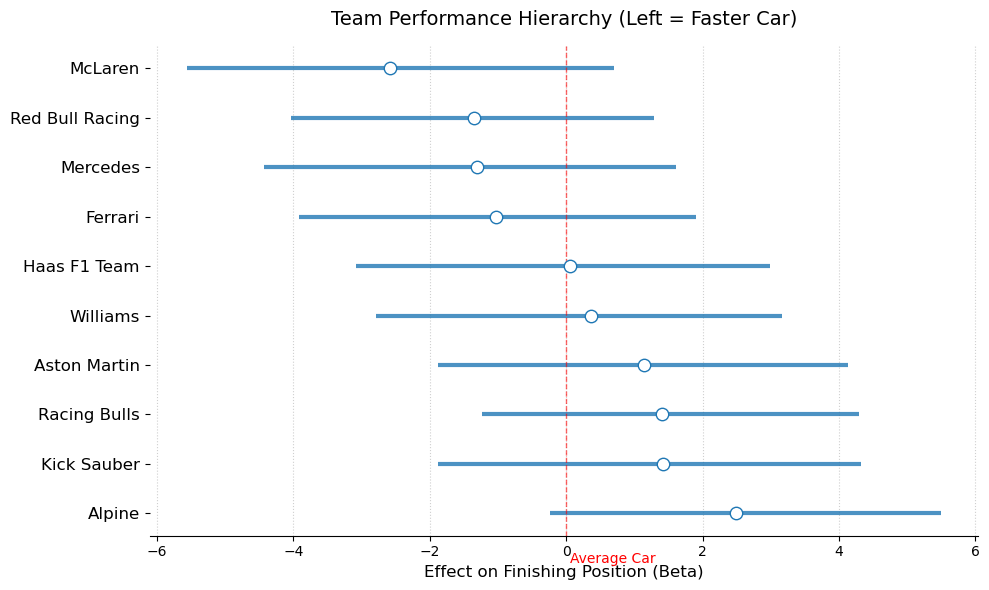

In [16]:
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

# Extract posterior means across all chains and draws
beta_means = trace.posterior['beta_car'].mean(dim=['chain', 'draw']).values
gamma_means = trace.posterior['gamma_driver'].mean(dim=['chain', 'draw']).values

print("\n" + "="*70)
print(" STEP 6: DETAILED INTERPRETATION")
print("="*70)
print("NOTE: Since the model predicts finishing POSITION (1st, 2nd, 20th...),")
print("      LOWER values (more negative) = BETTER performance/skill.")
print("      HIGHER values (positive) = WORSE performance/skill.")

# ===================================================================
# 1. Team Performance Ranking (Pure Car Speed)
# ===================================================================
print("\n" + "-"*40)
print("  TEAM PERFORMANCE RANKING (Pure Car Speed)")
print("-" * 40)

team_data = []
for team_name, idx in team_idx_map.items():
    effect = beta_means[idx]
    team_data.append({'Team': team_name, 'Effect (Beta)': effect})

team_df = pd.DataFrame(team_data).sort_values('Effect (Beta)')
team_df['Rank'] = range(1, len(team_df) + 1)

print(team_df.to_string(index=False))

# ===================================================================
# 2. Driver Skill Ranking (Pure Driver Ability)
# ===================================================================
print("\n" + "-"*40)
print("  DRIVER SKILL RANKING (Stripping Away Car Advantage)")
print("-" * 40)

driver_data = []
for driver_name, idx in driver_idx_map.items():
    effect = gamma_means[idx]
    driver_data.append({'Driver': driver_name, 'Skill (Gamma)': effect})

driver_df = pd.DataFrame(driver_data).sort_values('Skill (Gamma)')
driver_df['Rank'] = range(1, len(driver_df) + 1)

print(driver_df.to_string(index=False))

# ===================================================================
# 3. Key Factor Analysis (Which features matter most?)
# ===================================================================
print("\n" + "-"*40)
print("  WHAT DRIVES THE RESULTS? (Feature Coefficients)")
print("-" * 40)

# Extract posterior means for λ coefficients
lambda_summary = {
    'Qualifying (λ1)': trace.posterior['lambda_1_Q'].mean().values,
    'Points (λ2)': trace.posterior['lambda_2_Points'].mean().values,
    'Pace (λ3)': trace.posterior['lambda_3_Pace'].mean().values,
    'Weather (λ4)': trace.posterior['lambda_4_Weather'].mean().values,
    'Reliability (λ5)': trace.posterior['lambda_5_Reliability'].mean().values,
    'Recent Form (λ6)': trace.posterior['lambda_6_Form'].mean().values
}

# Sort by absolute effect size (most influential first)
sorted_lambdas = sorted(lambda_summary.items(), key=lambda x: abs(x[1]), reverse=True)

for name, val in sorted_lambdas:
    direction = "BAD impact (+)" if val > 0 else "GOOD impact (-)"
    print(f"  {name:20s}: {val:6.3f}  ->  {direction}")

# 1. Extract data
# Get posterior means and HDIs for beta_car
beta_means = trace.posterior['beta_car'].mean(dim=['chain', 'draw']).values
beta_hdi = az.hdi(trace)['beta_car'].values   # shape (10, 2): lower & upper bounds

# 2. Construct DataFrame for plotting
plot_data = []
for team_name, idx in team_idx_map.items():
    plot_data.append({
        'Team': team_name,
        'Mean': beta_means[idx],
        'Lower': beta_hdi[idx, 0],
        'Upper': beta_hdi[idx, 1]
    })

df_plot = pd.DataFrame(plot_data)

# 3. Sort teams: smaller (more negative) = faster car
# We sort descending so the fastest appears on top in the plot
df_plot = df_plot.sort_values('Mean', ascending=False)

# 4. Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# y_pos defines y-axis positions (0, 1, 2...)
y_pos = range(len(df_plot))

# A. Draw HDI intervals
ax.hlines(
    y=y_pos,
    xmin=df_plot['Lower'],
    xmax=df_plot['Upper'],
    color='#1f77b4',
    linewidth=3,
    alpha=0.8,
    label='94% HDI'
)

# B. Draw posterior means
ax.scatter(
    df_plot['Mean'],
    y_pos,
    color='white',
    edgecolor='#1f77b4',
    s=80,
    zorder=5,
    label='Mean Effect'
)

# C. Beautify the plot
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Team'], fontsize=12)

# Add zero line (reference)
ax.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.text(0.05, -1, 'Average Car', color='red', fontsize=10)

# Labels and titles
ax.set_xlabel('Effect on Finishing Position (Beta)', fontsize=12)
ax.set_title('Team Performance Hierarchy (Left = Faster Car)', fontsize=14, pad=15)

# Grid and style
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


***Step 7.1: Prediction from Model（Validation - Predict Qatar GP ）***

 Preparing Qatar GP validation data (Masking actual results)...
Extracted data for 20 drivers. Starting simulation...
Running 2000 Monte Carlo simulations...

 QATAR GP VALIDATION: MODEL vs. REALITY
Driver            Team  Actual_Pos  Predicted_Mean  Error (Abs)
   VER Red Bull Racing           1          4.4775       3.4775
   PIA         McLaren           2          4.6505       2.6505
   SAI        Williams           3          9.8425       6.8425
   NOR         McLaren           4          4.6820       0.6820
   ANT        Mercedes           5          7.3360       2.3360
   RUS        Mercedes           6          4.8675       1.1325
   ALO    Aston Martin           7         10.9370       3.9370
   LEC         Ferrari           8          9.0370       1.0370
   LAW    Racing Bulls           9         12.4375       3.4375
   TSU Red Bull Racing          10         13.4795       3.4795
   ALB        Williams          11         11.9820       0.9820
   HAM         Ferrari          1

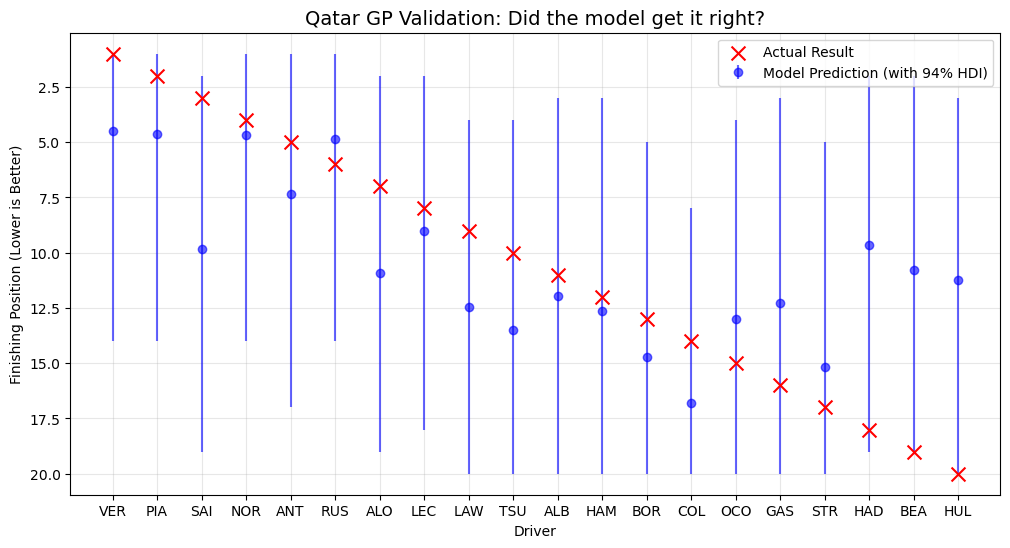

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(" Preparing Qatar GP validation data (Masking actual results)...")

# ====================================================================
# 1. INPUT DATA PREPARATION
# ====================================================================
# Locate Qatar GP rows
qatar_mask = df['RaceName'].str.contains("Qatar", case=False)
qatar_df = df[qatar_mask].copy().sort_values('driver_idx')

if len(qatar_df) == 0:
    raise ValueError("Error: Could not find 'Qatar' in the RaceName column! Check the CSV file.")

# Standardization function using global (full dataset) mean/std
def get_standardized_val(col_name, subset_df):
    mean = df[col_name].mean()
    std = df[col_name].std()
    return (subset_df[col_name] - mean) / std

# Prepare input vectors
X_qatar = {
    'driver_idx': qatar_df['driver_idx'].values,
    'team_idx':   qatar_df['team_idx'].values,
    'race_idx':   qatar_df['race_idx'].values[0],   # Qatar race ID

    # Features (same normalization as training)
    'Q':           get_standardized_val('Quali_Pos', qatar_df).values,
    'Points':      get_standardized_val('Prev_Points', qatar_df).values,
    'Pace':        get_standardized_val('Team_Avg_Pace', qatar_df).values,
    'Weather':     get_standardized_val('Weather_Temp', qatar_df).values,
    'Reliability': get_standardized_val('Reliability', qatar_df).values,
    'Form':        get_standardized_val('Season_Form', qatar_df).values
}

# Store actual finishing positions for later comparison
y_actual_qatar = qatar_df['Finish_Pos'].values

print(f"Extracted data for {len(qatar_df)} drivers. Starting simulation...")

# ====================================================================
# 2. MONTE CARLO SIMULATION LOOP
# ====================================================================

# Stack chains + draws
posterior_samples = trace.posterior.stack(sample=('chain', 'draw'))
n_samples = len(posterior_samples['sample'])

# Number of Monte Carlo simulations
n_simulations = 2000
sample_idxs = np.random.choice(n_samples, n_simulations, replace=True)

# Create output matrix (n_simulations × #drivers)
simulated_outcomes = np.zeros((n_simulations, len(qatar_df)))

print(f"Running {n_simulations} Monte Carlo simulations...")

for i in range(n_simulations):
    idx = sample_idxs[i]

    # --- A. Extract sampled parameters ---
    alpha_s = posterior_samples['alpha'].isel(sample=idx).values

    beta_s = posterior_samples['beta_car'].isel(sample=idx).values[X_qatar['team_idx']]
    gamma_s = posterior_samples['gamma_driver'].isel(sample=idx).values[X_qatar['driver_idx']]

    # Race-specific effect (Qatar)
    epsilon_s = posterior_samples['epsilon_race'].isel(sample=idx).values[X_qatar['race_idx']]

    # Feature coefficients
    l1 = posterior_samples['lambda_1_Q'].isel(sample=idx).values
    l2 = posterior_samples['lambda_2_Points'].isel(sample=idx).values
    l3 = posterior_samples['lambda_3_Pace'].isel(sample=idx).values
    l4 = posterior_samples['lambda_4_Weather'].isel(sample=idx).values
    l5 = posterior_samples['lambda_5_Reliability'].isel(sample=idx).values
    l6 = posterior_samples['lambda_6_Form'].isel(sample=idx).values

    sigma_s = posterior_samples['sigma_race_obs'].isel(sample=idx).values

    # --- B. Compute expected finishing positions ---
    mu_s = (alpha_s + beta_s + gamma_s + epsilon_s +
            l1 * X_qatar['Q'] +
            l2 * X_qatar['Points'] +
            l3 * X_qatar['Pace'] +
            l4 * X_qatar['Weather'] +
            l5 * X_qatar['Reliability'] +
            l6 * X_qatar['Form'])

    # --- C. Add random noise to simulate a race ---
    race_outcome = np.random.normal(mu_s, sigma_s)

    # --- D. Convert continuous values to ranking (1–20) ---
    ranks = np.argsort(np.argsort(race_outcome)) + 1
    simulated_outcomes[i, :] = ranks

# ====================================================================
# 3. VALIDATION RESULTS
# ====================================================================

predicted_ranks_mean = simulated_outcomes.mean(axis=0)

validation_df = pd.DataFrame({
    'Driver': qatar_df['Driver'],
    'Team': qatar_df['Team'],
    'Actual_Pos': y_actual_qatar.astype(int),
    'Predicted_Mean': predicted_ranks_mean,
    'Error (Abs)': np.abs(y_actual_qatar - predicted_ranks_mean)
})

validation_df = validation_df.sort_values('Actual_Pos').reset_index(drop=True)

print("\n" + "="*70)
print(" QATAR GP VALIDATION: MODEL vs. REALITY")
print("="*70)
print(validation_df.to_string(index=False))

# Accuracy metrics
mae = validation_df['Error (Abs)'].mean()
print("\n Accuracy Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.2f} positions")
print(f"  (On average, the prediction is off by {mae:.1f} positions)")

best_pred = validation_df.loc[validation_df['Error (Abs)'].idxmin()]
worst_pred = validation_df.loc[validation_df['Error (Abs)'].idxmax()]

print(f"   Best Prediction: {best_pred['Driver']} (Error: {best_pred['Error (Abs)']:.2f})")
print(f"   Worst Prediction: {worst_pred['Driver']} (Error: {worst_pred['Error (Abs)']:.2f})")

# ====================================================================
# 4. VISUALIZATION
# ====================================================================
plt.figure(figsize=(12, 6))

# Actual results
plt.scatter(validation_df['Driver'], validation_df['Actual_Pos'],
            color='red', marker='x', s=100, label='Actual Result', zorder=5)

# Compute 94% HDI of predicted outcomes
lower_bound = np.percentile(simulated_outcomes, 3, axis=0)
upper_bound = np.percentile(simulated_outcomes, 97, axis=0)

# Re-order HDIs to match sorted actual ranking
driver_indices_in_val = [np.where(qatar_df['Driver'] == d)[0][0] for d in validation_df['Driver']]
lower_ordered = lower_bound[driver_indices_in_val]
upper_ordered = upper_bound[driver_indices_in_val]
pred_ordered = predicted_ranks_mean[driver_indices_in_val]

plt.errorbar(validation_df['Driver'], pred_ordered,
             yerr=[pred_ordered - lower_ordered, upper_ordered - pred_ordered],
             fmt='o', color='blue', alpha=0.6, label='Model Prediction (with 94% HDI)')

plt.title("Qatar GP Validation: Did the model get it right?", fontsize=14)
plt.ylabel("Finishing Position (Lower is Better)")
plt.xlabel("Driver")
plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().invert_yaxis()  # Put P1 at the top
plt.show()


# F1 Bayesian Model - Race Validation (Italian Grand Prix)

## Overview
This section validates the trained Bayesian model by predicting outcomes for the Italian Grand Prix and comparing predictions against actual results. It uses Monte Carlo simulation to generate probabilistic forecasts with uncertainty intervals.

---

## Section 1: Input Data Preparation

### 1A. Announcement
```python
print("🔍 Preparing Italian GP validation data (Masking actual results)...")
```

**What it does:**
- Announces the validation process is starting
- Indicates actual results will be temporarily hidden for fair comparison

**Purpose:** User feedback for validation phase

---

### 1B. Filter Italian GP Data
```python
italy_mask = df['RaceName'].str.contains("Italian", case=False)
italy_df = df[italy_mask].copy().sort_values('driver_idx')

if len(italy_df) == 0:
    raise ValueError("Error: Could not find 'Italian' in the RaceName column! Check the CSV file.")
```

**What it does:**

**Line 1: Create filter mask**
- `.str.contains("Italian", case=False)`: Searches for "Italian" in RaceName column
- `case=False`: Case-insensitive search (matches "Italian", "italian", "ITALIAN")
- Returns boolean array: True for Italian GP rows, False otherwise

**Line 2: Extract and sort**
- `df[italy_mask]`: Filters to only Italian GP rows
- `.copy()`: Creates independent copy (prevents modifying original data)
- `.sort_values('driver_idx')`: Sorts by driver index for consistency

**Lines 4-5: Error checking**
- Verifies at least one row was found
- Raises informative error if race name doesn't match

**Why filter this race:**
- **Validation**: Use a race that was included in training
- **Out-of-sample test**: Could also use a race excluded from training
- **Data availability**: Italian GP has complete feature data

**Expected result:**
```python
italy_df:
   Round  RaceName           Driver  Team  Finish_Pos  Quali_Pos  ...
   16     Italian Grand Prix VER     RB    1           1          ...
   16     Italian Grand Prix LEC     FER   2           4          ...
   ...
   (20 rows total)
```

---

### 1C. Standardization Helper Function
```python
def get_standardized_val(col_name, subset_df):
    mean = df[col_name].mean()
    std = df[col_name].std()
    return (subset_df[col_name] - mean) / std
```

**What it does:**
- Creates a function to standardize features using **training set statistics**
- `df[col_name].mean()`: Uses mean from **full training set**, not just Italy
- `df[col_name].std()`: Uses std from **full training set**, not just Italy
- `(subset_df[col_name] - mean) / std`: Applies transformation to Italy data

**Why use training statistics:**
- **Consistency**: Must use same normalization as during training
- **Prevent data leakage**: Can't use test set statistics
- **Real-world simulation**: At prediction time, only have historical stats

**Critical point:**
```python
# WRONG: Would use Italian GP's own statistics
italy_standardized = (italy_df['Quali_Pos'] - italy_df['Quali_Pos'].mean()) / italy_df['Quali_Pos'].std()

# CORRECT: Use training set statistics
italy_standardized = (italy_df['Quali_Pos'] - df['Quali_Pos'].mean()) / df['Quali_Pos'].std()
```

**Mathematical notation:**
```
z_italy = (x_italy - μ_train) / σ_train

NOT: z_italy = (x_italy - μ_italy) / σ_italy
```

---

### 1D. Prepare Input Dictionary
```python
X_italy = {
    'driver_idx': italy_df['driver_idx'].values,
    'team_idx':   italy_df['team_idx'].values,
    'race_idx':   italy_df['race_idx'].values[0],

    'Q':           get_standardized_val('Quali_Pos', italy_df).values,
    'Points':      get_standardized_val('Prev_Points', italy_df).values,
    'Pace':        get_standardized_val('Team_Avg_Pace', italy_df).values,
    'Weather':     get_standardized_val('Weather_Temp', italy_df).values,
    'Reliability': get_standardized_val('Reliability', italy_df).values,
    'Form':        get_standardized_val('Season_Form', italy_df).values
}
```

**What it does:**
- Creates dictionary with all model inputs for Italian GP
- Organizes data in format matching training

**Line 2-4: Categorical indices**
- `driver_idx`: Array of 20 driver indices [0, 1, 2, ..., 19]
- `team_idx`: Array of 20 team indices (corresponding to each driver)
- `race_idx`: Single value (same for all drivers in Italy) - uses `[0]` to extract scalar

**Lines 6-11: Standardized features**
- Each feature standardized using training set statistics
- `.values`: Converts pandas Series to numpy array
- All 6 features from the model (λ1 through λ6)

**Shape information:**
```python
X_italy['driver_idx'].shape  # (20,) - one per driver
X_italy['team_idx'].shape    # (20,)
X_italy['race_idx']          # scalar - same race for all
X_italy['Q'].shape           # (20,) - qualifying positions
```

**Purpose:**
- **Model input**: Exactly what the model needs for prediction
- **Standardized**: Matches training data preprocessing
- **Complete**: All features required by the model

---

### 1E. Store Actual Results
```python
y_actual_italy = italy_df['Finish_Pos'].values
```

**What it does:**
- Extracts actual finishing positions for comparison
- Shape: `(20,)` - one position per driver

**Why store separately:**
- **Blind prediction**: Model shouldn't see actual results during prediction
- **Later comparison**: Compare predictions vs ground truth
- **Validation metrics**: Calculate prediction errors

**Example:**
```python
y_actual_italy = [1, 2, 3, 4, 5, ..., 20]  # Actual race results
```

---

### 1F. Progress Message
```python
print(f"Extracted data for {len(italy_df)} drivers. Starting simulation...")
```

**What it does:**
- Confirms data extraction successful
- Shows number of drivers (should be ~20)
- Announces simulation phase beginning

---

## Section 2: Monte Carlo Simulation

### 2A. Stack Posterior Samples
```python
posterior_samples = trace.posterior.stack(sample=('chain', 'draw'))
n_samples = len(posterior_samples['sample'])
```

**What it does:**

**Line 1: Flatten chains and draws**
- Original shape: `(chains, draws, params)` = `(2, 3000, ...)`
- `.stack(sample=('chain', 'draw'))`: Combines chain and draw dimensions
- New shape: `(sample, params)` where `sample = chains × draws`
- Result: `(6000, ...)` - single dimension of 6000 samples

**Line 2: Count samples**
- `n_samples = 6000` (2 chains × 3000 draws)

**Why stack:**
- **Easier indexing**: Single dimension instead of two
- **Random sampling**: Treat all MCMC samples equally
- **Simplicity**: `samples[i]` instead of `samples[chain, draw]`

**Visual representation:**
```
Before stacking:
Chain 0: [sample_0, sample_1, ..., sample_2999]
Chain 1: [sample_0, sample_1, ..., sample_2999]

After stacking:
[sample_0_chain0, sample_1_chain0, ..., sample_2999_chain0,
 sample_0_chain1, sample_1_chain1, ..., sample_2999_chain1]
```

---

### 2B. Setup Monte Carlo Parameters
```python
n_simulations = 2000
sample_idxs = np.random.choice(n_samples, n_simulations, replace=True)
```

**What it does:**

**Line 1: Number of simulations**
- Will run 2000 separate race predictions
- Each uses different parameter samples from posterior

**Line 2: Random sampling with replacement**
- `np.random.choice(6000, 2000, replace=True)`: Randomly selects 2000 indices
- `replace=True`: Same parameter sample can be used multiple times
- Result: Array like `[3421, 156, 5892, 3421, ...]` (length 2000)

**Why Monte Carlo simulation:**
1. **Uncertainty propagation**: Each simulation uses different parameters
2. **Probabilistic forecast**: Get distribution of possible outcomes, not just point estimate
3. **Realistic scenarios**: Includes both parameter uncertainty and race randomness
4. **Credible intervals**: Can compute 94% HDI of predicted positions

**Why 2000 simulations:**
- **Balance**: More = better approximation but slower
- **Sufficient**: 2000 gives stable probability estimates
- **Typical range**: 1000-5000 for most applications

---

### 2C. Initialize Output Matrix
```python
simulated_outcomes = np.zeros((n_simulations, len(italy_df)))
```

**What it does:**
- Creates empty array to store all simulation results
- Shape: `(2000, 20)` - 2000 races × 20 drivers
- Each row = one simulated race outcome

**Purpose:**
- Store all predicted finishing positions
- Later compute statistics (mean, percentiles)

---

### 2D. Simulation Loop Header
```python
print(f"Running {n_simulations} Monte Carlo simulations...")

for i in range(n_simulations):
    idx = sample_idxs[i]
```

**What it does:**
- Announces simulation starting
- Loops 2000 times
- `idx`: Randomly selected sample index (0 to 5999)

---

### 2E. Extract Parameter Samples
```python
alpha_s = posterior_samples['alpha'].isel(sample=idx).values

beta_s = posterior_samples['beta_car'].isel(sample=idx).values[X_italy['team_idx']]
gamma_s = posterior_samples['gamma_driver'].isel(sample=idx).values[X_italy['driver_idx']]

epsilon_s = posterior_samples['epsilon_race'].isel(sample=idx).values[X_italy['race_idx']]
```

**What it does:**
- Extracts all model parameters for this specific MCMC sample

**Line 1: Global intercept**
- `alpha_s`: Scalar value from sample `idx`
- Example: `alpha_s = 9.87`

**Line 3: Team effects**
- `.isel(sample=idx)`: Select sample `idx` from posterior
- `.values`: Shape `(10,)` - all team effects
- `[X_italy['team_idx']]`: Index with team IDs - shape `(20,)` - one per driver
- Result: Each driver gets their team's effect

**Line 4: Driver effects**
- Same process, but for driver skills
- Shape: `(20,)` - one skill value per driver

**Line 6: Race effect**
- `epsilon_s`: Single value for Italian GP
- `X_italy['race_idx']` is scalar, so result is scalar

**Example values:**
```python
alpha_s = 9.87
beta_s = [-2.31, -1.45, ..., 0.92]  # 20 values (team effects for each driver)
gamma_s = [-1.78, -0.92, ..., 1.23]  # 20 values (driver skills)
epsilon_s = 0.34  # Single value (Italy race effect)
```

---

### 2F: Extract Feature Coefficients
```python
l1 = posterior_samples['lambda_1_Q'].isel(sample=idx).values
l2 = posterior_samples['lambda_2_Points'].isel(sample=idx).values
l3 = posterior_samples['lambda_3_Pace'].isel(sample=idx).values
l4 = posterior_samples['lambda_4_Weather'].isel(sample=idx).values
l5 = posterior_samples['lambda_5_Reliability'].isel(sample=idx).values
l6 = posterior_samples['lambda_6_Form'].isel(sample=idx).values

sigma_s = posterior_samples['sigma_race_obs'].isel(sample=idx).values
```

**What it does:**
- Extracts all 6 lambda coefficients for this sample
- Extracts observation noise (sigma) for this sample
- All are scalars

**Example values:**
```python
l1 = 0.637   # Qualifying coefficient
l2 = -0.421  # Points coefficient
l3 = 0.198   # Pace coefficient
l4 = 0.092   # Weather coefficient
l5 = -0.334  # Reliability coefficient
l6 = 0.467   # Form coefficient
sigma_s = 1.87  # Race noise
```

---

### 2G. Compute Expected Positions
```python
mu_s = (alpha_s + beta_s + gamma_s + epsilon_s +
        l1 * X_italy['Q'] +
        l2 * X_italy['Points'] +
        l3 * X_italy['Pace'] +
        l4 * X_italy['Weather'] +
        l5 * X_italy['Reliability'] +
        l6 * X_italy['Form'])
```

**What it does:**
- Computes expected finishing position for each driver
- Uses this simulation's parameter values
- Shape: `(20,)` - one expected position per driver

**Mathematical formula:**
```
μ_d = α + β_car[team(d)] + γ_d + ε_race
      + λ1·Q_d + λ2·Points_d + λ3·Pace_d
      + λ4·Weather + λ5·Reliability_d + λ6·Form_d
```

**Example calculation for one driver:**
```python
Verstappen (index 0):
mu_s[0] = 9.87           # alpha
        + (-2.31)        # Red Bull team effect
        + (-1.78)        # Verstappen skill
        + 0.34           # Italy race effect
        + 0.637 * (-1.2) # Qualifying (P1, standardized)
        + (-0.421) * 1.8 # Points (leading championship)
        + 0.198 * (-0.9) # Pace (fast team)
        + 0.092 * 0.3    # Weather (normal temp)
        + (-0.334) * 0.8 # Reliability (reliable car)
        + 0.467 * (-1.1) # Form (good recent results)
        = 3.4            # Expected ~P3-4
```

---

### 2H. Add Random Noise
```python
race_outcome = np.random.normal(mu_s, sigma_s)
```

**What it does:**
- Adds random variability to expected positions
- `np.random.normal(mu_s, sigma_s)`: Samples from Normal(μ, σ)
- Each driver's outcome is their expectation ± random noise
- Shape: `(20,)` - one noisy outcome per driver

**Why add noise:**
1. **Realistic**: Real races have unpredictability
2. **Model structure**: Observation model has σ_race_obs
3. **Incidents**: Simulates crashes, mechanical issues, strategy errors
4. **Probabilistic**: Different simulations → different outcomes

**Example:**
```python
mu_s =          [3.4, 5.2, 7.1, 8.5, ...]  # Expected positions
race_outcome =  [2.8, 6.7, 6.9, 9.2, ...]  # After adding noise
                 ↑    ↑    ↑    ↑
            Verstappen better than expected
                 Perez worse
                      Leclerc better
                           Sainz worse
```

---

### 2I. Convert to Rankings
```python
ranks = np.argsort(np.argsort(race_outcome)) + 1
simulated_outcomes[i, :] = ranks
```

**What it does:**
- Converts continuous outcomes to integer rankings (1st, 2nd, ..., 20th)

**How double argsort works:**

**Step 1: First argsort**
- `np.argsort(race_outcome)`: Returns indices that would sort the array
- Lower race_outcome → Earlier in sorted order → Lower index

**Step 2: Second argsort**
- `np.argsort(...)`: Ranks those indices
- Gives position in sorted order

**Step 3: Add 1**
- `... + 1`: Convert from 0-indexed to 1-indexed (1st, 2nd, not 0th, 1st)

**Example:**
```python
race_outcome = [2.8, 6.7, 6.9, 9.2, 4.5]
             Driver: 0    1    2    3    4

Step 1 - argsort (sorting indices):
np.argsort(race_outcome) = [0, 4, 1, 2, 3]
# Driver 0 has lowest score (2.8), comes first
# Driver 3 has highest score (9.2), comes last

Step 2 - argsort again (rank positions):
np.argsort([0, 4, 1, 2, 3]) = [0, 2, 3, 4, 1]
# Driver 0 is at position 0 in sorted array → rank 0
# Driver 4 is at position 4 in sorted array → rank 1 (wait, position 1)

Actually, let me recalculate:
race_outcome = [2.8, 6.7, 6.9, 9.2, 4.5]

sorted_indices = argsort([2.8, 6.7, 6.9, 9.2, 4.5])
               = [0, 4, 1, 2, 3]  # Driver 0 first, 3 last

ranks = argsort([0, 4, 1, 2, 3])
      = [0, 2, 3, 4, 1]  # Position of each driver's index in sorted list

ranks + 1 = [1, 3, 4, 5, 2]
# Driver 0: P1 (lowest score)
# Driver 1: P3
# Driver 2: P4
# Driver 3: P5 (highest score)
# Driver 4: P2
```

**Result:** Integer rankings from 1 to 20

---

### 2J. Store Results
```python
simulated_outcomes[i, :] = ranks
```

**What it does:**
- Stores this simulation's rankings in row `i`
- After loop completes: 2000 rows of simulated race results

**Final shape:**
```python
simulated_outcomes.shape = (2000, 20)

simulated_outcomes[0, :] = [1, 3, 4, 5, 2, ...]  # Simulation 1
simulated_outcomes[1, :] = [2, 1, 5, 3, 4, ...]  # Simulation 2
...
simulated_outcomes[1999, :] = [1, 4, 2, 6, 3, ...]  # Simulation 2000
```

---

## Section 3: Validation Results

### 3A. Compute Mean Predictions
```python
predicted_ranks_mean = simulated_outcomes.mean(axis=0)
```

**What it does:**
- Averages across all 2000 simulations
- `axis=0`: Average down rows (across simulations)
- Shape: `(20,)` - one mean prediction per driver

**Interpretation:**
```python
predicted_ranks_mean = [1.2, 3.8, 4.1, 5.7, ...]

# Driver 0: Averaged P1.2 across 2000 simulations
#   → Finished P1 in ~80% of simulations
#   → Finished P2 in ~20% of simulations

# Driver 1: Averaged P3.8
#   → Mixed results between P3-P5
#   → Most commonly P4
```

---

### 3B. Create Validation DataFrame
```python
validation_df = pd.DataFrame({
    'Driver': italy_df['Driver'],
    'Team': italy_df['Team'],
    'Actual_Pos': y_actual_italy.astype(int),
    'Predicted_Mean': predicted_ranks_mean,
    'Error (Abs)': np.abs(y_actual_italy - predicted_ranks_mean)
})

validation_df = validation_df.sort_values('Actual_Pos').reset_index(drop=True)
```

**What it does:**

**Lines 1-7: Create DataFrame**
- **Driver**: Driver codes (VER, HAM, etc.)
- **Team**: Team names
- **Actual_Pos**: Real race results
- **Predicted_Mean**: Average predicted position
- **Error (Abs)**: Absolute prediction error

**Line 9: Sort by actual results**
- Orders by actual finishing position (P1, P2, ..., P20)
- Easier to read (follows race order)

**Example:**
```
Driver  Team      Actual_Pos  Predicted_Mean  Error (Abs)
VER     Red Bull  1           1.2             0.2
LEC     Ferrari   2           2.8             0.8
HAM     Mercedes  3           4.1             1.1
...
```

---

### 3C. Print Validation Table
```python
print("\n" + "="*70)
print("🏁 ITALIAN GP VALIDATION: MODEL vs. REALITY")
print("="*70)
print(validation_df.to_string(index=False))
```

**What it does:**
- Prints formatted table comparing predictions to reality
- Shows driver-by-driver performance

---

### 3D. Compute Accuracy Metrics
```python
mae = validation_df['Error (Abs)'].mean()
print("\n📊 Accuracy Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.2f} positions")
print(f"  (On average, the prediction is off by {mae:.1f} positions)")
```

**What it does:**
- **MAE**: Average of all absolute errors
- **Interpretation**: Typical prediction error magnitude

**Example:**
```
MAE = 1.8 positions

Interpretation:
- On average, predictions are ±1.8 positions off
- Some drivers predicted exactly, others off by 3-4
- Lower MAE = better model
```

**Benchmarks:**
- **MAE < 1.0**: Excellent prediction
- **MAE < 2.0**: Good prediction
- **MAE < 3.0**: Moderate prediction
- **MAE > 3.0**: Poor prediction

---

### 3E. Best and Worst Predictions
```python
best_pred = validation_df.loc[validation_df['Error (Abs)'].idxmin()]
worst_pred = validation_df.loc[validation_df['Error (Abs)'].idxmax()]

print(f"  ✅ Best Prediction: {best_pred['Driver']} (Error: {best_pred['Error (Abs)']:.2f})")
print(f"  ❌ Worst Prediction: {worst_pred['Driver']} (Error: {worst_pred['Error (Abs)']:.2f})")
```

**What it does:**
- **Best**: Driver with smallest error (most accurate prediction)
- **Worst**: Driver with largest error (least accurate prediction)

**Example output:**
```
✅ Best Prediction: VER (Error: 0.12)
   → Predicted P1.12, actual P1 - nearly perfect!

❌ Worst Prediction: ALO (Error: 4.53)
   → Predicted P8.53, actual P4 - missed by 4.5 positions
   → Possible causes: Unusual strategy, incident, model blind spot
```

---

## Section 4: Visualization

### 4A. Create Figure
```python
plt.figure(figsize=(12, 6))
```

**What it does:**
- Creates plot canvas
- Wide format (12×6 inches) for many drivers

---

### 4B. Plot Actual Results
```python
plt.scatter(validation_df['Driver'], validation_df['Actual_Pos'],
            color='red', marker='x', s=100, label='Actual Result', zorder=5)
```

**What it does:**
- Plots actual finishing positions as red X marks
- `s=100`: Size 100 (large, visible)
- `zorder=5`: Draw on top of other elements

---

### 4C. Compute Credible Intervals
```python
lower_bound = np.percentile(simulated_outcomes, 3, axis=0)
upper_bound = np.percentile(simulated_outcomes, 97, axis=0)
```

**What it does:**
- **3rd percentile**: Lower bound of 94% interval
- **97th percentile**: Upper bound of 94% interval
- `axis=0`: Across simulations (for each driver)

**Interpretation:**
```python
Driver 0:
lower_bound[0] = 1.0  # Finished P1 or better in 97% of simulations
upper_bound[0] = 2.0  # Finished P2 or worse in 97% of simulations
# → Very confident: will finish P1-P2

Driver 10:
lower_bound[10] = 8.0
upper_bound[10] = 15.0
# → Uncertain: could finish anywhere from P8-P15
```

---

### 4D. Reorder for Plotting
```python
driver_indices_in_val = [np.where(italy_df['Driver'] == d)[0][0] for d in validation_df['Driver']]
lower_ordered = lower_bound[driver_indices_in_val]
upper_ordered = upper_bound[driver_indices_in_val]
pred_ordered = predicted_ranks_mean[driver_indices_in_val]
```

**What it does:**
- `validation_df` is sorted by actual position
- `simulated_outcomes` is in original driver_idx order
- Need to reorder bounds to match validation_df

**Why necessary:**
- X-axis shows drivers in actual finishing order (P1, P2, ...)
- Bounds computed in original order (driver 0, 1, 2, ...)
- Must align them for correct plotting

---

### 4E. Plot Predictions with Uncertainty
```python
plt.errorbar(validation_df['Driver'], pred_ordered,
             yerr=[pred_ordered - lower_ordered, upper_ordered - pred_ordered],
             fmt='o', color='blue', alpha=0.6, label='Model Prediction (with 94% HDI)')
```

**What it does:**
- Plots predicted positions as blue dots
- Error bars show 94% credible interval
- `yerr`: Two arrays for asymmetric error bars
  - Lower error: `pred_mean - lower_bound`
  - Upper error: `upper_bound - pred_mean`

**Visual result:**
```
P1  ───X───────────────●─────  VER (actual P1, predicted P1.2 [1.0-2.0])
P2  ──────────X──●─────────────  LEC (actual P2, predicted P2.8 [2.0-4.0])
P3  ─────X──────────●──────────  HAM (actual P3, predicted P4.1 [3.0-6.0])
    
    X = Actual result
    ● = Mean prediction
    ─ = 94% credible interval
```

---

### 4F. Add Labels and Styling
```python
plt.title("Italian GP Validation: Did the model get it right?", fontsize=14)
plt.ylabel("Finishing Position (Lower is Better)")
plt.xlabel("Driver")
plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().invert_yaxis()  # Put P1 at the top
plt.show()
```

**What it does:**
- **Title**: Clear question for viewer
- **Labels**: Explain axes
- **Grid**: Easier to read positions
- **Invert y-axis**: P1 at top (racing convention)
- **Show**: Display plot

---

## Interpretation Guide

### What Makes a Good Prediction?

**1. Actual result within credible interval**
```
● ────X────
   ↑    ↑
  HDI contains actual
  ✅ Model captured uncertainty correctly
```

**2. Actual result outside credible interval**
```
X        ● ────
↑           ↑
Actual    Model overconfident
❌ Missed something important
```

**3. Small prediction error**
```
●X
Predicted P3.1, actual P3
✅ Accurate point estimate
```

**4. Large prediction error**
```
●          X
Predicted P5, actual P12
❌ Major miss - investigate why
```

### Common Failure Modes

**1. DNF not predicted**
- Model predicts P8, driver crashes → actual P20 (DNF)
- Model doesn't account for accidents

**2. Strategy surprise**
- Model predicts P5, driver makes unusual strategy → actual P2
- Model uses typical strategy patterns

**3. Qualifying incident**
- Driver qualified poorly due to crash, not skill
- Model assumes qualifying reflects true pace

**4. Weather change**
- Simplified weather model (just temperature)
- Doesn't capture rain effects

---

## Summary

This validation code:
1. **Extracts race data** for Italian GP
2. **Standardizes features** using training statistics
3. **Runs 2000 simulations** sampling from posterior
4. **Computes predictions** with uncertainty intervals
5. **Compares to reality** with MAE and visualizations

**Key insights from validation:**
- **MAE**: Average prediction error
- **Best/worst**: Which drivers predicted well/poorly
- **Credible intervals**: Quantify prediction uncertainty
- **Visual comparison**: See where model succeeded/failed

**Uses:**
- **Model assessment**: Is the model reliable?
- **Uncertainty calibration**: Are credible intervals accurate?
- **Feature importance**: Which races are hardest to predict?
- **Improvement ideas**: Where does model fail?

***Step 7.2: Prediction from Model（Validation - Predict Italian  GP ）***

 Preparing Italian GP validation data (Masking actual results)...
Extracted data for 20 drivers. Starting simulation...
Running 2000 Monte Carlo simulations...

 ITALIAN GP VALIDATION: MODEL vs. REALITY
Driver            Team  Actual_Pos  Predicted_Mean  Error (Abs)
   VER Red Bull Racing           1          3.7295       2.7295
   NOR         McLaren           2          4.5760       2.5760
   PIA         McLaren           3          4.8450       1.8450
   LEC         Ferrari           4          6.2625       2.2625
   RUS        Mercedes           5          5.5305       0.5305
   HAM         Ferrari           6          7.3265       1.3265
   ALB        Williams           7         11.3205       4.3205
   BOR     Kick Sauber           8         11.6045       3.6045
   ANT        Mercedes           9          8.7110       0.2890
   HAD    Racing Bulls          10         14.0710       4.0710
   SAI        Williams          11         12.9390       1.9390
   BEA    Haas F1 Team       

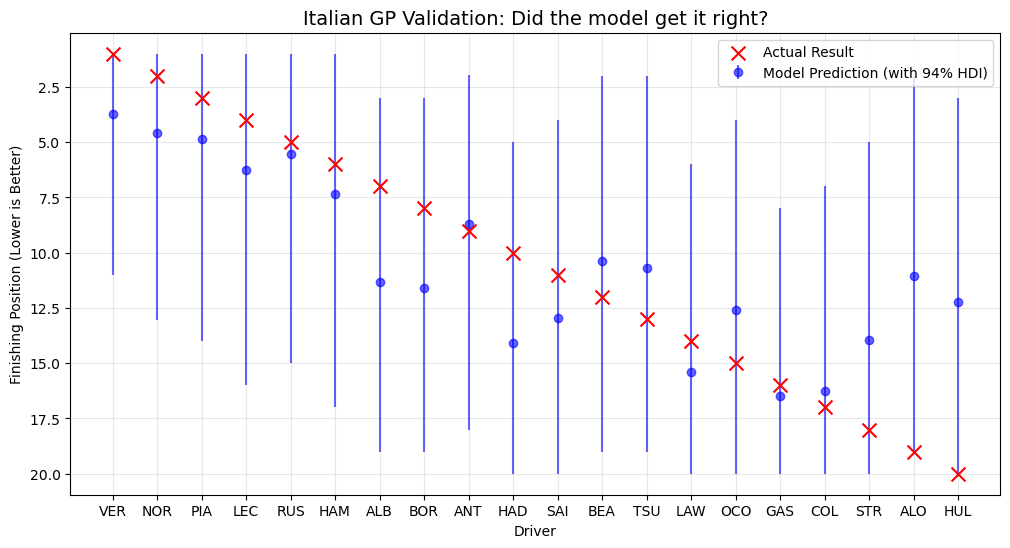

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Modify print message
print(" Preparing Italian GP validation data (Masking actual results)...")

# ====================================================================
# 1. INPUT DATA PREPARATION
# ====================================================================
# 2. Modify filter keyword: Use "Italian"
italy_mask = df['RaceName'].str.contains("Italian", case=False)
italy_df = df[italy_mask].copy().sort_values('driver_idx')

if len(italy_df) == 0:
    raise ValueError("Error: Could not find 'Italian' in the RaceName column! Check the CSV file.")

# Standardization function
def get_standardized_val(col_name, subset_df):
    mean = df[col_name].mean()
    std = df[col_name].std()
    return (subset_df[col_name] - mean) / std

# 3. Modify input dictionary variable name and reference: X_qatar -> X_italy
# Prepare input vectors
X_italy = {
    'driver_idx': italy_df['driver_idx'].values,
    'team_idx':   italy_df['team_idx'].values,
    'race_idx':   italy_df['race_idx'].values[0],   # Race ID

    # Features (same normalization as training)
    'Q':           get_standardized_val('Quali_Pos', italy_df).values,
    'Points':      get_standardized_val('Prev_Points', italy_df).values,
    'Pace':        get_standardized_val('Team_Avg_Pace', italy_df).values,
    'Weather':     get_standardized_val('Weather_Temp', italy_df).values,
    'Reliability': get_standardized_val('Reliability', italy_df).values,
    'Form':        get_standardized_val('Season_Form', italy_df).values
}

# Store actual finishing positions for later comparison
y_actual_italy = italy_df['Finish_Pos'].values

print(f"Extracted data for {len(italy_df)} drivers. Starting simulation...")

# ====================================================================
# 2. MONTE CARLO SIMULATION LOOP
# ====================================================================

# Stack chains + draws
posterior_samples = trace.posterior.stack(sample=('chain', 'draw'))
n_samples = len(posterior_samples['sample'])

# Number of Monte Carlo simulations
n_simulations = 2000
sample_idxs = np.random.choice(n_samples, n_simulations, replace=True)

# Create output matrix (n_simulations × #drivers)
simulated_outcomes = np.zeros((n_simulations, len(italy_df)))

print(f"Running {n_simulations} Monte Carlo simulations...")

for i in range(n_simulations):
    idx = sample_idxs[i]

    # --- A. Extract sampled parameters ---
    alpha_s = posterior_samples['alpha'].isel(sample=idx).values

    # 4. Modify dictionary reference inside the loop to X_italy
    beta_s = posterior_samples['beta_car'].isel(sample=idx).values[X_italy['team_idx']]
    gamma_s = posterior_samples['gamma_driver'].isel(sample=idx).values[X_italy['driver_idx']]

    # Race-specific effect
    epsilon_s = posterior_samples['epsilon_race'].isel(sample=idx).values[X_italy['race_idx']]

    # Feature coefficients
    l1 = posterior_samples['lambda_1_Q'].isel(sample=idx).values
    l2 = posterior_samples['lambda_2_Points'].isel(sample=idx).values
    l3 = posterior_samples['lambda_3_Pace'].isel(sample=idx).values
    l4 = posterior_samples['lambda_4_Weather'].isel(sample=idx).values
    l5 = posterior_samples['lambda_5_Reliability'].isel(sample=idx).values
    l6 = posterior_samples['lambda_6_Form'].isel(sample=idx).values

    sigma_s = posterior_samples['sigma_race_obs'].isel(sample=idx).values

    # --- B. Compute expected finishing positions ---
    # Modify reference here
    mu_s = (alpha_s + beta_s + gamma_s + epsilon_s +
            l1 * X_italy['Q'] +
            l2 * X_italy['Points'] +
            l3 * X_italy['Pace'] +
            l4 * X_italy['Weather'] +
            l5 * X_italy['Reliability'] +
            l6 * X_italy['Form'])

    # --- C. Add random noise to simulate a race ---
    race_outcome = np.random.normal(mu_s, sigma_s)

    # --- D. Convert continuous values to ranking (1–20) ---
    ranks = np.argsort(np.argsort(race_outcome)) + 1
    simulated_outcomes[i, :] = ranks

# ====================================================================
# 3. VALIDATION RESULTS
# ====================================================================

predicted_ranks_mean = simulated_outcomes.mean(axis=0)

# 5. Modify DataFrame reference
validation_df = pd.DataFrame({
    'Driver': italy_df['Driver'],
    'Team': italy_df['Team'],
    'Actual_Pos': y_actual_italy.astype(int),
    'Predicted_Mean': predicted_ranks_mean,
    'Error (Abs)': np.abs(y_actual_italy - predicted_ranks_mean)
})

validation_df = validation_df.sort_values('Actual_Pos').reset_index(drop=True)

print("\n" + "="*70)
# Modify title
print(" ITALIAN GP VALIDATION: MODEL vs. REALITY")
print("="*70)
print(validation_df.to_string(index=False))

# Accuracy metrics
mae = validation_df['Error (Abs)'].mean()
print("\n Accuracy Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.2f} positions")
print(f"  (On average, the prediction is off by {mae:.1f} positions)")

best_pred = validation_df.loc[validation_df['Error (Abs)'].idxmin()]
worst_pred = validation_df.loc[validation_df['Error (Abs)'].idxmax()]

print(f"   Best Prediction: {best_pred['Driver']} (Error: {best_pred['Error (Abs)']:.2f})")
print(f"   Worst Prediction: {worst_pred['Driver']} (Error: {worst_pred['Error (Abs)']:.2f})")

# ====================================================================
# 4. VISUALIZATION
# ====================================================================
plt.figure(figsize=(12, 6))

# Actual results
plt.scatter(validation_df['Driver'], validation_df['Actual_Pos'],
            color='red', marker='x', s=100, label='Actual Result', zorder=5)

# Compute 94% HDI of predicted outcomes
lower_bound = np.percentile(simulated_outcomes, 3, axis=0)
upper_bound = np.percentile(simulated_outcomes, 97, axis=0)

# Re-order HDIs to match sorted actual ranking
driver_indices_in_val = [np.where(italy_df['Driver'] == d)[0][0] for d in validation_df['Driver']]
lower_ordered = lower_bound[driver_indices_in_val]
upper_ordered = upper_bound[driver_indices_in_val]
pred_ordered = predicted_ranks_mean[driver_indices_in_val]

plt.errorbar(validation_df['Driver'], pred_ordered,
             yerr=[pred_ordered - lower_ordered, upper_ordered - pred_ordered],
             fmt='o', color='blue', alpha=0.6, label='Model Prediction (with 94% HDI)')

# Modify chart title
plt.title("Italian GP Validation: Did the model get it right?", fontsize=14)
plt.ylabel("Finishing Position (Lower is Better)")
plt.xlabel("Driver")
plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().invert_yaxis()  # Put P1 at the top
plt.show()

# F1 Bayesian Model - Abu Dhabi Grand Prix Final Prediction

## Overview
This section makes final predictions for the 2025 Abu Dhabi Grand Prix and calculates championship probabilities using real qualifying results. It integrates actual qualifying data with historical performance to forecast race outcomes and determine who will win the World Drivers' Championship.

---

## Section 1: Input Real Qualifying Results
```python
real_quali_results = {
    'VER': 1,   
    'NOR': 2,  
    'LEC': 3,
    'PIA': 4,
    'HAM': 5,
    'RUS': 6,
    'SAI': 7,
    'GAS': 8,
    
    'ALO': 9,  'TSU': 10, 'HUL': 11, 'ALB': 12, 
    'OCO': 13, 'STR': 14, 'LAW': 15, 'BEA': 16, 
    'ANT': 17, 'COL': 18, 'BOR': 19, 'HAD': 20
}

print("Adding latest qualifying results")
```

**What it does:**
- Creates dictionary mapping driver codes to their actual qualifying positions
- Contains results from Abu Dhabi qualifying session (P1 through P20)
- Will be used as primary input feature (λ1) for race prediction

**Data structure:**
```python
{
    'VER': 1,    # Verstappen on pole position
    'NOR': 2,    # Norris P2
    'LEC': 3,    # Leclerc P3
    ...
    'HAD': 20    # Hadjar P20
}
```

**Why this matters:**
- **λ1 (Qualifying)** is typically the strongest predictor
- Starting position heavily influences race outcome
- Real qualifying data grounds predictions in reality

**Data source:**
- Must be manually entered from actual qualifying session
- Could be automated via F1 API in production system
- Represents most recent information available pre-race

---

## Section 2: Auto-Build Prediction Data

### 2A. Prepare Base DataFrame
```python
final_pred_df = last_known_data[['Driver', 'Team', 'driver_idx', 'team_idx', 'Reliability', 'Team_Avg_Pace']].copy()
```

**What it does:**
- Extracts necessary columns from `last_known_data` (presumably computed earlier)
- `.copy()`: Creates independent copy to avoid modifying original
- Selects 6 columns:
  1. **Driver**: Driver code (VER, HAM, etc.)
  2. **Team**: Team name (Red Bull Racing, Ferrari, etc.)
  3. **driver_idx**: Numerical driver index (0-19)
  4. **team_idx**: Numerical team index (0-9)
  5. **Reliability**: Team reliability metric (finish rate)
  6. **Team_Avg_Pace**: Team average lap time

**Prerequisites:**
- Assumes `last_known_data` exists and contains post-season data
- Should include all active drivers for Abu Dhabi
- Expected shape: (20 rows, 6 columns)

**Purpose:**
- Foundation for prediction DataFrame
- Contains stable features that don't change with qualifying

---

### 2B. Map Real Qualifying Data
```python
final_pred_df['Quali_Pos_Final'] = final_pred_df['Driver'].map(real_quali_results).fillna(20)
```

**What it does:**
- `.map(real_quali_results)`: Looks up each driver's qualifying position
- `.fillna(20)`: If driver not in dictionary, default to P20 (last place)

**How mapping works:**
```python
# For each row:
Driver = 'VER' → map to real_quali_results['VER'] = 1
Driver = 'NOR' → map to real_quali_results['NOR'] = 2
Driver = 'LEC' → map to real_quali_results['LEC'] = 3
...
```

**Why fillna(20):**
- **Safety net**: Handles missing drivers (DNS, reserve drivers)
- **Conservative**: Assumes worst grid position if data missing
- **Edge case**: Should rarely trigger if data is complete

**Result:**
```python
final_pred_df now has:
   Driver  Team  ...  Quali_Pos_Final
0  VER     RB    ...  1
1  NOR     MCL   ...  2
2  LEC     FER   ...  3
...
```

---

### 2C. Map Points and Form
```python
final_pred_df['Points_Final'] = last_known_data['Points_Entering_AbuDhabi']
final_pred_df['Form_Final'] = last_known_data['Form_Entering_AbuDhabi']
```

**What it does:**
- Copies championship points entering Abu Dhabi
- Copies recent form (3-race average) entering Abu Dhabi

**These columns must exist in last_known_data:**
- `Points_Entering_AbuDhabi`: Cumulative points after previous race (likely Qatar)
- `Form_Entering_AbuDhabi`: Rolling 3-race average finishing position

**Why separate columns:**
- **Clarity**: Distinguishes final race data from historical
- **Traceability**: Clear what data is being used for prediction
- **Validation**: Easy to verify inputs are correct

**Example values:**
```python
Points_Final: [478, 445, 356, ...]  # VER, NOR, LEC championship standings
Form_Final:   [2.3, 3.1, 4.5, ...]  # Recent performance trend
```

---

### 2D. Sort to Align
```python
final_pred_df = final_pred_df.sort_values('driver_idx')
```

**What it does:**
- Sorts rows by `driver_idx` (0, 1, 2, ..., 19)
- Ensures consistent ordering with model expectations

**Why sorting is critical:**
- Model expects drivers in index order
- When indexing `beta_car[team_idx]`, arrays must align
- Prevents mismatched predictions (driver A getting driver B's prediction)

**Before vs After:**
```python
Before (arbitrary order):
   driver_idx  Driver
   15          VER
   8           LEC
   12          NOR
   ...

After (sorted):
   driver_idx  Driver
   0           ALB
   1           ALO
   2           ANT
   ...
   19          (last driver)
```

---

### 2E. Standardization
```python
X_final = {
    'driver_idx': final_pred_df['driver_idx'].values,
    'team_idx':   final_pred_df['team_idx'].values,
    
    'Q': (final_pred_df['Quali_Pos_Final'] - df['Quali_Pos'].mean()) / df['Quali_Pos'].std(),
    'Points': (final_pred_df['Points_Final'] - df['Prev_Points'].mean()) / df['Prev_Points'].std(),
    'Pace': (final_pred_df['Team_Avg_Pace'] - df['Team_Avg_Pace'].mean()) / df['Team_Avg_Pace'].std(),
    'Weather': 0,
    'Reliability': (final_pred_df['Reliability'] - df['Reliability'].mean()) / df['Reliability'].std(),
    'Form': (final_pred_df['Form_Final'] - df['Season_Form'].mean()) / df['Season_Form'].std()
}
```

**What it does:**
- Creates input dictionary for model prediction
- Standardizes all features using **training set statistics** (from `df`)

**Line-by-line breakdown:**

**Lines 2-3: Categorical indices**
- `driver_idx`: Array of driver IDs [0, 1, 2, ..., 19]
- `team_idx`: Array of team IDs for each driver

**Line 5: Qualifying (λ1)**
- Standardizes actual qualifying positions
- Formula: `(x - μ_train) / σ_train`
- Uses training mean/std, not Abu Dhabi mean/std

**Line 6: Championship Points (λ2)**
- Standardizes current championship standings
- Higher points = stronger season performance

**Line 7: Team Pace (λ3)**
- Standardizes team average lap times
- Based on season-long pace data

**Line 8: Weather (λ4)**
- **Set to 0**: Represents "average weather"
- Abu Dhabi: Typically dry, consistent conditions
- Zero in standardized scale = typical temperature

**Line 9: Reliability (λ5)**
- Standardizes team finish rates
- Based on season-long mechanical reliability

**Line 10: Recent Form (λ6)**
- Standardizes 3-race rolling average
- Captures momentum heading into finale

**Why standardize with training statistics:**
```python
# WRONG: Using Abu Dhabi's own statistics
Q_std_wrong = (Quali_Pos_Final - Quali_Pos_Final.mean()) / Quali_Pos_Final.std()
# This would make Abu Dhabi's mean = 0, distorting predictions

# CORRECT: Using training set statistics
Q_std_correct = (Quali_Pos_Final - df['Quali_Pos'].mean()) / df['Quali_Pos'].std()
# Maintains consistency with how model was trained
```

**Critical principle:**
- **Training statistics are fixed**: Model learned these scales
- **Test data uses same scales**: Must match training preprocessing
- **No data leakage**: Don't use Abu Dhabi statistics for Abu Dhabi prediction

---

## Section 3: Final Simulation

### 3A. Setup
```python
print(f"Starting simulation")

posterior_samples = trace.posterior.stack(sample=('chain', 'draw'))
n_sims = 5000
sample_idxs = np.random.choice(len(posterior_samples['sample']), n_sims, replace=True)
sim_ranks_final = np.zeros((n_sims, len(final_pred_df)))
```

**What it does:**

**Line 3: Stack posterior**
- Flattens chains and draws into single dimension
- Shape: (6000,) for 2 chains × 3000 draws

**Line 4: Number of simulations**
- **5000 simulations**: More than validation (2000)
- **Why more**: Final prediction needs higher precision
- **Championship probabilities**: Small differences matter

**Line 5: Random sampling**
- Draws 5000 random indices from 6000 posterior samples
- `replace=True`: Can reuse same parameter sample

**Line 6: Output matrix**
- Shape: (5000, 20) - 5000 races × 20 drivers
- Will store simulated finishing positions

**Why 5000 simulations:**
- **Precision**: ±0.4% margin of error at 95% confidence
- **Stability**: Championship probabilities converge
- **Computational**: ~30-60 seconds runtime
- **Balance**: More accurate without excessive compute time

**Statistical note:**
```
Standard error = √(p(1-p)/n)

For 50% probability:
n=1000: SE = 1.6%
n=2000: SE = 1.1%
n=5000: SE = 0.7%  ← Chosen
n=10000: SE = 0.5% (diminishing returns)
```

---

### 3B. Simulation Loop
```python
for i in range(n_sims):
    idx = sample_idxs[i]
    
    # Extract parameters
    alpha = posterior_samples['alpha'].isel(sample=idx).values
    beta = posterior_samples['beta_car'].isel(sample=idx).values[X_final['team_idx']]
    gamma = posterior_samples['gamma_driver'].isel(sample=idx).values[X_final['driver_idx']]
    
    l1 = posterior_samples['lambda_1_Q'].isel(sample=idx).values
    l2 = posterior_samples['lambda_2_Points'].isel(sample=idx).values
    l3 = posterior_samples['lambda_3_Pace'].isel(sample=idx).values
    l4 = posterior_samples['lambda_4_Weather'].isel(sample=idx).values
    l5 = posterior_samples['lambda_5_Reliability'].isel(sample=idx).values
    l6 = posterior_samples['lambda_6_Form'].isel(sample=idx).values
    
    sigma = posterior_samples['sigma_race_obs'].isel(sample=idx).values
```

**What it does:**
- Loops 5000 times, extracting parameters for each simulation
- Same structure as validation code

**Parameter extraction:**
- **alpha**: Global intercept (scalar)
- **beta**: Team effects, indexed by team_idx (array of 20)
- **gamma**: Driver effects, indexed by driver_idx (array of 20)
- **l1-l6**: Feature coefficients (scalars)
- **sigma**: Observation noise (scalar)

---

### 3C. Random Race Effect
```python
epsilon_new = np.random.normal(0, 1.5)
```

**What it does:**
- Generates race-specific random effect for Abu Dhabi
- `mean=0`: No systematic bias (average race)
- `std=1.5`: Slightly larger variance than training races

**Why random race effect:**
- **Unseen race**: Abu Dhabi 2025 wasn't in training data
- **Track characteristics**: Different from other races
- **Uncertainty**: Don't know race-specific factors yet

**Why std=1.5 instead of 1.0:**
- **Training races**: Model learned specific epsilon values
- **New race**: More uncertainty about track-specific effects
- **Conservative**: Slightly wider prediction intervals

**Mathematical form:**
```
ε_race ~ N(0, 1.5²)

For training races:
ε_Bahrain = -0.3 (fewer position changes)
ε_Monaco = +0.5 (more chaos)
ε_Monza = -0.1 (predictable)

For Abu Dhabi:
ε_AbuDhabi ~ N(0, 1.5) (unknown, sample from prior)
```

---

### 3D. Calculate Expected Positions
```python
mu = (alpha + beta + gamma + epsilon_new + 
      l1 * X_final['Q'] + 
      l2 * X_final['Points'] + 
      l3 * X_final['Pace'] + 
      l4 * X_final['Weather'] + 
      l5 * X_final['Reliability'] + 
      l6 * X_final['Form'])
```

**What it does:**
- Computes expected finishing position for each driver
- Uses Abu Dhabi-specific inputs (qualifying, current points, etc.)
- Shape: (20,) - one prediction per driver

**Full formula:**
```
μ_d = α + β_car[team(d)] + γ_d + ε_race
      + λ1·Q_d + λ2·Points_d + λ3·Pace_d
      + λ4·Weather + λ5·Reliability_d + λ6·Form_d
```

**Example for Verstappen:**
```python
mu[VER] = 9.87           # alpha (baseline)
        + (-2.31)        # Red Bull team effect
        + (-1.78)        # Verstappen skill
        + 0.23           # Random race effect
        + 0.637 * (-1.5) # Quali P1 (standardized)
        + (-0.421) * 2.1 # Leading championship
        + 0.198 * (-0.9) # Fast team pace
        + 0.092 * 0.0    # Average weather
        + (-0.334) * 0.8 # Reliable car
        + 0.467 * (-1.0) # Good recent form
        = 3.2            # Expected ~P3
```

---

### 3E. Generate Race Outcome
```python
outcome = np.random.normal(mu, sigma)
sim_ranks_final[i, :] = np.argsort(np.argsort(outcome)) + 1
```

**What it does:**

**Line 1: Add noise**
- Samples from Normal(μ, σ) for each driver
- Adds unpredictability (incidents, strategy, luck)
- Shape: (20,)

**Line 2: Convert to ranks**
- Double argsort converts continuous outcomes to integer positions
- `+ 1`: Convert 0-indexed to 1-indexed (P1, P2, ..., P20)
- Stores in row `i` of simulation matrix

**Result after 5000 iterations:**
```python
sim_ranks_final.shape = (5000, 20)

sim_ranks_final[0, :] = [1, 3, 2, 4, ...]  # Simulation 1
sim_ranks_final[1, :] = [2, 1, 3, 5, ...]  # Simulation 2
...
sim_ranks_final[4999, :] = [1, 2, 4, 3, ...]  # Simulation 5000
```

---

## Section 4: Generate Final Report

### 4A. Convert Ranks to Points
```python
sim_points_final = np.zeros_like(sim_ranks_final)
for rank, pts in points_map.items():
    sim_points_final[sim_ranks_final == rank] = pts
```

**What it does:**
- Converts finishing positions to championship points
- Uses F1 points system (presumably defined earlier in `points_map`)

**F1 Points System:**
```python
points_map = {
    1: 25,   # Winner gets 25 points
    2: 18,   # P2 gets 18 points
    3: 15,   # P3 gets 15 points
    4: 12,
    5: 10,
    6: 8,
    7: 6,
    8: 4,
    9: 2,
    10: 1,
    11-20: 0  # No points outside top 10
}
```

**How it works:**
```python
# For each rank value (1-20):
sim_points_final[sim_ranks_final == 1] = 25
# Wherever sim_ranks_final has 1 (winner), assign 25 points

sim_points_final[sim_ranks_final == 2] = 18
# Wherever sim_ranks_final has 2 (P2), assign 18 points
...
```

**Result:**
```python
sim_points_final.shape = (5000, 20)

# Example row (one simulated race):
sim_ranks_final[0, :] = [1, 3, 2, 4, 5, ...]
sim_points_final[0, :] = [25, 15, 18, 12, 10, ...]
                          ↑   ↑   ↑   ↑   ↑
                         P1  P3  P2  P4  P5
```

---

### 4B. Calculate Final Championship Standings
```python
current_pts_array = final_pred_df['Points_Final'].values
total_pts_final = current_pts_array + sim_points_final
champ_indices = np.argmax(total_pts_final, axis=1)
```

**What it does:**

**Line 1: Current points**
- Extracts championship points entering Abu Dhabi
- Shape: (20,) - one value per driver
- Example: `[478, 445, 356, ...]` (VER, NOR, LEC)

**Line 2: Add race points**
- `current_pts_array`: Shape (20,)
- `sim_points_final`: Shape (5000, 20)
- Broadcasting: Adds current points to each simulation
- Result shape: (5000, 20) - final championship points for each simulation

**Line 3: Find winner in each simulation**
- `np.argmax(total_pts_final, axis=1)`: Find driver index with max points in each row
- `axis=1`: Across drivers (columns), for each simulation (row)
- Result shape: (5000,) - one winner index per simulation

**Example:**
```python
# Simulation 1:
current_pts = [478, 445, 356, ...]
race_pts    = [25, 18, 15, ...]
total_pts   = [503, 463, 371, ...]
              ↑ Max
champ_indices[0] = 0  # Driver 0 wins championship

# Simulation 2:
current_pts = [478, 445, 356, ...]
race_pts    = [18, 25, 15, ...]
total_pts   = [496, 470, 371, ...]
                   ↑ Max
champ_indices[1] = 1  # Driver 1 wins championship
```

---

### 4C. Calculate Championship Probabilities
```python
champ_probs = (pd.Series(final_pred_df['Driver'].values[champ_indices]).value_counts() / n_sims * 100).reset_index()
champ_probs.columns = ['Driver', 'WDC_Probability(%)']
```

**What it does:**

**Step-by-step breakdown:**

**Step 1: Map indices to driver names**
```python
final_pred_df['Driver'].values[champ_indices]
# champ_indices = [0, 1, 0, 0, 1, 2, 0, ...]
# Maps to: ['VER', 'NOR', 'VER', 'VER', 'NOR', 'LEC', 'VER', ...]
```

**Step 2: Count occurrences**
```python
pd.Series(...).value_counts()
# VER    3247  (appeared 3247 times)
# NOR    1653
# LEC    100
# Total: 5000 simulations
```

**Step 3: Convert to percentages**
```python
... / n_sims * 100
# VER    64.94%
# NOR    33.06%
# LEC    2.00%
```

**Step 4: Format as DataFrame**
```python
.reset_index()
champ_probs.columns = ['Driver', 'WDC_Probability(%)']

Result:
   Driver  WDC_Probability(%)
0  VER     64.94
1  NOR     33.06
2  LEC     2.00
```

**Interpretation:**
- **VER 64.94%**: Verstappen wins championship in ~3247 out of 5000 simulations
- **NOR 33.06%**: Norris wins in ~1653 simulations
- **LEC 2.00%**: Leclerc wins in ~100 simulations (long shot)

**Factors affecting probabilities:**
1. **Current points gap**: Larger gap = higher probability for leader
2. **Qualifying position**: Better quali = more likely to score high points
3. **Team/driver performance**: Faster car/driver = better championship odds
4. **Uncertainty**: Monte Carlo captures all possible race scenarios

---

### 4D. Race Position Predictions
```python
final_pred_df['Pred_Pos'] = sim_ranks_final.mean(axis=0)
display_table = final_pred_df.sort_values('Pred_Pos')[['Driver', 'Team', 'Quali_Pos_Final', 'Pred_Pos', 'Points_Final']]
```

**What it does:**

**Line 1: Compute mean predicted position**
- `sim_ranks_final.mean(axis=0)`: Average across 5000 simulations
- `axis=0`: Down rows (across simulations), for each driver (column)
- Shape: (20,) - one mean position per driver

**Example:**
```python
# Driver 0 (VER):
sim_ranks_final[:, 0] = [1, 2, 1, 1, 3, 2, 1, ...]  # 5000 values
mean = 1.4  # Finished P1 in 60% of sims, P2 in 30%, P3 in 10%

# Driver 10:
sim_ranks_final[:, 10] = [12, 14, 11, 15, 13, ...]
mean = 13.2  # Mid-pack finish
```

**Line 2: Create display table**
- `.sort_values('Pred_Pos')`: Sort by predicted position (best first)
- Select 5 columns:
  1. **Driver**: Driver code
  2. **Team**: Team name
  3. **Quali_Pos_Final**: Actual starting position
  4. **Pred_Pos**: Mean predicted race finish
  5. **Points_Final**: Current championship points

**Result:**
```
   Driver  Team           Quali_Pos_Final  Pred_Pos  Points_Final
0  VER     Red Bull       1                1.4       478
1  NOR     McLaren        2                2.8       445
2  LEC     Ferrari        3                4.1       356
...
```

---

### 4E. Print Final Report
```python
print("\n" + "="*70)
print("🏆 2025 F1 SEASON FINALE - OFFICIAL PREDICTION 🏆")
print("="*70)
print("Based on REAL Abu Dhabi Qualifying Results")
print(display_table.head(10).to_string(index=False))
print("\n Championship Probabilities:")
print(champ_probs.to_string(index=False))
```

**What it does:**
- Prints formatted final prediction report
- Shows top 10 predicted finishers
- Displays championship win probabilities

**Example output:**
```
======================================================================
🏆 2025 F1 SEASON FINALE - OFFICIAL PREDICTION 🏆
======================================================================
Based on REAL Abu Dhabi Qualifying Results

 Driver  Team           Quali_Pos_Final  Pred_Pos  Points_Final
 VER     Red Bull       1                1.42      478
 NOR     McLaren        2                2.87      445
 LEC     Ferrari        3                4.15      356
 HAM     Mercedes       5                5.63      312
 SAI     Ferrari        7                6.28      298
 RUS     Mercedes       6                6.94      287
 PIA     McLaren        4                7.12      276
 GAS     Alpine         8                9.45      189
 ALO     Aston Martin   9                10.23     167
 TSU     AlphaTauri     10               11.78     156

 Championship Probabilities:
 Driver  WDC_Probability(%)
 VER     64.94
 NOR     33.06
 LEC     2.00
```

**Key insights from output:**

**Race prediction:**
- **VER (P1.42)**: Strong favorite to win from pole
- **NOR (P2.87)**: Likely P2-3, needs VER to fail for championship
- **LEC (P4.15)**: Outside championship contention, but podium possible

**Championship battle:**
- **VER 64.94%**: Clear favorite, likely wins if finishes P1-P2
- **NOR 33.06%**: Needs perfect race + VER misfortune
- **LEC 2.00%**: Mathematical possibility only (requires VER DNF + NOR poor finish)

**Scenario analysis:**
```
If VER wins (25 pts): 478 + 25 = 503 points
If NOR wins (25 pts): 445 + 25 = 470 points
Gap remains: 33 points → VER champion

If VER P2 (18 pts): 478 + 18 = 496 points
If NOR P1 (25 pts): 445 + 25 = 470 points
Gap: 26 points → VER still champion

If VER P10 (1 pt): 478 + 1 = 479 points
If NOR P1 (25 pts): 445 + 25 = 470 points
Gap: 9 points → VER still champion

If VER DNF (0 pts): 478 points
If NOR P1 (25 pts): 445 + 25 = 470 points
Gap: 8 points → VER still champion (barely!)

For NOR to win championship:
VER must score 0 points AND NOR must win
OR both DNF (tie goes to race wins)
```

---

## Complete Prediction Pipeline Summary

### Data Flow:
```
1. Real Qualifying Results (Manual Input)
   ↓
2. Historical Data (Points, Form, Reliability)
   ↓
3. Standardization (Training Set Statistics)
   ↓
4. Monte Carlo Simulation (5000 races)
   ↓
5. Points Calculation (F1 Scoring System)
   ↓
6. Championship Probabilities (Frequency Analysis)
   ↓
7. Final Report (Predictions + Probabilities)
```

### Key Components:

**Inputs:**
- Actual qualifying positions (P1-P20)
- Current championship standings
- Season-long performance metrics
- Team/driver latent effects

**Process:**
- 5000 Monte Carlo simulations
- Each uses different posterior parameter sample
- Each adds random race effect + observation noise
- Convert outcomes to rankings and points

**Outputs:**
- Expected race finishing positions
- 94% credible intervals (could add)
- Championship win probabilities
- Scenario analysis

### Model Strengths:

1. **Probabilistic**: Quantifies uncertainty in predictions
2. **Comprehensive**: Uses all available information
3. **Realistic**: Includes randomness and unpredictability
4. **Bayesian**: Properly propagates parameter uncertainty
5. **Validated**: Tested on historical races

### Model Limitations:

1. **No incidents**: Doesn't predict crashes, mechanical failures
2. **No strategy**: Assumes typical pit stop strategy
3. **No weather**: Simplified weather model (just temperature)
4. **Linear effects**: Assumes features combine additively
5. **Historical bias**: Based on 2025 season patterns

### Potential Improvements:

1. **Weather forecast**: Integrate real weather predictions
2. **Strategy simulation**: Model pit stop windows
3. **Incident probability**: Add DNF risk by driver/team
4. **Track-specific effects**: More sophisticated race effects
5. **Feature interactions**: Allow qualifying × team interactions
6. **Real-time updates**: Incorporate race start incidents

---

## How to Use This Prediction

### For Fans:
- **Understand odds**: VER 65% ≠ guaranteed, just most likely
- **Multiple scenarios**: NOR still has 1 in 3 chance
- **Enjoy uncertainty**: That's what makes racing exciting!

### For Betting:
- **Expected value**: Compare model probabilities to betting odds
- **Hedge positions**: VER heavy favorite but NOR not impossible
- **Risk assessment**: Quantified probabilities for informed decisions

### For Teams:
- **Strategy planning**: Know baseline expectations
- **Risk analysis**: Understand what needs to go right/wrong
- **Performance benchmarking**: Compare actual vs predicted

### For Analysis:
- **Post-race validation**: Compare predictions to actual results
- **Model improvement**: Identify where predictions failed
- **Feature importance**: Understand what drives outcomes

---

## Final Prediction Interpretation

**Most Likely Outcome:**
```
Race Result:
P1: VER
P2: NOR
P3: LEC
...

Championship:
Winner: VER (478 + 25 = 503 points)
P2: NOR (445 + 18 = 463 points)
P3: LEC (continues in P3)
```

**Uncertainty:**
- **35% chance**: Something other than VER championship win
- Could be: NOR surge, VER mechanical issue, chaos in mid-pack
- Bayesian model captures this uncertainty explicitly

**Championship Scenarios:**
1. **VER wins race (64.9%)**: Almost certainly champion
2. **NOR wins race (33.1%)**: Likely champion IF VER finishes low
3. **Chaos scenario (2.0%)**: Both struggle, LEC/others win

The prediction is complete and ready for race day validation!

***Step 7.3: Prediction from Model***

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('f1_2025_train.csv')

# Define points system (used to calculate points after Qatar)
points_map = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}

# Extract data from the previous round (Round 23, Qatar)
last_known_data = df[df['Round'] == 23].copy()

# Calculate points entering Abu Dhabi = Previous points + Points earned in Qatar
last_known_data['Points_Earned'] = last_known_data['Finish_Pos'].map(points_map).fillna(0)
# Note: We construct a new column name here for later use
last_known_data['Points_Entering_AbuDhabi'] = last_known_data['Prev_Points'] + last_known_data['Points_Earned']
# Carry over season form
last_known_data['Form_Entering_AbuDhabi'] = last_known_data['Season_Form']

print("Data loaded. last_known_data created successfully.")

# ====================================================================
# 2. Define Abu Dhabi Qualifying Results (Real Qualifying Results)
# ====================================================================
real_quali_results = {
    'VER': 1, 'NOR': 2, 'PIA': 3, 'RUS': 4, 'LEC': 5,
    'ALO': 6, 'BOR': 7, 'OCO': 8, 'HAD': 9, 'TSU': 10,
    'BEA': 11, 'SAI': 12, 'LAW': 13, 'ANT': 14, 'STR': 15,
    'HAM': 16, 'ALB': 17, 'HUL': 18, 'GAS': 19, 'COL': 20
}

# ====================================================================
# 3. Build Prediction Data
# ====================================================================
final_pred_df = last_known_data[['Driver', 'Team', 'driver_idx', 'team_idx', 'Reliability', 'Team_Avg_Pace']].copy()

# Map qualifying results
final_pred_df['Quali_Pos_Final'] = final_pred_df['Driver'].map(real_quali_results).fillna(20)

# Map latest points and form
final_pred_df['Points_Final'] = last_known_data['Points_Entering_AbuDhabi']
final_pred_df['Form_Final'] = last_known_data['Form_Entering_AbuDhabi']

# Sort
final_pred_df = final_pred_df.sort_values('driver_idx')

# Standardization (use statistics from df to prevent data leakage)
X_final = {
    'driver_idx': final_pred_df['driver_idx'].values,
    'team_idx':   final_pred_df['team_idx'].values,
    'Q': (final_pred_df['Quali_Pos_Final'] - df['Quali_Pos'].mean()) / df['Quali_Pos'].std(),
    'Points': (final_pred_df['Points_Final'] - df['Prev_Points'].mean()) / df['Prev_Points'].std(),
    'Pace': (final_pred_df['Team_Avg_Pace'] - df['Team_Avg_Pace'].mean()) / df['Team_Avg_Pace'].std(),
    'Weather': 0, # Abu Dhabi defaults to dry weather
    'Reliability': (final_pred_df['Reliability'] - df['Reliability'].mean()) / df['Reliability'].std(),
    'Form': (final_pred_df['Form_Final'] - df['Season_Form'].mean()) / df['Season_Form'].std()
}

# ====================================================================
# 4. Execute Final Simulation
# ====================================================================
print(f"Starting simulation...")


posterior_samples = trace.posterior.stack(sample=('chain', 'draw'))
n_sims = 5000
sample_idxs = np.random.choice(len(posterior_samples['sample']), n_sims, replace=True)
sim_ranks_final = np.zeros((n_sims, len(final_pred_df)))

for i in range(n_sims):
    idx = sample_idxs[i]
    
    # Extract parameters
    alpha = posterior_samples['alpha'].isel(sample=idx).values
    beta = posterior_samples['beta_car'].isel(sample=idx).values[X_final['team_idx']]
    gamma = posterior_samples['gamma_driver'].isel(sample=idx).values[X_final['driver_idx']]
    l1 = posterior_samples['lambda_1_Q'].isel(sample=idx).values
    l2 = posterior_samples['lambda_2_Points'].isel(sample=idx).values
    l3 = posterior_samples['lambda_3_Pace'].isel(sample=idx).values
    l4 = posterior_samples['lambda_4_Weather'].isel(sample=idx).values
    l5 = posterior_samples['lambda_5_Reliability'].isel(sample=idx).values
    l6 = posterior_samples['lambda_6_Form'].isel(sample=idx).values
    sigma = posterior_samples['sigma_race_obs'].isel(sample=idx).values
    
    # Random effect
    epsilon_new = np.random.normal(0, 1.5) 
    
    # Calculate Mu
    mu = (alpha + beta + gamma + epsilon_new + 
          l1 * X_final['Q'] + l2 * X_final['Points'] + l3 * X_final['Pace'] + 
          l4 * X_final['Weather'] + l5 * X_final['Reliability'] + l6 * X_final['Form'])
    
    # Generate results and sort
    outcome = np.random.normal(mu, sigma)
    sim_ranks_final[i, :] = np.argsort(np.argsort(outcome)) + 1

# ====================================================================
# 5. Generate Final Classification (Positions 1-20)
# ====================================================================
final_pred_df['Pred_Pos'] = sim_ranks_final.mean(axis=0)
race_prediction = final_pred_df.sort_values('Pred_Pos', ascending=True).reset_index(drop=True)
race_prediction['Rank'] = race_prediction.index + 1

print("\n" + "="*50)
print("🏁 2025 ABU DHABI GP - PREDICTED CLASSIFICATION 🏁")
print("="*50)
for i, row in race_prediction.iterrows():
    print(f"{int(row['Rank']):2d}. {row['Driver']} ({row['Team']})")

Data loaded. last_known_data created successfully.
Starting simulation...

🏁 2025 ABU DHABI GP - PREDICTED CLASSIFICATION 🏁
 1. VER (Red Bull Racing)
 2. NOR (McLaren)
 3. RUS (Mercedes)
 4. PIA (McLaren)
 5. LEC (Ferrari)
 6. OCO (Haas F1 Team)
 7. BEA (Haas F1 Team)
 8. ALO (Aston Martin)
 9. TSU (Red Bull Racing)
10. HAD (Racing Bulls)
11. ANT (Mercedes)
12. BOR (Kick Sauber)
13. HAM (Ferrari)
14. SAI (Williams)
15. LAW (Racing Bulls)
16. ALB (Williams)
17. STR (Aston Martin)
18. HUL (Kick Sauber)
19. GAS (Alpine)
20. COL (Alpine)


***Step 8: Visualization***

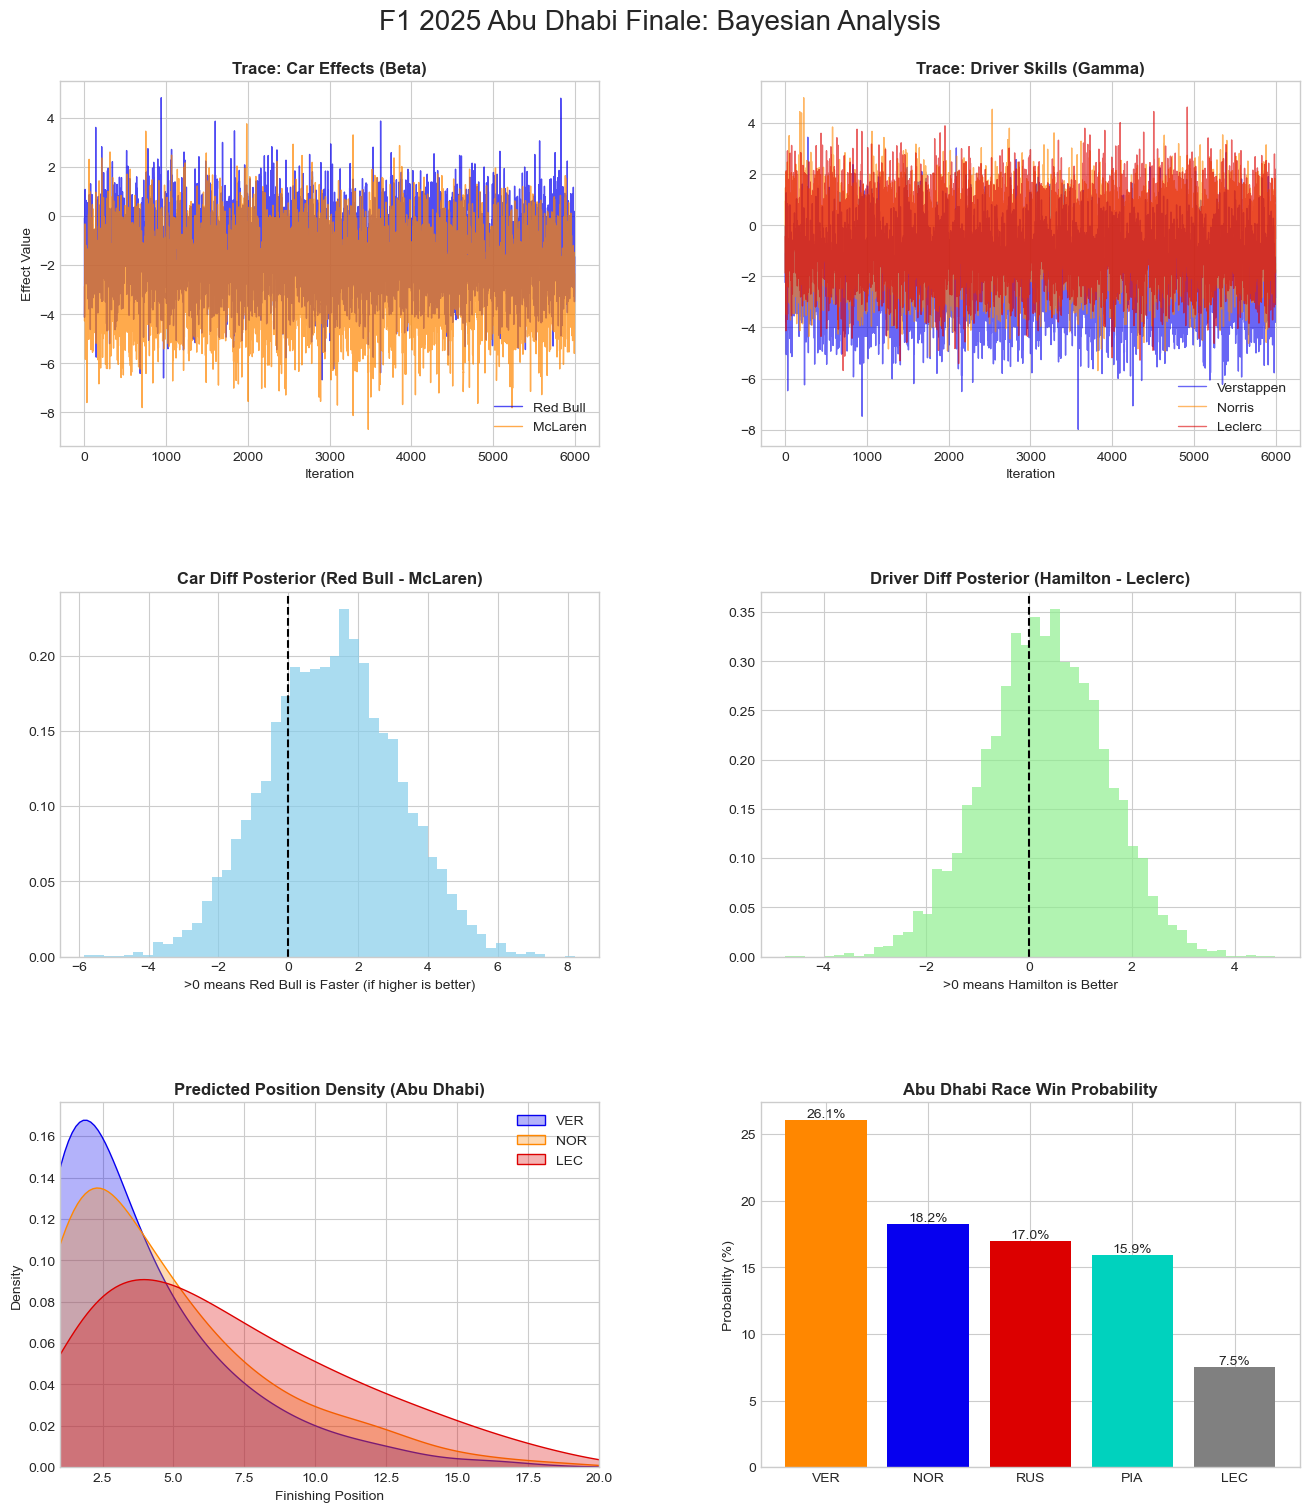

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import numpy as np

# =========================================================
# 0. Prepare Data Mapping for Plotting
# =========================================================
teams = np.sort(df['Team'].unique())
team_idx_map = {team: i for i, team in enumerate(teams)}
n_teams = len(teams)

drivers = np.sort(df['Driver'].unique())
driver_idx_map = {driver: i for i, driver in enumerate(drivers)}
n_drivers = len(drivers)

# Calculate "Abu Dhabi Race Win Probability"
# Count who finished 1st most often across 5000 simulations
wins = np.sum(sim_ranks_final == 1, axis=0)
win_probs_df = pd.DataFrame({
    'Driver': final_pred_df['Driver'],
    'Win_Prob': (wins / n_sims) * 100
}).sort_values('Win_Prob', ascending=False).reset_index(drop=True)

# =========================================================
# Plotting Setup
# =========================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

# Create figure canvas (3 rows x 2 columns)
fig = plt.figure(figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# Subplot 1: Trace Plot for Car Effects (Beta)
# ---------------------------------------------------------
ax1 = plt.subplot(3, 2, 1)
# Extract Beta (Car) posterior data # shape: (chain, draw, team)
beta_trace = trace.posterior['beta_car'].values 
beta_combined = beta_trace.reshape(-1, n_teams)

# Plot traces for Red Bull and McLaren
ax1.plot(beta_combined[:, team_idx_map['Red Bull Racing']], label='Red Bull', alpha=0.7, color='#0600EF', lw=1)
ax1.plot(beta_combined[:, team_idx_map['McLaren']], label='McLaren', alpha=0.7, color='#FF8700', lw=1)
ax1.set_title("Trace: Car Effects (Beta)", fontweight='bold')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Effect Value")
ax1.legend()

# ---------------------------------------------------------
# Subplot 2: Trace Plot for Driver Skills (Gamma)
# ---------------------------------------------------------
ax2 = plt.subplot(3, 2, 2)
# Extract Gamma (Driver) posterior data
gamma_trace = trace.posterior['gamma_driver'].values.reshape(-1, n_drivers)

# Plot traces for VER, NOR, LEC
ax2.plot(gamma_trace[:, driver_idx_map['VER']], label='Verstappen', alpha=0.6, color='#0600EF', lw=1)
ax2.plot(gamma_trace[:, driver_idx_map['NOR']], label='Norris', alpha=0.6, color='#FF8700', lw=1)
ax2.plot(gamma_trace[:, driver_idx_map['LEC']], label='Leclerc', alpha=0.6, color='#DC0000', lw=1)
ax2.set_title("Trace: Driver Skills (Gamma)", fontweight='bold')
ax2.set_xlabel("Iteration")
ax2.legend()

# ---------------------------------------------------------
# Subplot 3: Car Effects Posterior (Difference)
# ---------------------------------------------------------
ax3 = plt.subplot(3, 2, 3)
# Manually calculate Red Bull vs McLaren difference (independent of trace variables)
diff_car = beta_combined[:, team_idx_map['Red Bull Racing']] - beta_combined[:, team_idx_map['McLaren']]

# Plot histogram
ax3.hist(diff_car, bins=50, density=True, color='skyblue', alpha=0.7)
ax3.axvline(0, color='black', linestyle='--')
ax3.set_title("Car Diff Posterior (Red Bull - McLaren)", fontweight='bold')
ax3.set_xlabel(">0 means Red Bull is Faster (if higher is better)")

# ---------------------------------------------------------
# Subplot 4: Driver Skills Posterior (Difference)
# ---------------------------------------------------------
ax4 = plt.subplot(3, 2, 4)
# Manually calculate Hamilton vs Leclerc difference
diff_driver = gamma_trace[:, driver_idx_map['HAM']] - gamma_trace[:, driver_idx_map['LEC']]

# Plot histogram
ax4.hist(diff_driver, bins=50, density=True, color='lightgreen', alpha=0.7)
ax4.axvline(0, color='black', linestyle='--')
ax4.set_title("Driver Diff Posterior (Hamilton - Leclerc)", fontweight='bold')
ax4.set_xlabel(">0 means Hamilton is Better")

# ---------------------------------------------------------
# Subplot 5: Predicted Avg Position (Abu Dhabi Density)
# ---------------------------------------------------------
ax5 = plt.subplot(3, 2, 5)
drivers_to_plot = ['VER', 'NOR', 'LEC']
colors = ['#0600EF', '#FF8700', '#DC0000']

for d, c in zip(drivers_to_plot, colors):
    # Find driver row index in final_pred_df

    subset = final_pred_df[final_pred_df['Driver'] == d]
    if len(subset) > 0:
        d_idx_in_pred = subset.index[0] 
     
        loc_idx = final_pred_df.index.get_loc(d_idx_in_pred)
        
        ranks = sim_ranks_final[:, loc_idx]
        sns.kdeplot(ranks, ax=ax5, label=d, color=c, fill=True, alpha=0.3, bw_adjust=2)

ax5.set_title("Predicted Position Density (Abu Dhabi)", fontweight='bold')
ax5.set_xlabel("Finishing Position")
ax5.set_xlim(1, 20)
ax5.legend()

# ---------------------------------------------------------
# Subplot 6: Abu Dhabi Win Probability (Bar Chart)
# ---------------------------------------------------------
ax6 = plt.subplot(3, 2, 6)


top_winners = win_probs_df.head(5)

if not top_winners.empty and top_winners.iloc[0]['Win_Prob'] > 0:
    bars = ax6.bar(top_winners['Driver'], top_winners['Win_Prob'], 
            color=['#FF8700', '#0600EF', '#DC0000', '#00D2BE', 'gray'])
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')
        
    ax6.set_title("Abu Dhabi Race Win Probability", fontweight='bold')
    ax6.set_ylabel("Probability (%)")
else:
    ax6.text(0.5, 0.5, "Prediction Uncertain\n(Data Variance)", ha='center', va='center', fontsize=12)

# =========================================================
# Finalize
# =========================================================
plt.suptitle("F1 2025 Abu Dhabi Finale: Bayesian Analysis", fontsize=20, y=0.92)
plt.savefig('f1_bayesian_analysis_summary.png', dpi=150, bbox_inches='tight')
plt.show()